## Condition Configuration

- `CONDITION`: condition name whose AI review outputs should be analyzed.
- `REUSE_REVIEW_EMBEDDINGS`: `True` to load cached review embeddings when the cache matches the current reviews.


In [1]:
CONDITION = 'minimal'
REUSE_REVIEW_EMBEDDINGS = True


# PART IV QUALITY — Compare Human and AI Reviews (Style-Controlled / Rephrased)

This notebook mirrors `compare_reviews.ipynb` but uses AI reviews generated on rephrased proposals.

**Review data:** `data/reviews/ai_reviews/ai_reviews_rephrased_*.json`
**Proposal data:** `data/*/rephrased/`

## 0) Environment setup (run once if needed)


In [2]:
# Uncomment if needed
# %pip install -q numpy pandas scipy matplotlib seaborn openpyxl textblob transformers torch scikit-learn statsmodels krippendorff


## 1) Imports, paths, and constants


In [3]:
import json
import re
import itertools
import pickle
from pathlib import Path
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, kruskal, wilcoxon, spearmanr, kendalltau, linregress
from sklearn.metrics.pairwise import cosine_similarity
from textblob import TextBlob

import torch
from transformers import AutoTokenizer, AutoModel

sns.set_theme(style='whitegrid', context='talk')


def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path.cwd().parent.parent.parent]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate.resolve()
    raise RuntimeError('Could not find project root containing src/ and data/.')


PROJECT_ROOT = find_project_root()
condition='minimal'
PREPARED_DIR = PROJECT_ROOT / 'data' / 'prepared' / 'rephrased' / condition
NCEMS_ALL_REVIEWS_PATH = PREPARED_DIR / 'ncems_criteria_all_reviews.csv'
if not NCEMS_ALL_REVIEWS_PATH.exists():
    raise FileNotFoundError(f'Prepared NCEMS reviews not found at {NCEMS_ALL_REVIEWS_PATH}. Run prepare_data_for_analysis.ipynb first.')
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures' / 'quality' / condition / 'ncems_criteria'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables' / 'quality' / condition / 'ncems_criteria'
REVIEW_EMBEDDINGS_FILE = PROJECT_ROOT / 'data' / 'embeddings' / 'reviews' / condition / 'ncems_criteria' / f'review_embeddings_{condition}.pkl'
OUTPUT_DIR = FIGURES_DIR
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
REVIEW_EMBEDDINGS_FILE.parent.mkdir(parents=True, exist_ok=True)

colors = {
    'Human': '#DC143C',
    'claude-opus-4-5': '#4A90E2',
    'gemini-3-pro-preview': '#7B68EE',
    'gpt-5.2': '#FF8C00',
}

CRITERIA_ORDER = [
    'Relevance_to_Emergent_Phenomena',
    'Novelty_and_Significance',
    'Rigor_of_Approach',
    'Scope_and_Timeline',
    'Synthesis_Focus',
    'Data_Identification',
    'Open_Science_Commitment',
]

CRITERION_MAP = {
    'Relevance to Emergent Phenomena': 'Relevance_to_Emergent_Phenomena',
    'Novelty & Significance': 'Novelty_and_Significance',
    'Rigor of Approach': 'Rigor_of_Approach',
    'Scope & Timeline': 'Scope_and_Timeline',
    'Synthesis Focus': 'Synthesis_Focus',
    'Data Identification': 'Data_Identification',
    'Open Science Commitment': 'Open_Science_Commitment',
}

HUMAN_COL_MAP = {
    'scientific_merit_and_innovation_score': ['Relevance_to_Emergent_Phenomena', 'Novelty_and_Significance', 'Rigor_of_Approach'],
    'feasibility_score': ['Scope_and_Timeline'],
    'data_sources_and_limitations_score': ['Synthesis_Focus', 'Data_Identification'],
    'open_science_compliance_score': ['Open_Science_Commitment'],
}

SHARED_METRICS_4CAT = [
    'Scientific_Merit_and_Innovation',
    'Feasibility',
    'Data_Sources_and_Limitations',
    'Open_Science_Compliance',
]


## 2) Utility functions


In [4]:
def normalize_title(x: str) -> str:
    if pd.isna(x):
        return ''
    x = str(x).lower().strip()
    x = re.sub(r'[^a-z0-9]+', ' ', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x


def token_set_jaccard(a: str, b: str) -> float:
    sa = set(a.split())
    sb = set(b.split())
    if not sa and not sb:
        return 1.0
    if not sa or not sb:
        return 0.0
    return len(sa & sb) / len(sa | sb)


def hybrid_similarity(a: str, b: str) -> float:
    seq = SequenceMatcher(None, a, b).ratio()
    jac = token_set_jaccard(a, b)
    return 0.7 * seq + 0.3 * jac


def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    return (gt - lt) / (len(x) * len(y))


def interpret_cliffs_delta(delta):
    if np.isnan(delta):
        return 'NA'
    ad = abs(delta)
    if ad < 0.147:
        return 'negligible'
    if ad < 0.33:
        return 'small'
    if ad < 0.474:
        return 'medium'
    return 'large'


def benjamini_hochberg(pvalues):
    p = np.array(pvalues, dtype=float)
    n = len(p)
    if n == 0:
        return p
    order = np.argsort(p)
    ranked = p[order]
    q = np.empty(n)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        q[i] = prev
    out = np.empty(n)
    out[order] = np.clip(q, 0, 1)
    return out


def add_bh_fdr(df, p_col='p_value', group_cols=None, out_col='q_value'):
    df = df.copy()
    if group_cols is None:
        df[out_col] = benjamini_hochberg(df[p_col].values)
        return df
    df[out_col] = np.nan
    for _, idx in df.groupby(group_cols).groups.items():
        idx = list(idx)
        df.loc[idx, out_col] = benjamini_hochberg(df.loc[idx, p_col].values)
    return df


def mannwhitney_summary(a, b, metric_name='metric'):
    a = pd.Series(a).dropna().to_numpy()
    b = pd.Series(b).dropna().to_numpy()
    if len(a) == 0 or len(b) == 0:
        return {
            'metric': metric_name,
            'n_group1': len(a),
            'n_group2': len(b),
            'u_stat': np.nan,
            'p_value': np.nan,
            'cliffs_delta': np.nan,
            'delta_magnitude': 'NA',
        }
    u, p = mannwhitneyu(a, b, alternative='two-sided')
    d = cliffs_delta(a, b)
    return {
        'metric': metric_name,
        'n_group1': len(a),
        'n_group2': len(b),
        'u_stat': u,
        'p_value': p,
        'cliffs_delta': d,
        'delta_magnitude': interpret_cliffs_delta(d),
    }


def sentiment_label(p):
    if p > 0.1:
        return 'positive'
    if p < -0.1:
        return 'negative'
    return 'neutral'


def sentiment_alignment(p1, p2):
    return 1 - (abs(p1 - p2) / 2)


def categorical_agreement(l1, l2):
    if l1 == l2:
        return 'agree'
    if {'positive', 'negative'} == {l1, l2}:
        return 'disagree'
    return 'partial'


def bootstrap_mean_diff_ci(x, y, n_boot=2000, ci=0.95, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(pd.Series(x).dropna().values, dtype=float)
    y = np.asarray(pd.Series(y).dropna().values, dtype=float)
    if len(x) == 0 or len(y) == 0:
        return np.nan, np.nan, np.nan
    diffs = []
    for _ in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        diffs.append(np.mean(xb) - np.mean(yb))
    diffs = np.array(diffs)
    alpha = (1 - ci) / 2
    lo = np.quantile(diffs, alpha)
    hi = np.quantile(diffs, 1 - alpha)
    return np.mean(x) - np.mean(y), lo, hi


def permutation_p_value_mean_diff(x, y, n_perm=5000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(pd.Series(x).dropna().values, dtype=float)
    y = np.asarray(pd.Series(y).dropna().values, dtype=float)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    obs = abs(np.mean(x) - np.mean(y))
    pooled = np.concatenate([x, y]).copy()
    n_x = len(x)
    count = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        xp = pooled[:n_x]
        yp = pooled[n_x:]
        if abs(np.mean(xp) - np.mean(yp)) >= obs:
            count += 1
    return (count + 1) / (n_perm + 1)


def icc2_1_2k(ratings_matrix):
    # ICC(2,1) and ICC(2,k) for complete items x raters matrix
    X = np.asarray(ratings_matrix, dtype=float)
    if np.isnan(X).any():
        return np.nan, np.nan
    n, k = X.shape
    if n < 2 or k < 2:
        return np.nan, np.nan

    mean_row = X.mean(axis=1, keepdims=True)
    mean_col = X.mean(axis=0, keepdims=True)
    grand = X.mean()

    ss_row = k * np.sum((mean_row - grand) ** 2)
    ss_col = n * np.sum((mean_col - grand) ** 2)
    ss_err = np.sum((X - mean_row - mean_col + grand) ** 2)

    ms_row = ss_row / (n - 1)
    ms_col = ss_col / (k - 1)
    ms_err = ss_err / ((n - 1) * (k - 1))

    icc21 = (ms_row - ms_err) / (ms_row + (k - 1) * ms_err + (k * (ms_col - ms_err) / n))
    icc2k = (ms_row - ms_err) / (ms_row + ((ms_col - ms_err) / n))
    return icc21, icc2k


def build_one_to_one_title_mapping(human_proposals, ai_proposals, fuzzy_threshold=0.70):
    h = human_proposals.copy().reset_index(drop=True)
    a = ai_proposals.copy().reset_index(drop=True)

    assigned_h = set()
    assigned_a = set()
    rows = []

    ai_by_norm = a.groupby('ai_title_norm')['ai_proposal_id'].apply(list).to_dict()
    for _, hr in h.iterrows():
        hp = hr['human_proposal_id']
        hn = hr['human_title_norm']
        candidates = ai_by_norm.get(hn, [])
        candidates = [x for x in candidates if x not in assigned_a]
        if len(candidates) == 1:
            ap = candidates[0]
            ar = a.loc[a['ai_proposal_id'] == ap].iloc[0]
            rows.append({
                'human_proposal_id': hp,
                'ai_proposal_id': ap,
                'human_title': hr['human_title'],
                'ai_title': ar['ai_title'],
                'human_title_norm': hn,
                'ai_title_norm': ar['ai_title_norm'],
                'similarity': 1.0,
                'match_method': 'exact',
            })
            assigned_h.add(hp)
            assigned_a.add(ap)

    h_un = h[~h['human_proposal_id'].isin(assigned_h)]
    a_un = a[~a['ai_proposal_id'].isin(assigned_a)]

    candidates = []
    for _, hr in h_un.iterrows():
        for _, ar in a_un.iterrows():
            sim = hybrid_similarity(hr['human_title_norm'], ar['ai_title_norm'])
            candidates.append((sim, hr['human_proposal_id'], ar['ai_proposal_id']))

    candidates = sorted(candidates, key=lambda x: x[0], reverse=True)
    used_h = set()
    used_a = set()

    for sim, hp, ap in candidates:
        if sim < fuzzy_threshold:
            break
        if hp in used_h or ap in used_a:
            continue
        hr = h.loc[h['human_proposal_id'] == hp].iloc[0]
        ar = a.loc[a['ai_proposal_id'] == ap].iloc[0]
        rows.append({
            'human_proposal_id': hp,
            'ai_proposal_id': ap,
            'human_title': hr['human_title'],
            'ai_title': ar['ai_title'],
            'human_title_norm': hr['human_title_norm'],
            'ai_title_norm': ar['ai_title_norm'],
            'similarity': sim,
            'match_method': 'fuzzy',
        })
        used_h.add(hp)
        used_a.add(ap)

    mapping = pd.DataFrame(rows)

    h_unmatched = sorted(set(h['human_proposal_id']) - set(mapping['human_proposal_id']))
    a_unmatched = sorted(set(a['ai_proposal_id']) - set(mapping['ai_proposal_id']))

    diagnostics = {
        'n_human_proposals': int(h.shape[0]),
        'n_ai_proposals': int(a.shape[0]),
        'n_matched': int(mapping.shape[0]),
        'n_exact': int((mapping['match_method'] == 'exact').sum()) if not mapping.empty else 0,
        'n_fuzzy': int((mapping['match_method'] == 'fuzzy').sum()) if not mapping.empty else 0,
        'n_unmatched_human': int(len(h_unmatched)),
        'n_unmatched_ai': int(len(a_unmatched)),
    }

    return mapping, diagnostics, h_unmatched, a_unmatched


## 3) Load prepared AI reviews

In [5]:
all_reviews_df = pd.read_csv(NCEMS_ALL_REVIEWS_PATH)
ai_df = all_reviews_df[all_reviews_df['review_source'] == 'ai'].copy()

for c in ['overall_score'] + CRITERIA_ORDER:
    ai_df[c] = pd.to_numeric(ai_df[c], errors='coerce')

print('AI reviews rows:', len(ai_df))
print('Authors:', sorted(ai_df['author'].dropna().unique()))
print('Evaluators:', sorted(ai_df['evaluator'].dropna().unique()))
ai_df.head(3)

AI reviews rows: 276
Authors: ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2', 'human-y1', 'human-y2']
Evaluators: ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']


,review_uid,review_type,review_source,source_file,source_file_original,proposal_id,proposal_uid,title,title_norm,author,...,Data_Identification,Open_Science_Commitment,ranking,proposal_status,funding,year,reviewer_id,average_score_human,average_score_AI,ranking_AI_reviews
0,ncems-ai-0000,ncems_criteria,ai,ncems_reviews_rephrased.json,ncems_reviews_20260416_122201.json,a crossmodal synthesis of biomolecular condens...,gpt-5.2::a crossmodal synthesis of biomolecula...,A Cross-Modal Synthesis of Biomolecular Conden...,a crossmodal synthesis of biomolecular condens...,gpt-5.2,...,4.0,5.0,1.0,NaN,NaN,NaN,NaN,NaN,4.433333,1
1,ncems-ai-0001,ncems_criteria,ai,ncems_reviews_rephrased.json,ncems_reviews_20260416_122201.json,a crossmodal synthesis of biomolecular condens...,gpt-5.2::a crossmodal synthesis of biomolecula...,A Cross-Modal Synthesis of Biomolecular Conden...,a crossmodal synthesis of biomolecular condens...,gpt-5.2,...,5.0,5.0,1.0,NaN,NaN,NaN,NaN,NaN,4.433333,1
2,ncems-ai-0002,ncems_criteria,ai,ncems_reviews_rephrased.json,ncems_reviews_20260416_122201.json,a crossmodal synthesis of biomolecular condens...,gpt-5.2::a crossmodal synthesis of biomolecula...,A Cross-Modal Synthesis of Biomolecular Conden...,a crossmodal synthesis of biomolecular condens...,gpt-5.2,...,4.0,5.0,1.0,NaN,NaN,NaN,NaN,NaN,4.433333,1


## 4) Load prepared human expert reviews (Y1 + Y2)

In [6]:
human_reviews_df = all_reviews_df[
    (all_reviews_df['review_source'] == 'human')
    & (all_reviews_df['author'].isin(['human-y1', 'human-y2']))
].copy()

human_y1_df = human_reviews_df[human_reviews_df['author'] == 'human-y1'].copy()
human_y2_df = human_reviews_df[human_reviews_df['author'] == 'human-y2'].copy()

for c in ['overall_score'] + CRITERIA_ORDER:
    human_reviews_df[c] = pd.to_numeric(human_reviews_df[c], errors='coerce')
    human_y1_df[c] = pd.to_numeric(human_y1_df[c], errors='coerce')
    human_y2_df[c] = pd.to_numeric(human_y2_df[c], errors='coerce')

# Backward-compatible alias used by legacy Y1-only mapping blocks in Sections 5-8.
human_df = human_y1_df.copy()

print('Human reviews rows (Y1+Y2):', len(human_reviews_df))
print('Human Y1 rows:', len(human_y1_df), '| proposals:', human_y1_df['proposal_id'].nunique())
print('Human Y2 rows:', len(human_y2_df), '| proposals:', human_y2_df['proposal_id'].nunique())
human_reviews_df.head(3)


Human reviews rows (Y1+Y2): 85
Human Y1 rows: 47 | proposals: 12
Human Y2 rows: 38 | proposals: 11


,review_uid,review_type,review_source,source_file,source_file_original,proposal_id,proposal_uid,title,title_norm,author,...,Data_Identification,Open_Science_Commitment,ranking,proposal_status,funding,year,reviewer_id,average_score_human,average_score_AI,ranking_AI_reviews
276,ncems-human-y1-0000,ncems_criteria,human,human_reviews_human-y1_rephrased.csv,human_reviews_human-y1.xlsx,1,human-y1::1,CYTOKINETIC BOTTLENECKS OF HEAT WAVES,cytokinetic bottlenecks of heat waves,human-y1,...,NaN,NaN,1.0,Accepted,1.0,y1,1.0,4.333333,3.2,9
277,ncems-human-y1-0001,ncems_criteria,human,human_reviews_human-y1_rephrased.csv,human_reviews_human-y1.xlsx,1,human-y1::1,CYTOKINETIC BOTTLENECKS OF HEAT WAVES,cytokinetic bottlenecks of heat waves,human-y1,...,5.0,5.0,1.0,Accepted,1.0,y1,2.0,4.333333,3.2,9
278,ncems-human-y1-0002,ncems_criteria,human,human_reviews_human-y1_rephrased.csv,human_reviews_human-y1.xlsx,1,human-y1::1,CYTOKINETIC BOTTLENECKS OF HEAT WAVES,cytokinetic bottlenecks of heat waves,human-y1,...,5.0,3.0,1.0,Accepted,1.0,y1,3.0,4.333333,3.2,9


## 5) Proposal matching diagnostics (exact + fuzzy fallback)

This fixes the prior issue where title-exact matching dropped proposals.


In [7]:
ai_y1 = ai_df[ai_df['author'] == 'human-y1'].copy()

human_props = (
    human_df[['proposal_id', 'title', 'title_norm']]
    .drop_duplicates(subset=['proposal_id'])
    .rename(columns={
        'proposal_id': 'human_proposal_id',
        'title': 'human_title',
        'title_norm': 'human_title_norm',
    })
)

ai_props = (
    ai_y1[['proposal_id', 'title', 'title_norm']]
    .drop_duplicates(subset=['title_norm'])
    .rename(columns={
        'proposal_id': 'ai_proposal_id',
        'title': 'ai_title',
        'title_norm': 'ai_title_norm',
    })
)

mapping_df, mapping_diag, h_unmatched, a_unmatched = build_one_to_one_title_mapping(
    human_props,
    ai_props,
    fuzzy_threshold=0.70,
)

mapping_df = mapping_df.sort_values('human_proposal_id').reset_index(drop=True)
mapping_df['proposal_key'] = [f'Y1_{i+1:02d}' for i in range(len(mapping_df))]

print('Mapping diagnostics:', mapping_diag)
print('Unmatched human proposal_ids:', h_unmatched)
print('Unmatched ai proposal_ids:', a_unmatched)

mapping_df[['proposal_key', 'human_proposal_id', 'ai_proposal_id', 'match_method', 'similarity', 'human_title', 'ai_title']]

Mapping diagnostics: {'n_human_proposals': 12, 'n_ai_proposals': 12, 'n_matched': 12, 'n_exact': 9, 'n_fuzzy': 3, 'n_unmatched_human': 0, 'n_unmatched_ai': 0}
Unmatched human proposal_ids: []
Unmatched ai proposal_ids: []


,proposal_key,human_proposal_id,ai_proposal_id,match_method,similarity,human_title,ai_title
0,Y1_01,1,1,exact,1.000000,CYTOKINETIC BOTTLENECKS OF HEAT WAVES,CYTOKINETIC BOTTLENECKS OF HEAT WAVES
1,Y1_02,10,10,exact,1.000000,Transposable elements and the emergence of gen...,Transposable elements and the emergence of gen...
2,Y1_03,11,11,exact,1.000000,Searching the Crosslinking Mass Spectrometry ...,Searching the crosslinking mass spectrometry u...
3,Y1_04,12,12,fuzzy,0.853827,Intelligent metadata compilation to enhance th...,Intelligent metadata compilation to enhance th...
4,Y1_05,2,2,exact,1.000000,Elucidating genome structure-function relation...,Elucidating genome structure-function relation...
5,Y1_06,3,3,exact,1.000000,MaiTool - LLM-powered bioinformatics tools for...,MaiTool - LLM-powered bioinformatics tools for...
6,Y1_07,4,4,exact,1.000000,Synthesizing gene expression data to create an...,Synthesizing gene expression data to create an...
7,Y1_08,5,5,exact,1.000000,Energetic Origins of Connectivity within Prote...,Energetic Origins of Connectivity within Prote...
8,Y1_09,6,6,exact,1.000000,Elucidating emergent structures in cellular RN...,Elucidating emergent structures in cellular RN...
9,Y1_10,7,7,fuzzy,0.857375,Elucidating the Role of Disordered Proteins in...,Oceans of Disorder: Elucidating the Role of Di...


## 6) Build matched review sets, embeddings, and pair table (single source of truth)


In [8]:
MODEL_NAME = 'michiyasunaga/BioLinkBERT-large'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tokenizer = None
model = None


def ensure_review_embedding_model_loaded():
    global tokenizer, model
    if tokenizer is not None and model is not None:
        return tokenizer, model

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModel.from_pretrained(MODEL_NAME).to(device)
    model.eval()
    return tokenizer, model


def embed_texts(texts, batch_size=8, max_len=512):
    ensure_review_embedding_model_loaded()
    all_emb = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            tok = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_len,
                return_tensors='pt'
            )
            tok = {k: v.to(device) for k, v in tok.items()}
            out = model(**tok)

            attn = tok['attention_mask'].unsqueeze(-1)
            masked = out.last_hidden_state * attn
            denom = attn.sum(dim=1).clamp(min=1)
            emb = masked.sum(dim=1) / denom
            emb = torch.nn.functional.normalize(emb, p=2, dim=1)
            all_emb.append(emb.cpu().numpy())
    return np.vstack(all_emb)


def lookup_prepared_review_embeddings(df):
    if not REVIEW_EMBEDDINGS_FILE.exists():
        raise FileNotFoundError(REVIEW_EMBEDDINGS_FILE)
    with open(REVIEW_EMBEDDINGS_FILE, 'rb') as f:
        cached = pickle.load(f)
    if 'embeddings' not in cached or 'metadata' not in cached:
        raise ValueError('Prepared all-review embedding cache is not available')
    emb_by_uid = {str(meta.get('review_uid')): np.asarray(cached['embeddings'])[i] for i, meta in enumerate(cached.get('metadata', []))}
    missing = [str(uid) for uid in df['review_uid'] if str(uid) not in emb_by_uid]
    if missing:
        raise KeyError(f'Missing {len(missing)} review_uids in prepared embedding cache')
    return np.vstack([emb_by_uid[str(uid)] for uid in df['review_uid']])


h = human_df.merge(
    mapping_df[['human_proposal_id', 'proposal_key', 'match_method']],
    left_on='proposal_id',
    right_on='human_proposal_id',
    how='inner',
).copy()

a = ai_y1.merge(
    mapping_df[['ai_proposal_id', 'proposal_key', 'match_method']],
    left_on='proposal_id',
    right_on='ai_proposal_id',
    how='inner',
).copy()

h = h.reset_index(drop=True)
a = a.reset_index(drop=True)
if 'review_uid' not in h.columns:
    h['review_uid'] = [f'H_{i:04d}' for i in range(len(h))]
if 'review_uid' not in a.columns:
    a['review_uid'] = [f'A_{i:04d}' for i in range(len(a))]

h_texts = h['review_text'].fillna('').tolist()
a_texts = a['review_text'].fillna('').tolist()
MATCHED_REVIEW_EMBEDDINGS_FILE = REVIEW_EMBEDDINGS_FILE.with_name(REVIEW_EMBEDDINGS_FILE.stem + '_matched_y1.pkl')
review_embeddings_loaded_from_cache = False

if REVIEW_EMBEDDINGS_FILE.exists():
    with open(REVIEW_EMBEDDINGS_FILE, 'rb') as f:
        cached = pickle.load(f)

    if 'embeddings' in cached and 'metadata' in cached:
        emb_by_uid = {str(meta.get('review_uid')): np.asarray(cached['embeddings'])[i] for i, meta in enumerate(cached.get('metadata', []))}
        if all(str(uid) in emb_by_uid for uid in h['review_uid']) and all(str(uid) in emb_by_uid for uid in a['review_uid']):
            h_emb = np.vstack([emb_by_uid[str(uid)] for uid in h['review_uid']])
            a_emb = np.vstack([emb_by_uid[str(uid)] for uid in a['review_uid']])
            review_embeddings_loaded_from_cache = True
            print(f'Loaded prepared review embeddings from: {REVIEW_EMBEDDINGS_FILE}')
    else:
        cached_h_uids = cached.get('h_review_uids', [])
        cached_a_uids = cached.get('a_review_uids', [])
        cached_h_texts = cached.get('h_review_texts', [])
        cached_a_texts = cached.get('a_review_texts', [])
        if (
            cached.get('model_name') == MODEL_NAME
            and cached_h_uids == h['review_uid'].tolist()
            and cached_a_uids == a['review_uid'].tolist()
            and cached_h_texts == h_texts
            and cached_a_texts == a_texts
        ):
            h_emb = np.asarray(cached['h_embeddings'])
            a_emb = np.asarray(cached['a_embeddings'])
            review_embeddings_loaded_from_cache = True
            print(f'Loaded legacy matched review embeddings from: {REVIEW_EMBEDDINGS_FILE}')

    if not review_embeddings_loaded_from_cache:
        print(f'Ignoring stale review embedding cache: {REVIEW_EMBEDDINGS_FILE}')

if not review_embeddings_loaded_from_cache and MATCHED_REVIEW_EMBEDDINGS_FILE.exists():
    with open(MATCHED_REVIEW_EMBEDDINGS_FILE, 'rb') as f:
        cached = pickle.load(f)
    if (
        cached.get('model_name') == MODEL_NAME
        and cached.get('h_review_uids', []) == h['review_uid'].tolist()
        and cached.get('a_review_uids', []) == a['review_uid'].tolist()
        and cached.get('h_review_texts', []) == h_texts
        and cached.get('a_review_texts', []) == a_texts
    ):
        h_emb = np.asarray(cached['h_embeddings'])
        a_emb = np.asarray(cached['a_embeddings'])
        review_embeddings_loaded_from_cache = True
        print(f'Loaded matched review embeddings from: {MATCHED_REVIEW_EMBEDDINGS_FILE}')

if not review_embeddings_loaded_from_cache:
    print('Computing matched review embeddings...')
    h_emb = embed_texts(h_texts)
    a_emb = embed_texts(a_texts)
    cache_payload = {
        'model_name': MODEL_NAME,
        'h_embeddings': h_emb,
        'a_embeddings': a_emb,
        'h_review_uids': h['review_uid'].tolist(),
        'a_review_uids': a['review_uid'].tolist(),
        'h_review_texts': h_texts,
        'a_review_texts': a_texts,
    }
    with open(MATCHED_REVIEW_EMBEDDINGS_FILE, 'wb') as f:
        pickle.dump(cache_payload, f)
    print(f'Saved matched review embeddings to: {MATCHED_REVIEW_EMBEDDINGS_FILE}')

h['embedding'] = list(h_emb)
a['embedding'] = list(a_emb)

for df in [h, a]:
    pol = [TextBlob(t).sentiment.polarity for t in df['review_text'].fillna('')]
    df['polarity'] = pol
    df['sent_label'] = [sentiment_label(p) for p in pol]

records = []
for pk in sorted(set(h['proposal_key']).intersection(set(a['proposal_key']))):
    hg = h[h['proposal_key'] == pk]
    ag = a[a['proposal_key'] == pk]

    for _, hr in hg.iterrows():
        for _, ar in ag.iterrows():
            cos = float(cosine_similarity([hr['embedding']], [ar['embedding']])[0, 0])
            align = sentiment_alignment(hr['polarity'], ar['polarity'])
            cag = categorical_agreement(hr['sent_label'], ar['sent_label'])
            records.append({
                'pair_type': 'human-ai',
                'proposal_key': pk,
                'match_method': hr['match_method'],
                'human_reviewer': hr['evaluator'],
                'ai_model': ar['evaluator'],
                'cosine_similarity': cos,
                'sentiment_alignment': align,
                'categorical_agreement': cag,
                'categorical_agreement_num': {'disagree': 0, 'partial': 1, 'agree': 2}[cag],
            })

    for (_, a1), (_, a2) in itertools.combinations(ag.iterrows(), 2):
        cos = float(cosine_similarity([a1['embedding']], [a2['embedding']])[0, 0])
        align = sentiment_alignment(a1['polarity'], a2['polarity'])
        cag = categorical_agreement(a1['sent_label'], a2['sent_label'])
        m1 = a1['evaluator']
        m2 = a2['evaluator']
        records.append({
            'pair_type': 'ai-ai',
            'proposal_key': pk,
            'match_method': a1['match_method'],
            'ai_model_1': m1,
            'ai_model_2': m2,
            'ai_model_pair': ' vs '.join(sorted([str(m1), str(m2)])),
            'cosine_similarity': cos,
            'sentiment_alignment': align,
            'categorical_agreement': cag,
            'categorical_agreement_num': {'disagree': 0, 'partial': 1, 'agree': 2}[cag],
        })

    for (_, h1), (_, h2) in itertools.combinations(hg.iterrows(), 2):
        cos = float(cosine_similarity([h1['embedding']], [h2['embedding']])[0, 0])
        align = sentiment_alignment(h1['polarity'], h2['polarity'])
        cag = categorical_agreement(h1['sent_label'], h2['sent_label'])
        records.append({
            'pair_type': 'human-human',
            'proposal_key': pk,
            'match_method': h1['match_method'],
            'human_reviewer_1': h1['evaluator'],
            'human_reviewer_2': h2['evaluator'],
            'cosine_similarity': cos,
            'sentiment_alignment': align,
            'categorical_agreement': cag,
            'categorical_agreement_num': {'disagree': 0, 'partial': 1, 'agree': 2}[cag],
        })

pair_df = pd.DataFrame(records)

print('Matched proposals:', pair_df['proposal_key'].nunique())
print('Pair counts by type:')
print(pair_df['pair_type'].value_counts())
print('Human-AI pairs by AI model:')
print(pair_df[pair_df['pair_type'] == 'human-ai']['ai_model'].value_counts())
print('AI-AI pairs by model pair:')
print(pair_df[pair_df['pair_type'] == 'ai-ai']['ai_model_pair'].value_counts())

pair_df.head()


Loaded prepared review embeddings from: /Users/eveyhuang/Documents/NICO/human-AI-proposal-comparison/data/embeddings/reviews/minimal/ncems_criteria/review_embeddings_minimal.pkl
Matched proposals: 12
Pair counts by type:
pair_type
human-ai       141
human-human     70
ai-ai           36
Name: count, dtype: int64
Human-AI pairs by AI model:
ai_model
gpt-5.2                 47
gemini-3-pro-preview    47
claude-opus-4-5         47
Name: count, dtype: int64
AI-AI pairs by model pair:
ai_model_pair
gemini-3-pro-preview vs gpt-5.2            12
claude-opus-4-5 vs gpt-5.2                 12
claude-opus-4-5 vs gemini-3-pro-preview    12
Name: count, dtype: int64


,pair_type,proposal_key,match_method,human_reviewer,ai_model,cosine_similarity,sentiment_alignment,categorical_agreement,categorical_agreement_num,ai_model_1,ai_model_2,ai_model_pair,human_reviewer_1,human_reviewer_2
0,human-ai,Y1_01,exact,human-reviewer-1,gpt-5.2,0.966678,0.998333,agree,2,NaN,NaN,NaN,NaN,NaN
1,human-ai,Y1_01,exact,human-reviewer-1,gemini-3-pro-preview,0.967881,0.930833,agree,2,NaN,NaN,NaN,NaN,NaN
2,human-ai,Y1_01,exact,human-reviewer-1,claude-opus-4-5,0.964275,0.948889,agree,2,NaN,NaN,NaN,NaN,NaN
3,human-ai,Y1_01,exact,human-reviewer-2,gpt-5.2,0.963558,0.945625,agree,2,NaN,NaN,NaN,NaN,NaN
4,human-ai,Y1_01,exact,human-reviewer-2,gemini-3-pro-preview,0.969064,0.983542,agree,2,NaN,NaN,NaN,NaN,NaN


## 7) Pair count checks (expected vs observed)


In [9]:
def _nC2(n: int) -> int:
    n = int(n)
    return (n * (n - 1)) // 2 if n >= 2 else 0

unique_pks = sorted(set(h['proposal_key']).intersection(set(a['proposal_key'])))
human_counts = h.groupby('proposal_key').size().reindex(unique_pks, fill_value=0).rename('n_human_reviews')
ai_counts_total = a.groupby('proposal_key').size().reindex(unique_pks, fill_value=0).rename('n_ai_reviews_total')
ai_counts_by_model = (
    a.pivot_table(index='proposal_key', columns='evaluator', values='review_uid', aggfunc='size', fill_value=0)
    .reindex(unique_pks, fill_value=0)
)

counts_df = pd.concat([human_counts, ai_counts_total, ai_counts_by_model], axis=1).fillna(0).astype(int)
display(counts_df)

expected_human_ai_total = int((counts_df['n_human_reviews'] * counts_df['n_ai_reviews_total']).sum())
expected_human_human_total = int(counts_df['n_human_reviews'].map(_nC2).sum())
expected_ai_ai_total = int(counts_df['n_ai_reviews_total'].map(_nC2).sum())

observed_totals = pair_df['pair_type'].value_counts().to_dict()

print('Expected totals:', {
    'human-ai': expected_human_ai_total,
    'human-human': expected_human_human_total,
    'ai-ai': expected_ai_ai_total,
})
print('Observed totals:', observed_totals)


,n_human_reviews,n_ai_reviews_total,claude-opus-4-5,gemini-3-pro-preview,gpt-5.2
proposal_key,,,,,
Y1_01,4,3,1,1,1
Y1_02,4,3,1,1,1
Y1_03,4,3,1,1,1
Y1_04,4,3,1,1,1
Y1_05,3,3,1,1,1
Y1_06,4,3,1,1,1
Y1_07,4,3,1,1,1
Y1_08,4,3,1,1,1
Y1_09,4,3,1,1,1


Expected totals: {'human-ai': 141, 'human-human': 70, 'ai-ai': 36}
Observed totals: {'human-ai': 141, 'human-human': 70, 'ai-ai': 36}


# R1: How does the diversity of human reviews compare to those by AI?

## 8c) Build matched review sets for Y1 and Y2 (single source of truth)

In [10]:
# Build cohort-parallel review similarity datasets for Y1 and Y2
# from the prepared merged review dataframe (no reloading/reformatting).

from itertools import combinations


def build_cohort_similarity(human_reviews_df, ai_reviews_df, cohort_tag, fuzzy_threshold=0.70):
    # 1) title mapping
    human_props = (
        human_reviews_df[['proposal_id', 'title', 'title_norm']]
        .drop_duplicates(subset=['proposal_id'])
        .rename(columns={
            'proposal_id': 'human_proposal_id',
            'title': 'human_title',
            'title_norm': 'human_title_norm',
        })
    )

    ai_props = (
        ai_reviews_df[['proposal_id', 'title', 'title_norm']]
        .drop_duplicates(subset=['title_norm'])
        .rename(columns={
            'proposal_id': 'ai_proposal_id',
            'title': 'ai_title',
            'title_norm': 'ai_title_norm',
        })
    )

    mapping, mapping_diag, h_unmatched, a_unmatched = build_one_to_one_title_mapping(
        human_props, ai_props, fuzzy_threshold=fuzzy_threshold
    )
    mapping = mapping.sort_values('human_proposal_id').reset_index(drop=True)
    mapping['proposal_key'] = [f'{cohort_tag}_{i+1:02d}' for i in range(len(mapping))]

    # 2) aligned review rows
    h = human_reviews_df.merge(
        mapping[['human_proposal_id', 'proposal_key', 'match_method']],
        left_on='proposal_id', right_on='human_proposal_id', how='inner'
    ).copy()

    a = ai_reviews_df.merge(
        mapping[['ai_proposal_id', 'proposal_key', 'match_method']],
        left_on='proposal_id', right_on='ai_proposal_id', how='inner'
    ).copy()

    h = h.reset_index(drop=True)
    a = a.reset_index(drop=True)

    # 3) embeddings (must come from prepared review embedding cache when available)
    try:
        h_emb = lookup_prepared_review_embeddings(h)
        a_emb = lookup_prepared_review_embeddings(a)
        print(f'Loaded prepared review embeddings for {cohort_tag}')
    except Exception as exc:
        print(f'Prepared review embeddings unavailable for {cohort_tag}: {exc}; computing locally.')
        h_emb = embed_texts(h['review_text'].fillna('').tolist())
        a_emb = embed_texts(a['review_text'].fillna('').tolist())

    h['embedding'] = list(h_emb)
    a['embedding'] = list(a_emb)

    # 4) pairwise similarity records
    recs = []
    for pk in sorted(set(h['proposal_key']).intersection(set(a['proposal_key']))):
        hg = h[h['proposal_key'] == pk]
        ag = a[a['proposal_key'] == pk]

        for (_, h1), (_, h2) in combinations(hg.iterrows(), 2):
            cos = float(cosine_similarity([h1['embedding']], [h2['embedding']])[0, 0])
            recs.append({
                'cohort': cohort_tag,
                'pair_type': 'human-human',
                'proposal_key': pk,
                'cosine_similarity': cos,
            })

        for (_, a1), (_, a2) in combinations(ag.iterrows(), 2):
            cos = float(cosine_similarity([a1['embedding']], [a2['embedding']])[0, 0])
            recs.append({
                'cohort': cohort_tag,
                'pair_type': 'ai-ai',
                'proposal_key': pk,
                'cosine_similarity': cos,
            })

    pair_df_local = pd.DataFrame(recs)

    return {
        'mapping': mapping,
        'mapping_diag': mapping_diag,
        'h_unmatched': h_unmatched,
        'a_unmatched': a_unmatched,
        'human_aligned': h,
        'ai_aligned': a,
        'pair_df': pair_df_local,
    }


# Prepared cohort sources from all_reviews_df (created in prepare_data_for_analysis.ipynb).
human_y1_reviews = human_y1_df.copy()
human_y2_reviews = human_y2_df.copy()
ai_y1_reviews = ai_df[ai_df['author'] == 'human-y1'].copy()
ai_y2_reviews = ai_df[ai_df['author'] == 'human-y2'].copy()

# Ensure matching key columns are normalized and IDs are strings.
for _d in [human_y1_reviews, human_y2_reviews, ai_y1_reviews, ai_y2_reviews]:
    _d['title_norm'] = _d['title'].map(normalize_title)
    _d['proposal_id'] = _d['proposal_id'].astype(str)

print('Using prepared merged review dataframe (no raw re-load):')
print('Human Y1 reviews:', len(human_y1_reviews), '| proposals:', human_y1_reviews['proposal_id'].nunique())
print('Human Y2 reviews:', len(human_y2_reviews), '| proposals:', human_y2_reviews['proposal_id'].nunique())
print('AI Y1 reviews:', len(ai_y1_reviews), '| proposals:', ai_y1_reviews['title_norm'].nunique())
print('AI Y2 reviews:', len(ai_y2_reviews), '| proposals:', ai_y2_reviews['title_norm'].nunique())

# Build matched pairwise similarity datasets by cohort.
cohort_y1 = build_cohort_similarity(human_y1_reviews, ai_y1_reviews, cohort_tag='Y1')
cohort_y2 = build_cohort_similarity(human_y2_reviews, ai_y2_reviews, cohort_tag='Y2')

print('\nY1 mapping diagnostics:', cohort_y1['mapping_diag'])
print('Y2 mapping diagnostics:', cohort_y2['mapping_diag'])
print('Y1 pair counts:', cohort_y1['pair_df']['pair_type'].value_counts().to_dict())
print('Y2 pair counts:', cohort_y2['pair_df']['pair_type'].value_counts().to_dict())


Using prepared merged review dataframe (no raw re-load):
Human Y1 reviews: 47 | proposals: 12
Human Y2 reviews: 38 | proposals: 11
AI Y1 reviews: 36 | proposals: 12
AI Y2 reviews: 33 | proposals: 11
Loaded prepared review embeddings for Y1
Loaded prepared review embeddings for Y2

Y1 mapping diagnostics: {'n_human_proposals': 12, 'n_ai_proposals': 12, 'n_matched': 12, 'n_exact': 9, 'n_fuzzy': 3, 'n_unmatched_human': 0, 'n_unmatched_ai': 0}
Y2 mapping diagnostics: {'n_human_proposals': 11, 'n_ai_proposals': 11, 'n_matched': 11, 'n_exact': 11, 'n_fuzzy': 0, 'n_unmatched_human': 0, 'n_unmatched_ai': 0}
Y1 pair counts: {'human-human': 70, 'ai-ai': 36}
Y2 pair counts: {'human-human': 49, 'ai-ai': 33}


## R1-Q1) Can humans create more diverse reviews than AI?

### 8d) Review diversity metrics (proposal-conditioned; Y1 and Y2)

Diversity proposal-level rows:
Y1 wide: (12, 54)
Y2 wide: (11, 54)
Within-cohort Human-vs-AI tests: (20, 14)


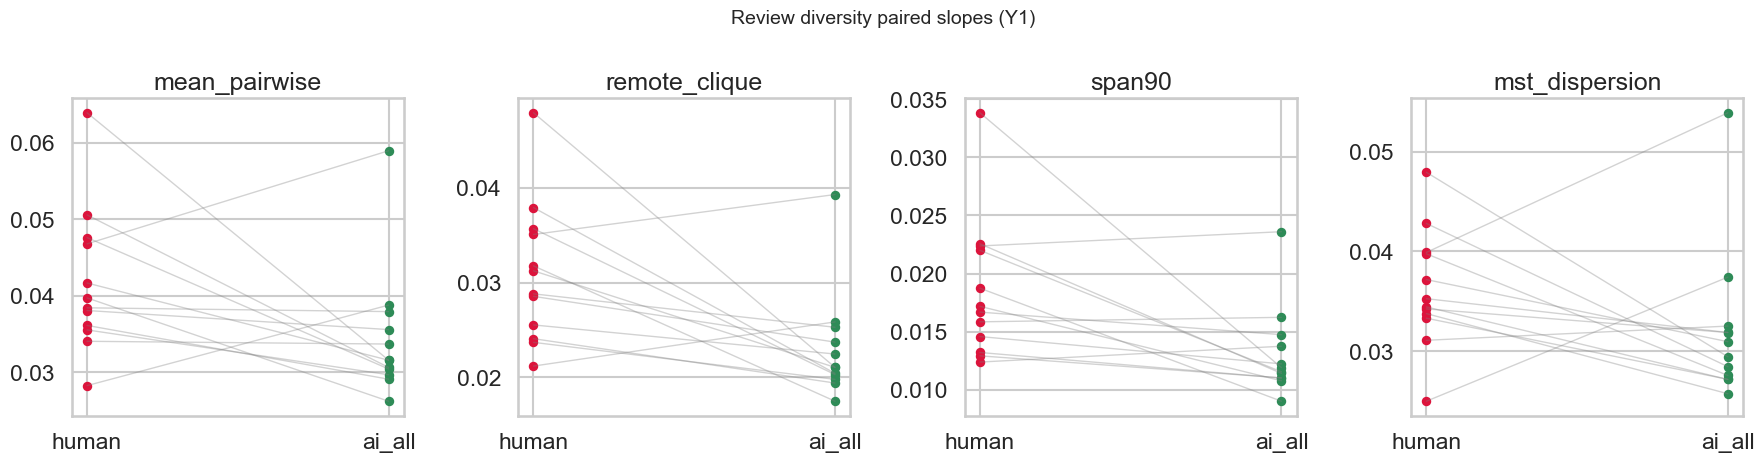

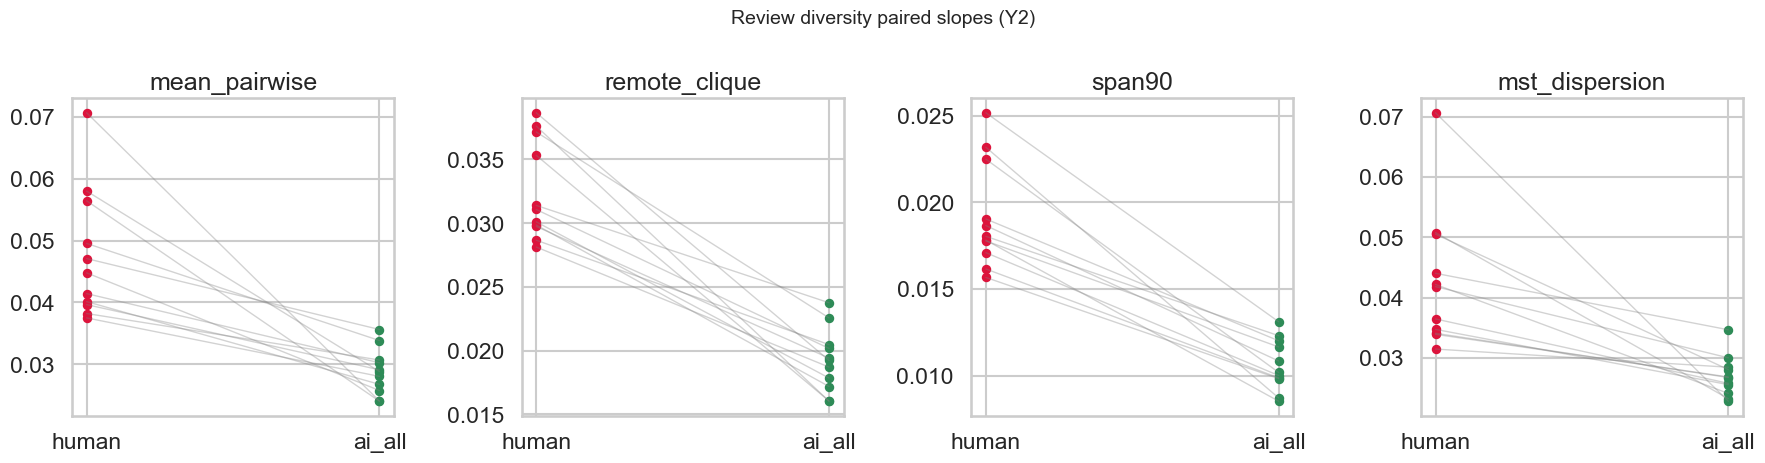

/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_89257/3802265859.py:305: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=md, x='source_family', y='metric_value', hue='cohort', dodge=True, color='black', alpha=0.3, size=3)


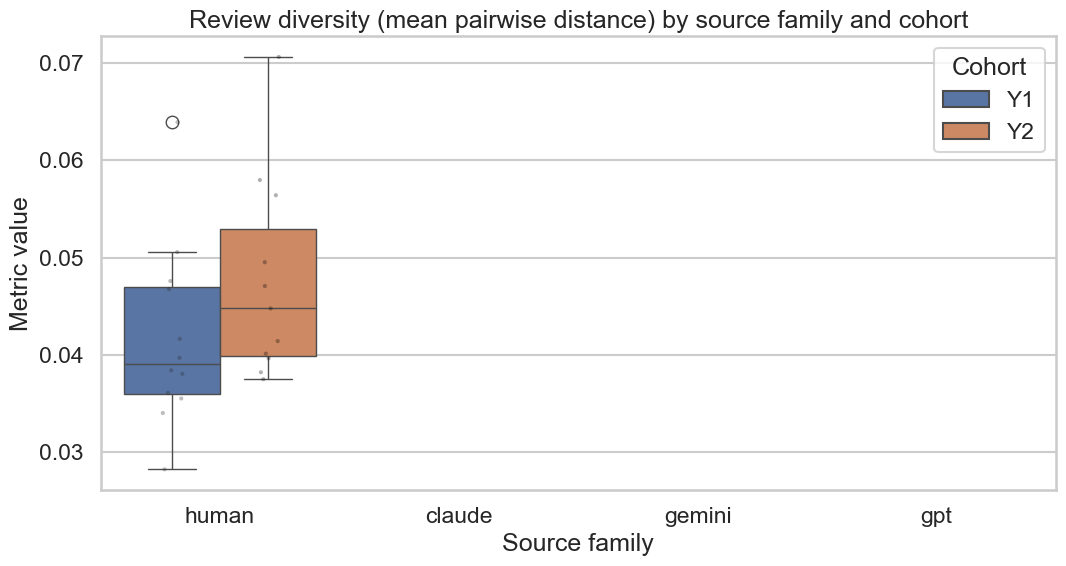

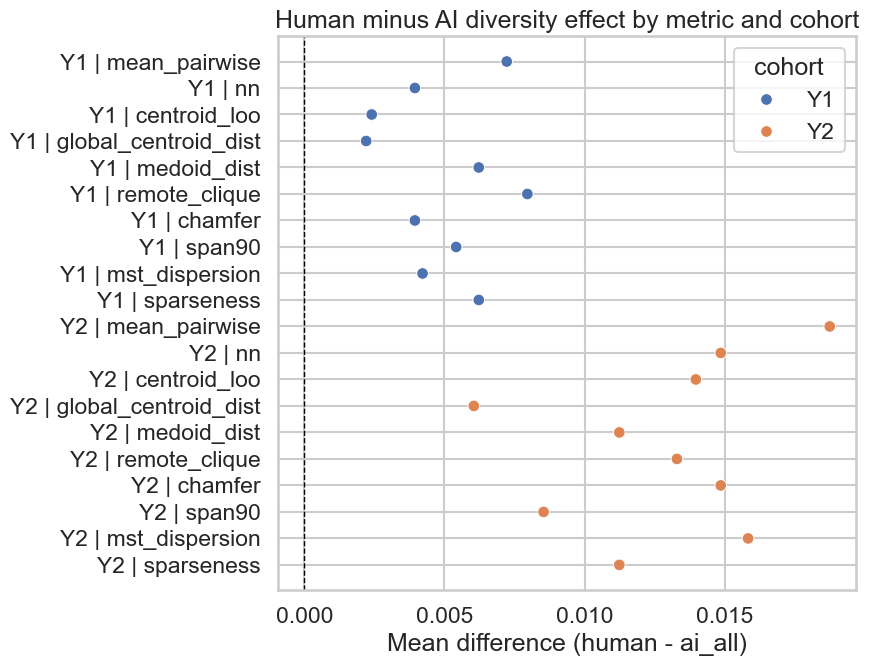

Diversity analysis complete.


In [11]:
# Build proposal-conditioned review diversity metrics for Y1 and Y2.

from scipy.sparse.csgraph import minimum_spanning_tree


def _ai_source_family(evaluator):
    s = str(evaluator).lower()
    if 'claude' in s:
        return 'claude'
    if 'gemini' in s:
        return 'gemini'
    if 'gpt' in s:
        return 'gpt'
    return 'ai_other'


def _distance_matrix(X):
    S = cosine_similarity(X)
    D = np.clip(1.0 - S, 0.0, 2.0)
    np.fill_diagonal(D, 0.0)
    return D


def _metrics_for_embeddings(emb_list):
    out = {
        'mean_pairwise': np.nan,
        'nn': np.nan,
        'centroid_loo': np.nan,
        'medoid_dist': np.nan,
        'remote_clique': np.nan,
        'chamfer': np.nan,
        'span90': np.nan,
        'mst_dispersion': np.nan,
        'sparseness': np.nan,
    }

    if emb_list is None or len(emb_list) < 2:
        return out

    X = np.vstack([np.asarray(e) for e in emb_list])
    n = X.shape[0]
    D = _distance_matrix(X)

    tri = D[np.triu_indices(n, k=1)]
    if len(tri) > 0:
        out['mean_pairwise'] = float(np.nanmean(tri))

    D_no_diag = D.copy()
    np.fill_diagonal(D_no_diag, np.nan)
    nn = np.nanmin(D_no_diag, axis=1)
    out['nn'] = float(np.nanmean(nn))

    c_all = X.mean(axis=0)
    c_norm = np.linalg.norm(c_all)
    if c_norm > 0:
        c_all = c_all / c_norm
    d_to_centroid = 1.0 - np.clip(X @ c_all, -1, 1)
    out['span90'] = float(np.nanpercentile(d_to_centroid, 90))

    loo_vals = []
    for i in range(n):
        others = np.delete(X, i, axis=0)
        if others.shape[0] == 0:
            continue
        c = others.mean(axis=0)
        c_norm = np.linalg.norm(c)
        if c_norm == 0:
            continue
        c = c / c_norm
        loo_vals.append(1.0 - float(np.clip(X[i] @ c, -1, 1)))
    if loo_vals:
        out['centroid_loo'] = float(np.nanmean(loo_vals))

    medoid_idx = int(np.argmin(D.sum(axis=1)))
    medoid_d = D[:, medoid_idx]
    out['medoid_dist'] = float(np.nanmean(medoid_d))
    out['sparseness'] = float(np.nanmean(medoid_d))

    out['remote_clique'] = float(D.sum() / (n * n))
    out['chamfer'] = out['nn']

    try:
        mst = minimum_spanning_tree(D)
        mst_vals = np.asarray(mst.data)
        if len(mst_vals) > 0:
            out['mst_dispersion'] = float(np.nanmean(mst_vals))
    except Exception:
        out['mst_dispersion'] = np.nan

    return out


def _global_centroid_distances(h_emb_list, a_emb_list):
    if len(h_emb_list) < 1 or len(a_emb_list) < 1:
        return np.nan, np.nan
    H = np.vstack([np.asarray(e) for e in h_emb_list])
    A = np.vstack([np.asarray(e) for e in a_emb_list])
    C = np.vstack([H, A]).mean(axis=0)
    c_norm = np.linalg.norm(C)
    if c_norm == 0:
        return np.nan, np.nan
    C = C / c_norm
    h_dist = 1.0 - np.clip(H @ C, -1, 1)
    a_dist = 1.0 - np.clip(A @ C, -1, 1)
    return float(np.nanmean(h_dist)), float(np.nanmean(a_dist))


def _build_diversity_tables_for_cohort(cohort_obj, cohort_tag):
    h = cohort_obj['human_aligned'].copy()
    a = cohort_obj['ai_aligned'].copy()
    a['source_family'] = a['evaluator'].map(_ai_source_family)

    metric_names = [
        'mean_pairwise', 'nn', 'centroid_loo', 'medoid_dist',
        'remote_clique', 'chamfer', 'span90', 'mst_dispersion', 'sparseness'
    ]

    rows_wide = []
    rows_long = []

    proposal_keys = sorted(set(h['proposal_key']).intersection(set(a['proposal_key'])))

    for pk in proposal_keys:
        hg = h[h['proposal_key'] == pk]
        ag = a[a['proposal_key'] == pk]

        h_emb = hg['embedding'].tolist()
        a_all_emb = ag['embedding'].tolist()
        a_claude_emb = ag[ag['source_family'] == 'claude']['embedding'].tolist()
        a_gemini_emb = ag[ag['source_family'] == 'gemini']['embedding'].tolist()
        a_gpt_emb = ag[ag['source_family'] == 'gpt']['embedding'].tolist()

        fam_blocks = {
            'human': h_emb,
            'ai_all': a_all_emb,
            'claude': a_claude_emb,
            'gemini': a_gemini_emb,
            'gpt': a_gpt_emb,
        }

        fam_metrics = {fam: _metrics_for_embeddings(embs) for fam, embs in fam_blocks.items()}

        h_gc, a_gc = _global_centroid_distances(h_emb, a_all_emb)
        fam_metrics['human']['global_centroid_dist_vs_ai_all'] = h_gc
        fam_metrics['ai_all']['global_centroid_dist_vs_human'] = a_gc
        for fam in ['claude', 'gemini', 'gpt']:
            fam_metrics[fam]['global_centroid_dist_vs_human'] = np.nan

        prop_uid = hg['proposal_uid'].iloc[0] if len(hg) else np.nan
        prop_title = hg['title'].iloc[0] if len(hg) else np.nan

        wide = {
            'cohort': cohort_tag,
            'proposal_key': pk,
            'proposal_uid': prop_uid,
            'proposal_title': prop_title,
        }

        for fam, m in fam_metrics.items():
            for mn in metric_names:
                wide[f'{fam}_{mn}'] = m.get(mn, np.nan)
                rows_long.append({
                    'cohort': cohort_tag,
                    'proposal_key': pk,
                    'proposal_uid': prop_uid,
                    'proposal_title': prop_title,
                    'source_family': fam,
                    'metric_name': mn,
                    'metric_value': m.get(mn, np.nan),
                })

            gc_key = 'global_centroid_dist_vs_ai_all' if fam == 'human' else 'global_centroid_dist_vs_human'
            wide[f'{fam}_{gc_key}'] = fam_metrics[fam].get(gc_key, np.nan)
            rows_long.append({
                'cohort': cohort_tag,
                'proposal_key': pk,
                'proposal_uid': prop_uid,
                'proposal_title': prop_title,
                'source_family': fam,
                'metric_name': 'global_centroid_dist',
                'metric_value': fam_metrics[fam].get(gc_key, np.nan),
            })

        rows_wide.append(wide)

    return pd.DataFrame(rows_wide), pd.DataFrame(rows_long)


def _paired_test_df(df_wide, cohort_tag, model='ai_all'):
    metric_specs = [
        ('mean_pairwise', 'human_mean_pairwise', f'{model}_mean_pairwise'),
        ('nn', 'human_nn', f'{model}_nn'),
        ('centroid_loo', 'human_centroid_loo', f'{model}_centroid_loo'),
        ('global_centroid_dist', 'human_global_centroid_dist_vs_ai_all', f'{model}_global_centroid_dist_vs_human'),
        ('medoid_dist', 'human_medoid_dist', f'{model}_medoid_dist'),
        ('remote_clique', 'human_remote_clique', f'{model}_remote_clique'),
        ('chamfer', 'human_chamfer', f'{model}_chamfer'),
        ('span90', 'human_span90', f'{model}_span90'),
        ('mst_dispersion', 'human_mst_dispersion', f'{model}_mst_dispersion'),
        ('sparseness', 'human_sparseness', f'{model}_sparseness'),
    ]

    rows = []
    for metric, h_col, a_col in metric_specs:
        if h_col not in df_wide.columns or a_col not in df_wide.columns:
            continue
        sub = df_wide[['proposal_key', h_col, a_col]].dropna()
        if len(sub) == 0:
            continue

        try:
            w_stat, w_p = wilcoxon(sub[h_col], sub[a_col]) if len(sub) >= 2 else (np.nan, np.nan)
        except Exception:
            w_stat, w_p = np.nan, np.nan

        mw = mannwhitney_summary(sub[h_col], sub[a_col], metric_name=metric)

        rows.append({
            'cohort': cohort_tag,
            'comparison': f'human-vs-{model}',
            'metric_name': metric,
            'n_pairs': int(len(sub)),
            'wilcoxon_stat': w_stat,
            'wilcoxon_p_value': w_p,
            'mw_u_stat': mw['u_stat'],
            'mw_p_value': mw['p_value'],
            'cliffs_delta_human_minus_ai': mw['cliffs_delta'],
            'delta_magnitude': mw['delta_magnitude'],
            'mean_diff_human_minus_ai': float((sub[h_col] - sub[a_col]).mean()),
            'median_diff_human_minus_ai': float((sub[h_col] - sub[a_col]).median()),
        })

    out = pd.DataFrame(rows)
    if len(out):
        out['wilcoxon_q_value'] = add_bh_fdr(out.rename(columns={'wilcoxon_p_value': 'p_value'}), p_col='p_value')['q_value']
        out['mw_q_value'] = add_bh_fdr(out.rename(columns={'mw_p_value': 'p_value'}), p_col='p_value')['q_value']
    return out


review_diversity_y1_wide_df, review_diversity_y1_long_df = _build_diversity_tables_for_cohort(cohort_y1, 'Y1')
review_diversity_y2_wide_df, review_diversity_y2_long_df = _build_diversity_tables_for_cohort(cohort_y2, 'Y2')

review_diversity_y1_tests_human_vs_ai = _paired_test_df(review_diversity_y1_wide_df, 'Y1', model='ai_all')
review_diversity_y2_tests_human_vs_ai = _paired_test_df(review_diversity_y2_wide_df, 'Y2', model='ai_all')
review_diversity_within_cohort_human_vs_ai_df = pd.concat(
    [review_diversity_y1_tests_human_vs_ai, review_diversity_y2_tests_human_vs_ai],
    ignore_index=True
)

by_model = []
for cohort_tag, wide_df in [('Y1', review_diversity_y1_wide_df), ('Y2', review_diversity_y2_wide_df)]:
    for model in ['claude', 'gemini', 'gpt']:
        t = _paired_test_df(wide_df, cohort_tag, model=model)
        if len(t):
            by_model.append(t)
review_diversity_human_vs_ai_by_model_df = pd.concat(by_model, ignore_index=True) if by_model else pd.DataFrame()

review_diversity_all_long_df = pd.concat([review_diversity_y1_long_df, review_diversity_y2_long_df], ignore_index=True)

print('Diversity proposal-level rows:')
print('Y1 wide:', review_diversity_y1_wide_df.shape)
print('Y2 wide:', review_diversity_y2_wide_df.shape)
print('Within-cohort Human-vs-AI tests:', review_diversity_within_cohort_human_vs_ai_df.shape)

# --- Visualizations ---
def _plot_paired_slopes(df_wide, cohort_tag, outfile):
    pairs = [
        ('mean_pairwise', 'human_mean_pairwise', 'ai_all_mean_pairwise'),
        ('remote_clique', 'human_remote_clique', 'ai_all_remote_clique'),
        ('span90', 'human_span90', 'ai_all_span90'),
        ('mst_dispersion', 'human_mst_dispersion', 'ai_all_mst_dispersion'),
    ]
    fig, axes = plt.subplots(1, len(pairs), figsize=(18, 4.8), sharey=False)
    for ax, (label, hcol, acol) in zip(axes, pairs):
        sub = df_wide[['proposal_key', hcol, acol]].dropna()
        if len(sub) == 0:
            ax.set_title(f'{label} (no data)')
            ax.axis('off')
            continue
        for _, r in sub.iterrows():
            ax.plot([0, 1], [r[hcol], r[acol]], color='gray', alpha=0.35, linewidth=1)
        ax.scatter(np.zeros(len(sub)), sub[hcol], color=colors['Human'], s=28, label='human')
        ax.scatter(np.ones(len(sub)), sub[acol], color='#2E8B57', s=28, label='ai_all')
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['human', 'ai_all'])
        ax.set_title(label)
    fig.suptitle(f'Review diversity paired slopes ({cohort_tag})', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / outfile, dpi=200, bbox_inches='tight')
    plt.show()


_plot_paired_slopes(review_diversity_y1_wide_df, 'Y1', 'quality_review_diversity_y1_paired_slopes.png')
_plot_paired_slopes(review_diversity_y2_wide_df, 'Y2', 'quality_review_diversity_y2_paired_slopes.png')

# Model-aware distribution view (mean pairwise only for clarity)
md = review_diversity_all_long_df[
    (review_diversity_all_long_df['metric_name'] == 'mean_pairwise')
    & (review_diversity_all_long_df['source_family'].isin(['human', 'claude', 'gemini', 'gpt']))
].copy()

if len(md):
    plt.figure(figsize=(11, 6))
    sns.boxplot(data=md, x='source_family', y='metric_value', hue='cohort')
    sns.stripplot(data=md, x='source_family', y='metric_value', hue='cohort', dodge=True, color='black', alpha=0.3, size=3)
    plt.title('Review diversity (mean pairwise distance) by source family and cohort')
    plt.xlabel('Source family')
    plt.ylabel('Metric value')
    handles, labels = plt.gca().get_legend_handles_labels()
    if handles:
        # keep one legend set
        uniq = []
        seen = set()
        for h, l in zip(handles, labels):
            if l not in seen:
                uniq.append((h, l))
                seen.add(l)
        plt.legend([u[0] for u in uniq], [u[1] for u in uniq], title='Cohort')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'quality_review_diversity_by_model.png', dpi=200, bbox_inches='tight')
    plt.show()

# Effect dotplot (within-cohort human-vs-ai_all)
ed = review_diversity_within_cohort_human_vs_ai_df.copy()
if len(ed):
    ed['label'] = ed['cohort'] + ' | ' + ed['metric_name']
    plt.figure(figsize=(9, max(5, 0.35 * len(ed))))
    sns.scatterplot(data=ed, x='mean_diff_human_minus_ai', y='label', hue='cohort', s=70)
    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.title('Human minus AI diversity effect by metric and cohort')
    plt.xlabel('Mean difference (human - ai_all)')
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'quality_review_diversity_effects_dotplot.png', dpi=200, bbox_inches='tight')
    plt.show()

print('Diversity analysis complete.')


## R1-Q2) How similar are AI reviews to human reviews?

## 8) Similarity proxy stats (proposal-level, model-aware, FDR-corrected)

**Purpose**
This section evaluates whether AI review text behaves like a reliable proxy for human expert review text quality judgments.

**How this is done**
1. Aggregate pairwise metrics to proposal-level means (human-human, human-AI, AI-AI) to reduce pseudo-replication.
2. **Primary test: paired Wilcoxon signed-rank** on the matched proposal-level means across comparison types.
3. **Secondary / sensitivity check: Mann-Whitney U + Cliff's delta** (reported but not primary — see note on independence below).
4. Apply Benjamini-Hochberg FDR correction within each metric family.
5. Break down results by AI model (`human-ai`) and AI model pair (`ai-ai`).

**Statistical note: why Wilcoxon is the primary test**

Mann-Whitney U assumes the two samples are **independent**. That assumption is violated here:
the same ~12 proposals appear in both `human-ai` and `human-human` (and `ai-ai`), so their
proposal-level means are paired — a proposal that is clearer or more coherent will tend to score
similarly in all comparison types. Using Mann-Whitney as the primary test risks inflated Type I
errors because it ignores this positive within-proposal correlation.

The **paired Wilcoxon signed-rank test** handles this correctly by testing the signed differences
on matched proposal pairs, and is the appropriate primary statistic. Mann-Whitney is retained as a
sensitivity check for robustness (e.g. to detect whether the pairing assumption itself drives results).

For the model-stratified comparisons (`human-ai::model` vs `human-human`), the same proposals
appear in both groups, so Wilcoxon remains the primary test there too.


In [12]:
# Purpose:
# Summarize similarity metrics at proposal-level and test whether human-AI / AI-AI
# comparisons differ from human-human baseline.
#
# PRIMARY test: paired Wilcoxon signed-rank (same ~12 proposals appear in both groups
#   being compared, so the two samples are NOT independent -> Mann-Whitney U assumption
#   violated; Wilcoxon exploits the matched structure correctly).
#
# SECONDARY: Mann-Whitney U + Cliff's delta retained as a sensitivity / robustness check.
#
# FDR correction applied within each metric family (BH).
SIM_METRICS = ['cosine_similarity', 'sentiment_alignment', 'categorical_agreement_num']

human_human_prop = (
    pair_df[pair_df['pair_type'] == 'human-human']
    .groupby('proposal_key')[SIM_METRICS]
    .mean()
    .reset_index()
)
human_ai_prop = (
    pair_df[pair_df['pair_type'] == 'human-ai']
    .groupby('proposal_key')[SIM_METRICS]
    .mean()
    .reset_index()
)
ai_ai_prop = (
    pair_df[pair_df['pair_type'] == 'ai-ai']
    .groupby('proposal_key')[SIM_METRICS]
    .mean()
    .reset_index()
)

overall_tests = []
for m in SIM_METRICS:
    for g1_name, g1_df, g2_name, g2_df in [
        ('human-ai', human_ai_prop, 'human-human', human_human_prop),
        ('ai-ai', ai_ai_prop, 'human-human', human_human_prop),
        ('ai-ai', ai_ai_prop, 'human-ai', human_ai_prop),
    ]:
        out = mannwhitney_summary(g1_df[m], g2_df[m], metric_name=m)
        out['group1'] = g1_name
        out['group2'] = g2_name

        merged = g1_df[['proposal_key', m]].merge(g2_df[['proposal_key', m]], on='proposal_key', suffixes=('_1', '_2'))
        try:
            w_stat, w_p = wilcoxon(merged[f'{m}_1'], merged[f'{m}_2'])
        except Exception:
            w_stat, w_p = np.nan, np.nan
        out['wilcoxon_stat'] = w_stat
        out['wilcoxon_p_value'] = w_p
        out['n_paired_proposals'] = len(merged)

        overall_tests.append(out)

sim_stats_overall_df = pd.DataFrame(overall_tests)
sim_stats_overall_df = add_bh_fdr(sim_stats_overall_df, p_col='p_value', group_cols=['metric'])

human_ai_by_model_prop = (
    pair_df[pair_df['pair_type'] == 'human-ai']
    .groupby(['proposal_key', 'ai_model'])[SIM_METRICS]
    .mean()
    .reset_index()
)

rows = []
for m in SIM_METRICS:
    for model in sorted(human_ai_by_model_prop['ai_model'].dropna().unique()):
        sub = human_ai_by_model_prop[human_ai_by_model_prop['ai_model'] == model]
        out = mannwhitney_summary(sub[m], human_human_prop[m], metric_name=m)
        out['group1'] = f'human-ai::{model}'
        out['group2'] = 'human-human'
        out['ai_model'] = model
        rows.append(out)

sim_stats_hai_by_model_df = pd.DataFrame(rows)
sim_stats_hai_by_model_df = add_bh_fdr(sim_stats_hai_by_model_df, p_col='p_value', group_cols=['metric'])

ai_ai_by_pair_prop = (
    pair_df[pair_df['pair_type'] == 'ai-ai']
    .groupby(['proposal_key', 'ai_model_pair'])[SIM_METRICS]
    .mean()
    .reset_index()
)

rows = []
for m in SIM_METRICS:
    for mp in sorted(ai_ai_by_pair_prop['ai_model_pair'].dropna().unique()):
        sub = ai_ai_by_pair_prop[ai_ai_by_pair_prop['ai_model_pair'] == mp]
        out = mannwhitney_summary(sub[m], human_human_prop[m], metric_name=m)
        out['group1'] = f'ai-ai::{mp}'
        out['group2'] = 'human-human'
        out['ai_model_pair'] = mp
        rows.append(out)

sim_stats_aiai_by_pair_df = pd.DataFrame(rows)
sim_stats_aiai_by_pair_df = add_bh_fdr(sim_stats_aiai_by_pair_df, p_col='p_value', group_cols=['metric'])

# ---- results (Wilcoxon = primary, Mann-Whitney = secondary/sensitivity) ----
cols_primary = ['metric', 'group1', 'group2', 'n_paired_proposals',
                'wilcoxon_stat', 'wilcoxon_p_value',
                'n_group1', 'n_group2', 'u_stat', 'p_value', 'p_value_fdr',
                'cliffs_delta', 'delta_magnitude']

def _reorder(df, cols):
    present = [c for c in cols if c in df.columns]
    rest = [c for c in df.columns if c not in present]
    return df[present + rest]

print('Overall pair-type stats (primary: wilcoxon_p_value, secondary: p_value):')  
display(_reorder(sim_stats_overall_df, cols_primary))
print('Human-AI by model stats:')  
display(_reorder(sim_stats_hai_by_model_df, cols_primary))
print('AI-AI by model-pair stats:')  
display(_reorder(sim_stats_aiai_by_pair_df, cols_primary))


Overall pair-type stats (primary: wilcoxon_p_value, secondary: p_value):


,metric,group1,group2,n_paired_proposals,wilcoxon_stat,wilcoxon_p_value,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,q_value
0,cosine_similarity,human-ai,human-human,12,37.0,0.909668,12,12,66.0,0.750832,-0.083333,negligible,0.750832
1,cosine_similarity,ai-ai,human-human,12,15.0,0.063965,12,12,113.0,0.019373,0.569444,large,0.029060
2,cosine_similarity,ai-ai,human-ai,12,9.0,0.016113,12,12,125.0,0.002437,0.736111,large,0.007310
3,sentiment_alignment,human-ai,human-human,12,24.0,0.266113,12,12,82.0,0.583360,0.138889,negligible,0.583360
4,sentiment_alignment,ai-ai,human-human,12,18.0,0.109863,12,12,98.0,0.140955,0.361111,medium,0.321741
5,sentiment_alignment,ai-ai,human-ai,12,27.0,0.380371,12,12,94.0,0.214494,0.305556,small,0.321741
6,categorical_agreement_num,human-ai,human-human,12,0.0,0.125000,12,12,80.0,0.626796,0.111111,negligible,0.626796
7,categorical_agreement_num,ai-ai,human-human,12,0.0,0.062500,12,12,102.0,0.016011,0.416667,medium,0.024016
8,categorical_agreement_num,ai-ai,human-ai,12,0.0,0.062500,12,12,102.0,0.016011,0.416667,medium,0.024016


Human-AI by model stats:


,metric,group1,group2,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,ai_model,q_value
0,cosine_similarity,human-ai::claude-opus-4-5,human-human,12,12,69.0,0.885234,-0.041667,negligible,claude-opus-4-5,0.885234
1,cosine_similarity,human-ai::gemini-3-pro-preview,human-human,12,12,78.0,0.750832,0.083333,negligible,gemini-3-pro-preview,0.885234
2,cosine_similarity,human-ai::gpt-5.2,human-human,12,12,55.0,0.340779,-0.236111,small,gpt-5.2,0.885234
3,sentiment_alignment,human-ai::claude-opus-4-5,human-human,12,12,86.0,0.435731,0.194444,small,claude-opus-4-5,0.435731
4,sentiment_alignment,human-ai::gemini-3-pro-preview,human-human,12,12,88.0,0.370844,0.222222,small,gemini-3-pro-preview,0.435731
5,sentiment_alignment,human-ai::gpt-5.2,human-human,12,12,89.0,0.340779,0.236111,small,gpt-5.2,0.435731
6,categorical_agreement_num,human-ai::claude-opus-4-5,human-human,12,12,80.0,0.626796,0.111111,negligible,claude-opus-4-5,0.626796
7,categorical_agreement_num,human-ai::gemini-3-pro-preview,human-human,12,12,80.0,0.626796,0.111111,negligible,gemini-3-pro-preview,0.626796
8,categorical_agreement_num,human-ai::gpt-5.2,human-human,12,12,80.0,0.626796,0.111111,negligible,gpt-5.2,0.626796


AI-AI by model-pair stats:


,metric,group1,group2,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,ai_model_pair,q_value
0,cosine_similarity,ai-ai::claude-opus-4-5 vs gemini-3-pro-preview,human-human,12,12,115.0,0.014138,0.597222,large,claude-opus-4-5 vs gemini-3-pro-preview,0.042414
1,cosine_similarity,ai-ai::claude-opus-4-5 vs gpt-5.2,human-human,12,12,106.0,0.053098,0.472222,medium,claude-opus-4-5 vs gpt-5.2,0.053098
2,cosine_similarity,ai-ai::gemini-3-pro-preview vs gpt-5.2,human-human,12,12,108.0,0.040404,0.500000,large,gemini-3-pro-preview vs gpt-5.2,0.053098
3,sentiment_alignment,ai-ai::claude-opus-4-5 vs gemini-3-pro-preview,human-human,12,12,108.0,0.040404,0.500000,large,claude-opus-4-5 vs gemini-3-pro-preview,0.121212
4,sentiment_alignment,ai-ai::claude-opus-4-5 vs gpt-5.2,human-human,12,12,97.0,0.157213,0.347222,medium,claude-opus-4-5 vs gpt-5.2,0.157213
5,sentiment_alignment,ai-ai::gemini-3-pro-preview vs gpt-5.2,human-human,12,12,97.0,0.157213,0.347222,medium,gemini-3-pro-preview vs gpt-5.2,0.157213
6,categorical_agreement_num,ai-ai::claude-opus-4-5 vs gemini-3-pro-preview,human-human,12,12,102.0,0.016011,0.416667,medium,claude-opus-4-5 vs gemini-3-pro-preview,0.016011
7,categorical_agreement_num,ai-ai::claude-opus-4-5 vs gpt-5.2,human-human,12,12,102.0,0.016011,0.416667,medium,claude-opus-4-5 vs gpt-5.2,0.016011
8,categorical_agreement_num,ai-ai::gemini-3-pro-preview vs gpt-5.2,human-human,12,12,102.0,0.016011,0.416667,medium,gemini-3-pro-preview vs gpt-5.2,0.016011


### Interpretation: Similarity Proxy Statistics

#### Primary test — Paired Wilcoxon signed-rank (`wilcoxon_stat`, `wilcoxon_p_value`)

Because the same proposals appear in both groups being compared (paired/matched design), the Wilcoxon signed-rank test is the primary statistical test.

- **`wilcoxon_stat` (W):** The sum of ranks of the *positive* differences (group 1 − group 2 per matched proposal). A large W means group 1 tends to score higher; a small W (near 0) means group 2 tends to score higher. For \(n\) paired proposals the statistic ranges from 0 to \(n(n+1)/2\).
- **`wilcoxon_p_value`:** Two-sided *p*-value testing the null hypothesis that the median signed difference is zero. Use `wilcoxon_p_value < 0.05` (or `< 0.10` for small samples) to flag a meaningful difference. Note that with only ~12 proposal pairs the test has limited power; a non-significant result does not rule out a real difference.

#### Secondary test — Mann-Whitney U (`u_stat`, `p_value`, `q_value`) — sensitivity check only

The Mann-Whitney U treats the two groups as independent, which is not satisfied here (same proposals in both groups). It is retained only as a sensitivity check.

- **`p_value` / `q_value`:** `q_value` is the BH-FDR-corrected *p*-value across tests within the same metric family. Use it — not the raw `p_value` — when scanning multiple rows.
- If `wilcoxon_p_value` and `p_value` broadly agree, inference is more robust. If they diverge, trust `wilcoxon_p_value` and report the discrepancy as a limitation of the small paired sample.

#### Effect size — Cliff's delta (`cliffs_delta`, `delta_magnitude`)

Cliff's delta is independent of the paired vs. unpaired distinction (it is a rank-based overlap statistic), so it is valid here regardless of which *p*-value you rely on.

- **Sign:** positive → group 1 values tend to be *higher* than group 2; negative → group 1 tends to be *lower*.
- **Magnitude labels:** negligible (|δ| < 0.147), small (< 0.33), medium (< 0.474), large (≥ 0.474).
- Report as: *"X was higher in group 1 than group 2 (δ = …, magnitude; Wilcoxon p = …)"*.

#### Example interpretations:
(1) AI vs human agreement is roughly on par with human-human agreement (Row 0, n.s.) — AI reviews are not dramatically foreign to human reviewers.
(2) But AI reviewers are much more similar to each other than humans are to each other (Row 1, large effect) — AI reviews converge; human reviews genuinely diverge.
(3) And AI reviewers agree with each other far more than with human reviewers (Row 2, near-perfect effect) — the AI evaluators form a tight cluster that is semantically distinct from the human reviewer cluster.


## 8b) Similarity proxy visualization (proposal-level)


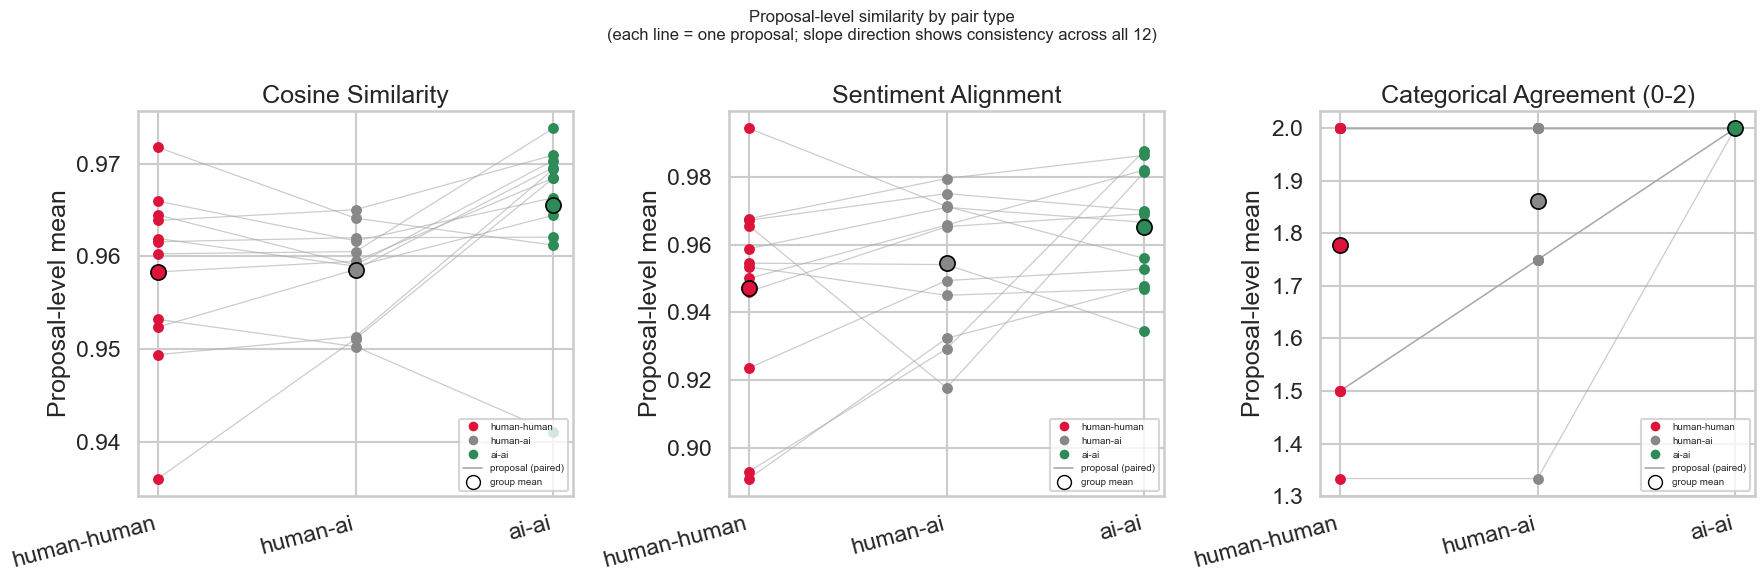

/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_89257/1617332038.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=human_ai_by_model_prop, x='ai_model', y=metric,
/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_89257/1617332038.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=human_ai_by_model_prop, x='ai_model', y=metric,
/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_89257/1617332038.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=human_ai_by_model_prop, x='ai_model', y=metric,


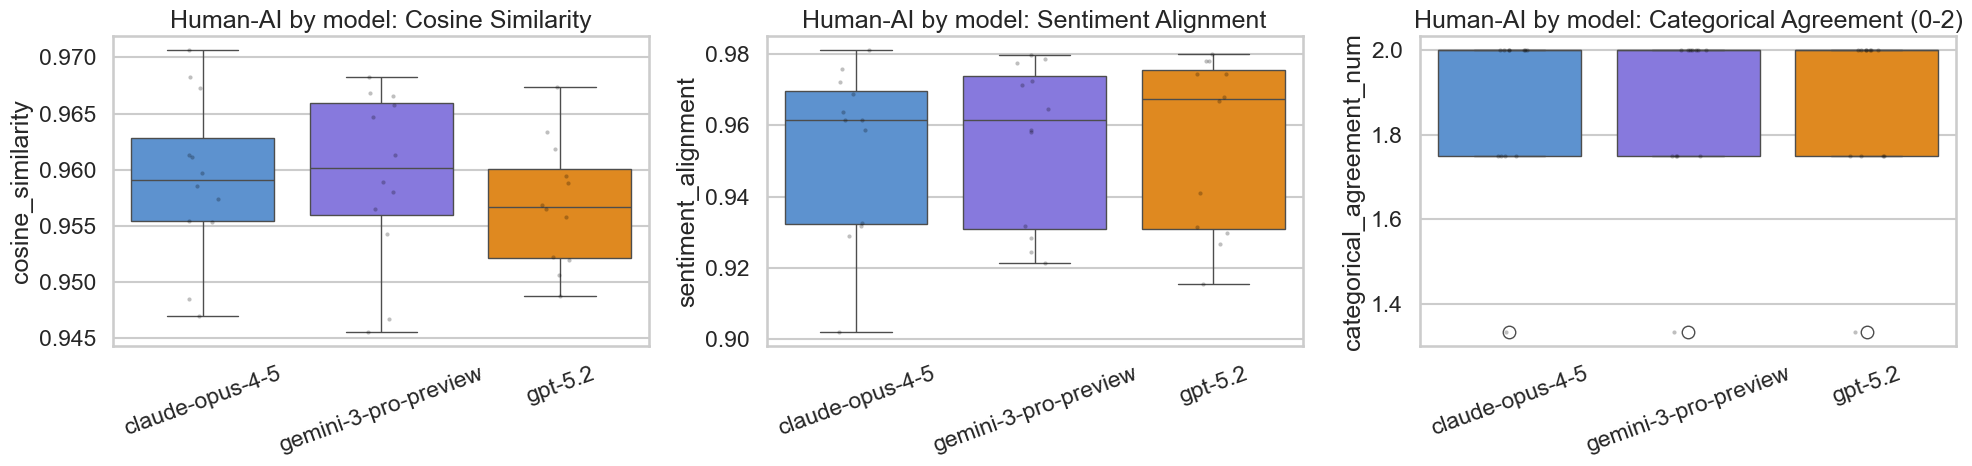

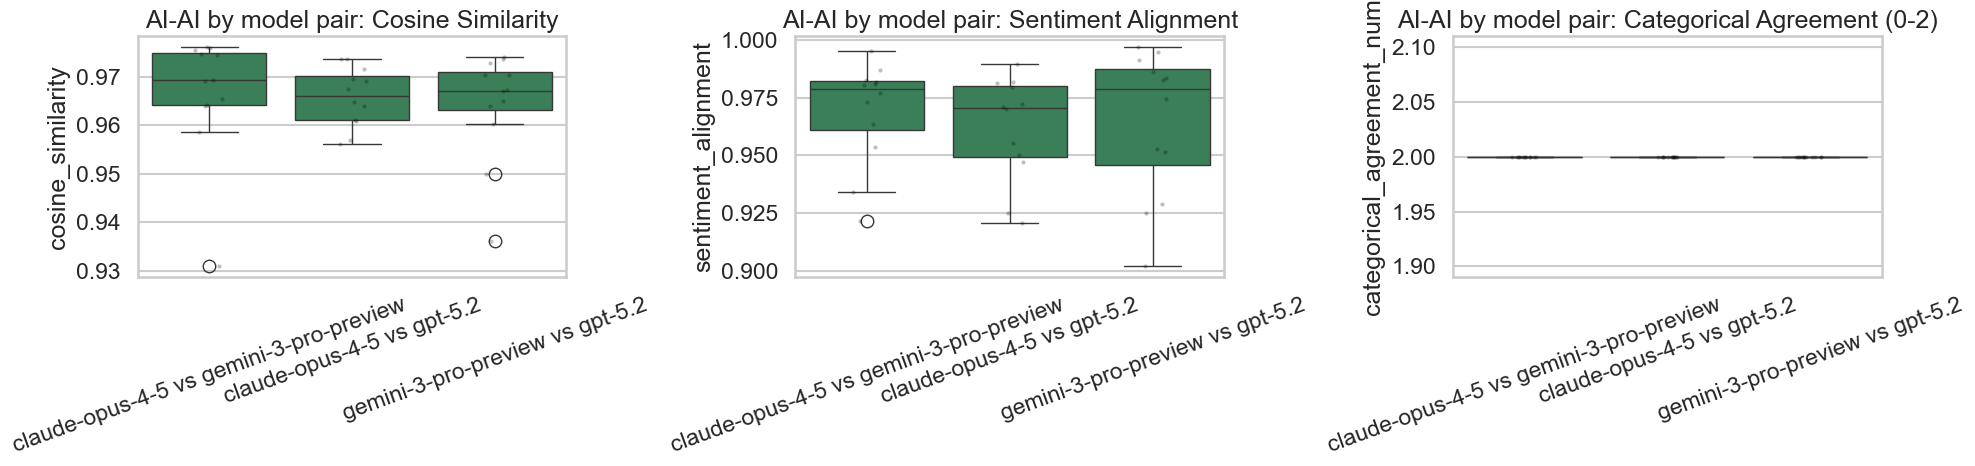

In [13]:
# Paired slope plot (primary): each line = one proposal, connecting its
# proposal-level mean across pair types. Directly shows the paired structure
# used by Wilcoxon (e.g. W=0 means every proposal had the same direction).
#
# Figure 2/3: Boxplots for unpaired model/pair-level breakdowns (appropriate there).

pt_order   = ['human-human', 'human-ai', 'ai-ai']
pt_palette = {'human-human': colors['Human'], 'human-ai': '#888888', 'ai-ai': '#2E8B57'}

# Wide table: one row per proposal, columns per (pair_type x metric)
wide_hh = human_human_prop.set_index('proposal_key')[SIM_METRICS].add_suffix('__human-human')
wide_ha = human_ai_prop.set_index('proposal_key')[SIM_METRICS].add_suffix('__human-ai')
wide_aa = ai_ai_prop.set_index('proposal_key')[SIM_METRICS].add_suffix('__ai-ai')
wide_df = wide_hh.join(wide_ha, how='inner').join(wide_aa, how='inner')

metric_titles = {
    'cosine_similarity':         'Cosine Similarity',
    'sentiment_alignment':       'Sentiment Alignment',
    'categorical_agreement_num': 'Categorical Agreement (0-2)',
}

# --- Figure 1: Paired slope plot ---
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Proposal-level similarity by pair type\n'
    '(each line = one proposal; slope direction shows consistency across all 12)',
    fontsize=12,
)

for ax, metric in zip(axes, SIM_METRICS):
    for pk, row in wide_df.iterrows():
        ys = [row[f'{metric}__{pt}'] for pt in pt_order]
        ax.plot(range(3), ys, color='#aaaaaa', linewidth=0.9, alpha=0.6, zorder=1)
        for xi, (pt, y) in enumerate(zip(pt_order, ys)):
            ax.scatter(xi, y, color=pt_palette[pt], s=40, zorder=2)
    # Group means as large outlined markers
    for xi, pt in enumerate(pt_order):
        mean = wide_df[f'{metric}__{pt}'].mean()
        ax.scatter(xi, mean, color=pt_palette[pt], s=120, zorder=3,
                   edgecolors='black', linewidths=1.2)
    ax.set_xticks(range(3))
    ax.set_xticklabels(pt_order, rotation=15, ha='right')
    ax.set_title(metric_titles[metric])
    ax.set_ylabel('Proposal-level mean')
    legend_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=pt_palette[pt],
               markersize=8, label=pt)
        for pt in pt_order
    ] + [
        Line2D([0], [0], color='#aaaaaa', linewidth=1.2, label='proposal (paired)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
               markeredgecolor='black', markersize=10, label='group mean'),
    ]
    ax.legend(handles=legend_handles, fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_similarity_proxy_paired_slopes.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Figure 2: Human-AI breakdown by evaluator model ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
model_order   = sorted(human_ai_by_model_prop['ai_model'].dropna().unique())
model_palette = {m: colors.get(m, '#999999') for m in model_order}
for ax, metric, title in zip(axes, SIM_METRICS, metric_titles.values()):
    sns.boxplot(data=human_ai_by_model_prop, x='ai_model', y=metric,
                order=model_order, ax=ax, palette=model_palette)
    sns.stripplot(data=human_ai_by_model_prop, x='ai_model', y=metric,
                  order=model_order, ax=ax, color='black', alpha=0.25, size=3)
    ax.set_title(f'Human-AI by model: {title}')
    ax.tick_params(axis='x', rotation=20)
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_similarity_human_ai_by_model_proposal_level.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Figure 3: AI-AI breakdown by model pair ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
pair_order = sorted(ai_ai_by_pair_prop['ai_model_pair'].dropna().unique())
for ax, metric, title in zip(axes, SIM_METRICS, metric_titles.values()):
    sns.boxplot(data=ai_ai_by_pair_prop, x='ai_model_pair', y=metric,
                order=pair_order, ax=ax, color='#2E8B57')
    sns.stripplot(data=ai_ai_by_pair_prop, x='ai_model_pair', y=metric,
                  order=pair_order, ax=ax, color='black', alpha=0.25, size=3)
    ax.set_title(f'AI-AI by model pair: {title}')
    ax.tick_params(axis='x', rotation=20)
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_similarity_ai_ai_by_model_pair_proposal_level.png', dpi=200, bbox_inches='tight')
plt.show()


### Interpretation: Similarity Plots

- **Human-human** provides the inter-expert baseline.
- If **human-AI** distribution overlaps strongly with human-human, AI reviews behave more like human proxy ratings.
- If **AI-AI** is much tighter/higher than human-human, AI reviewers may be internally consistent but not necessarily human-aligned.
- In model-specific plots, identify which AI model drives deviation from human baseline.


### 8e) Rephrased review similarity analyses (Y1, Y2, combined)

This section runs cohort-parallel rephrased review similarity for Y1 and Y2.

Outputs include:
- cohort-level pairwise similarity tables for Y1 and Y2
- a single four-group comparison plot (`human-y1`, `ai-y1`, `human-y2`, `ai-y2`)
- significance tests across all four groups and paired within-cohort tests


#### 8e.1) Combined Y1/Y2 Pairwise Similarity Graph + Significance Tests

/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_89257/2240269327.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sim_4group, x='group', y='cosine_similarity', order=order_4, palette=palette_4)


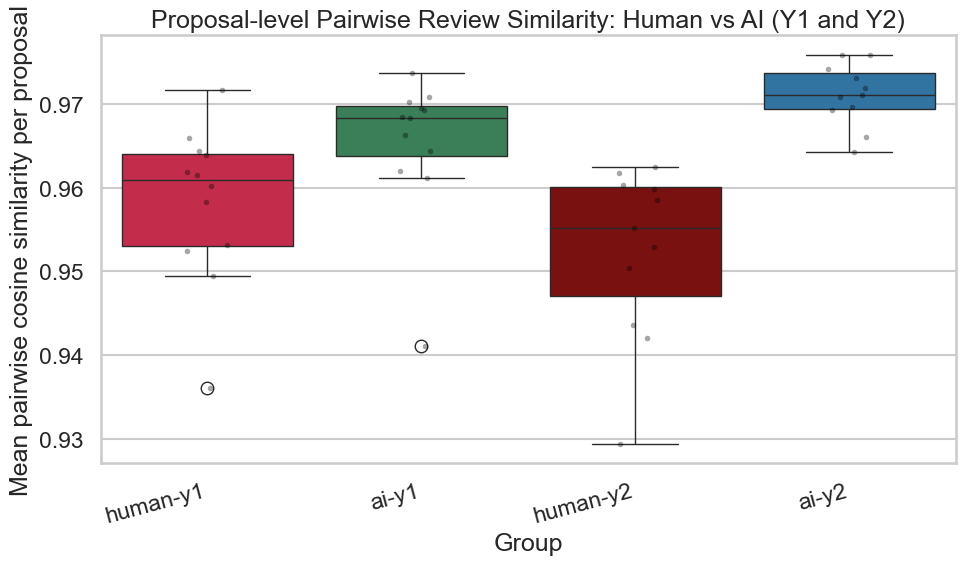

Kruskal-Wallis across 4 groups: {'stat': np.float64(25.742031788747795), 'p_value': np.float64(1.0800224387225907e-05)}

Pairwise 4-group tests (Mann-Whitney + Cliff's delta + BH-FDR):


,metric,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,group1,group2,mean_group1,mean_group2,q_value
5,cosine_similarity,11,11,0.0,0.000082,-1.000000,large,human-y2,ai-y2,0.952415,0.971167,0.000489
2,cosine_similarity,12,11,8.0,0.000402,-0.878788,large,human-y1,ai-y2,0.958279,0.971167,0.001205
3,cosine_similarity,12,11,119.0,0.001233,0.803030,large,ai-y1,human-y2,0.965502,0.952415,0.002466
0,cosine_similarity,12,12,31.0,0.019373,-0.569444,large,human-y1,ai-y1,0.958279,0.965502,0.029060
4,cosine_similarity,12,11,30.0,0.028898,-0.545455,large,ai-y1,ai-y2,0.965502,0.971167,0.034678
1,cosine_similarity,12,11,90.0,0.148086,0.363636,medium,human-y1,human-y2,0.958279,0.952415,0.148086



Paired within-cohort human-vs-ai tests:


,cohort,n_paired_proposals,mean_human,mean_ai,wilcoxon_stat,wilcoxon_p_value,mw_u_stat,mw_p_value,cliffs_delta_human_minus_ai,delta_magnitude
0,Y1,12,0.958279,0.965502,15.0,0.063965,31.0,0.019373,-0.569444,large
1,Y2,11,0.952415,0.971167,0.0,0.000977,0.0,0.000082,-1.000000,large


In [14]:
# Build one direct-comparison graph across 4 groups:
#   human-y1, ai-y1, human-y2, ai-y2
# where values are proposal-level mean pairwise cosine similarity.


def _proposal_means_for_group(pair_df_local, pair_type, group_label):
    out = (
        pair_df_local[pair_df_local['pair_type'] == pair_type]
        .groupby('proposal_key')['cosine_similarity']
        .mean()
        .reset_index()
    )
    out['group'] = group_label
    return out


sim_y1_h = _proposal_means_for_group(cohort_y1['pair_df'], 'human-human', 'human-y1')
sim_y1_a = _proposal_means_for_group(cohort_y1['pair_df'], 'ai-ai', 'ai-y1')
sim_y2_h = _proposal_means_for_group(cohort_y2['pair_df'], 'human-human', 'human-y2')
sim_y2_a = _proposal_means_for_group(cohort_y2['pair_df'], 'ai-ai', 'ai-y2')

sim_4group = pd.concat([sim_y1_h, sim_y1_a, sim_y2_h, sim_y2_a], ignore_index=True)

order_4 = ['human-y1', 'ai-y1', 'human-y2', 'ai-y2']
palette_4 = {
    'human-y1': colors['Human'],
    'ai-y1': '#2E8B57',
    'human-y2': '#8B0000',
    'ai-y2': '#1F77B4',
}

plt.figure(figsize=(10, 6))
sns.boxplot(data=sim_4group, x='group', y='cosine_similarity', order=order_4, palette=palette_4)
sns.stripplot(data=sim_4group, x='group', y='cosine_similarity', order=order_4, color='black', alpha=0.35, size=4)
plt.title('Proposal-level Pairwise Review Similarity: Human vs AI (Y1 and Y2)')
plt.xlabel('Group')
plt.ylabel('Mean pairwise cosine similarity per proposal')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_review_similarity_y1y2_four_groups.png', dpi=200, bbox_inches='tight')
plt.show()

# Global 4-group significance.
group_values = [
    sim_4group.loc[sim_4group['group'] == g, 'cosine_similarity'].dropna().values
    for g in order_4
]
kw_stat, kw_p = kruskal(*group_values)
print('Kruskal-Wallis across 4 groups:', {'stat': kw_stat, 'p_value': kw_p})

# Pairwise tests across the 4 groups.
pair_rows = []
for g1, g2 in itertools.combinations(order_4, 2):
    v1 = sim_4group.loc[sim_4group['group'] == g1, 'cosine_similarity']
    v2 = sim_4group.loc[sim_4group['group'] == g2, 'cosine_similarity']
    out = mannwhitney_summary(v1, v2, metric_name='cosine_similarity')
    out['group1'] = g1
    out['group2'] = g2
    out['mean_group1'] = float(pd.Series(v1).mean())
    out['mean_group2'] = float(pd.Series(v2).mean())
    pair_rows.append(out)

similarity_pairwise_tests_4group_df = pd.DataFrame(pair_rows)
similarity_pairwise_tests_4group_df = add_bh_fdr(similarity_pairwise_tests_4group_df, p_col='p_value')

print('\nPairwise 4-group tests (Mann-Whitney + Cliff\'s delta + BH-FDR):')
display(similarity_pairwise_tests_4group_df.sort_values(['q_value', 'p_value']))

# Paired within-cohort human-vs-ai tests (proposal matched).
paired_rows = []
for cohort_name, h_df, a_df in [
    ('Y1', sim_y1_h, sim_y1_a),
    ('Y2', sim_y2_h, sim_y2_a),
]:
    m = h_df[['proposal_key', 'cosine_similarity']].merge(
        a_df[['proposal_key', 'cosine_similarity']], on='proposal_key', suffixes=('_human', '_ai')
    )
    try:
        w_stat, w_p = wilcoxon(m['cosine_similarity_human'], m['cosine_similarity_ai'])
    except Exception:
        w_stat, w_p = np.nan, np.nan

    mw = mannwhitney_summary(m['cosine_similarity_human'], m['cosine_similarity_ai'], metric_name='cosine_similarity')
    paired_rows.append({
        'cohort': cohort_name,
        'n_paired_proposals': len(m),
        'mean_human': m['cosine_similarity_human'].mean(),
        'mean_ai': m['cosine_similarity_ai'].mean(),
        'wilcoxon_stat': w_stat,
        'wilcoxon_p_value': w_p,
        'mw_u_stat': mw['u_stat'],
        'mw_p_value': mw['p_value'],
        'cliffs_delta_human_minus_ai': mw['cliffs_delta'],
        'delta_magnitude': mw['delta_magnitude'],
    })

similarity_within_cohort_tests_df = pd.DataFrame(paired_rows)
print('\nPaired within-cohort human-vs-ai tests:')
display(similarity_within_cohort_tests_df)


### 8f) Inter-rater reliability (scores) for Y2 and Human-vs-AI agreement

This section uses Y2 proposal score matrices to quantify reliability:
- among human reviewers
- among AI reviewers
- between mean human and mean AI proposal scores


/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_89257/3739884654.py:26: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(sub[c1], sub[c2])
/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_89257/3739884654.py:26: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(sub[c1], sub[c2])
/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_89257/3739884654.py:26: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(sub[c1], sub[c2])
/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_89257/3739884654.py:30: RuntimeWarning: Mean of empty slice
  return float(np.nanmean(vals))


Y2 reliability summary:


,comparison,metric,n_items_complete,icc2_1,icc2_k,mean_pairwise_spearman,spearman_p_value
0,human-human-y2,overall_score,6,1.967871e-01,4.949495e-01,0.227696,NaN
1,ai-ai-y2,overall_score,11,4.930275e-01,7.447339e-01,0.890884,NaN
2,human-vs-ai-y2,overall_score,11,6.400341e-01,7.805132e-01,0.689672,0.018864
3,human-human-y2,Relevance_to_Emergent_Phenomena,6,-2.538700e-01,-4.259740e+00,-0.175810,NaN
4,ai-ai-y2,Relevance_to_Emergent_Phenomena,11,3.896714e-01,6.569921e-01,0.652550,NaN
5,human-vs-ai-y2,Relevance_to_Emergent_Phenomena,11,-2.983557e-02,-6.150620e-02,-0.128506,0.706504
6,human-human-y2,Novelty_and_Significance,6,-2.538700e-01,-4.259740e+00,-0.175810,NaN
7,ai-ai-y2,Novelty_and_Significance,11,-2.398875e-16,-7.196624e-16,NaN,NaN
8,human-vs-ai-y2,Novelty_and_Significance,11,1.763011e-02,3.464934e-02,0.060593,0.859528
9,human-human-y2,Rigor_of_Approach,6,-2.538700e-01,-4.259740e+00,-0.175810,NaN


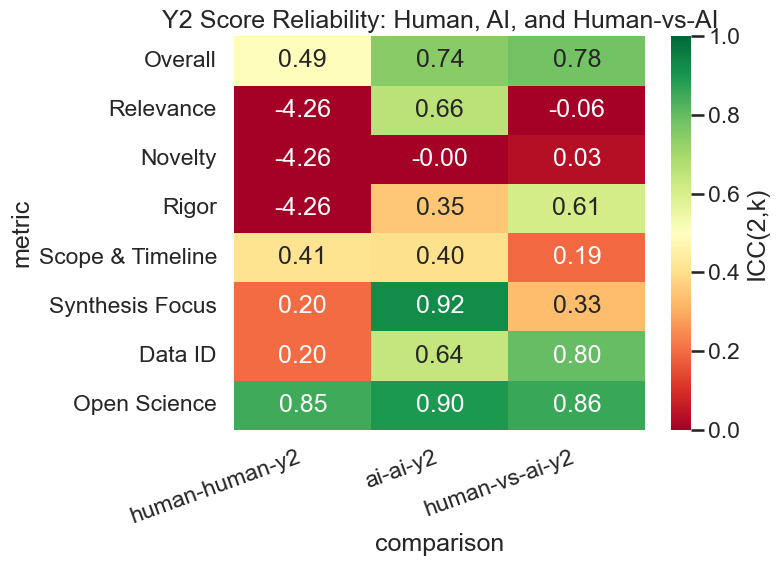

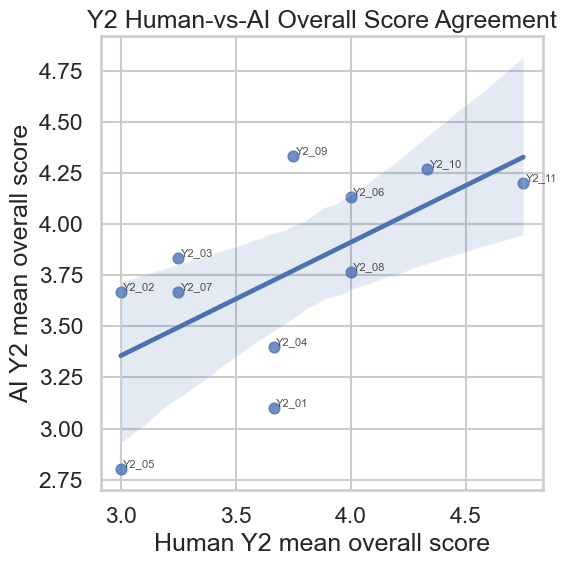

In [15]:
# Reliability analysis for Y2 proposal scores.
# Uses ICC(2,1) / ICC(2,k) and rank correlations.

quality_metrics = ['overall_score'] + CRITERIA_ORDER

# Build Y2 score tables aligned by mapped proposal keys.
h2_aligned = cohort_y2['human_aligned'].copy()
a2_aligned = cohort_y2['ai_aligned'].copy()

# Helper: ICC from complete matrix for selected columns.
def _icc_from_matrix(df_matrix):
    m = df_matrix.dropna(axis=0, how='any')
    if m.shape[0] < 2 or m.shape[1] < 2:
        return np.nan, np.nan, 0
    icc21, icc2k = icc2_1_2k(m.values)
    return icc21, icc2k, int(m.shape[0])


def _mean_pairwise_spearman(df_matrix):
    cols = list(df_matrix.columns)
    vals = []
    for c1, c2 in combinations(cols, 2):
        sub = df_matrix[[c1, c2]].dropna()
        if len(sub) < 3:
            continue
        r, _ = spearmanr(sub[c1], sub[c2])
        vals.append(r)
    if not vals:
        return np.nan
    return float(np.nanmean(vals))


irr_rows = []

for metric in quality_metrics:
    # Human-human (Y2): use shared reviewers by evaluator ID.
    mh = h2_aligned.pivot_table(index='proposal_key', columns='evaluator', values=metric, aggfunc='mean')
    icc21_h, icc2k_h, n_h = _icc_from_matrix(mh)
    rho_h = _mean_pairwise_spearman(mh)
    irr_rows.append({
        'comparison': 'human-human-y2',
        'metric': metric,
        'n_items_complete': n_h,
        'icc2_1': icc21_h,
        'icc2_k': icc2k_h,
        'mean_pairwise_spearman': rho_h,
    })

    # AI-AI (Y2)
    ma = a2_aligned.pivot_table(index='proposal_key', columns='evaluator', values=metric, aggfunc='mean')
    icc21_a, icc2k_a, n_a = _icc_from_matrix(ma)
    rho_a = _mean_pairwise_spearman(ma)
    irr_rows.append({
        'comparison': 'ai-ai-y2',
        'metric': metric,
        'n_items_complete': n_a,
        'icc2_1': icc21_a,
        'icc2_k': icc2k_a,
        'mean_pairwise_spearman': rho_a,
    })

    # Human-vs-AI (Y2): compare proposal-level means on mapped proposals.
    h_mean = h2_aligned.groupby('proposal_key')[metric].mean().rename('human_mean')
    a_mean = a2_aligned.groupby('proposal_key')[metric].mean().rename('ai_mean')
    hm = h_mean.to_frame().merge(a_mean.to_frame(), left_index=True, right_index=True, how='inner').dropna()

    if len(hm) >= 3:
        rho_ha, p_ha = spearmanr(hm['human_mean'], hm['ai_mean'])
    else:
        rho_ha, p_ha = np.nan, np.nan

    # Treat [human_mean, ai_mean] as a 2-rater matrix across items.
    icc21_ha, icc2k_ha = (np.nan, np.nan)
    if len(hm) >= 2:
        icc21_ha, icc2k_ha = icc2_1_2k(hm[['human_mean', 'ai_mean']].values)

    irr_rows.append({
        'comparison': 'human-vs-ai-y2',
        'metric': metric,
        'n_items_complete': int(len(hm)),
        'icc2_1': icc21_ha,
        'icc2_k': icc2k_ha,
        'mean_pairwise_spearman': rho_ha,
        'spearman_p_value': p_ha,
    })


y2_reliability_df = pd.DataFrame(irr_rows)
print('Y2 reliability summary:')
display(y2_reliability_df)

# Visualization 1: ICC(2,k) heatmap by metric and comparison.
metric_labels_rel = {
    'overall_score': 'Overall',
    'Relevance_to_Emergent_Phenomena': 'Relevance',
    'Novelty_and_Significance': 'Novelty',
    'Rigor_of_Approach': 'Rigor',
    'Scope_and_Timeline': 'Scope & Timeline',
    'Synthesis_Focus': 'Synthesis Focus',
    'Data_Identification': 'Data ID',
    'Open_Science_Commitment': 'Open Science',
}

rel_order = ['overall_score'] + CRITERIA_ORDER
cmp_order = ['human-human-y2', 'ai-ai-y2', 'human-vs-ai-y2']

heat = (
    y2_reliability_df.pivot(index='metric', columns='comparison', values='icc2_k')
    .reindex(index=rel_order, columns=cmp_order)
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    heat,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'ICC(2,k)'}
)
plt.yticks(
    ticks=np.arange(len(rel_order)) + 0.5,
    labels=[metric_labels_rel.get(m, m) for m in rel_order],
    rotation=0
)
plt.xticks(rotation=20, ha='right')
plt.title('Y2 Score Reliability: Human, AI, and Human-vs-AI')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_review_reliability_y2_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

# Visualization 2: Overall-score human-vs-AI agreement scatter.
overall_h = h2_aligned.groupby('proposal_key')['overall_score'].mean().rename('human_mean')
overall_a = a2_aligned.groupby('proposal_key')['overall_score'].mean().rename('ai_mean')
overall_join = overall_h.to_frame().merge(overall_a.to_frame(), left_index=True, right_index=True, how='inner').dropna()

plt.figure(figsize=(6, 6))
sns.regplot(data=overall_join, x='human_mean', y='ai_mean', scatter_kws={'s': 60, 'alpha': 0.8})
for k, r in overall_join.iterrows():
    plt.text(r['human_mean'] + 0.01, r['ai_mean'] + 0.01, k, fontsize=8, alpha=0.8)
plt.xlabel('Human Y2 mean overall score')
plt.ylabel('AI Y2 mean overall score')
plt.title('Y2 Human-vs-AI Overall Score Agreement')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_review_reliability_y2_human_vs_ai_scatter.png', dpi=200, bbox_inches='tight')
plt.show()


## 8g) R1 exports (diversity + similarity + reliability)

In [16]:
# Export R1 similarity/diversity/reliability artifacts.

cohort_y1['mapping'].to_csv(TABLES_DIR / 'quality_matching_map_y1_rephrased_reviews.csv', index=False)
cohort_y2['mapping'].to_csv(TABLES_DIR / 'quality_matching_map_y2_rephrased_reviews.csv', index=False)
cohort_y1['pair_df'].to_csv(TABLES_DIR / 'quality_similarity_pairs_y1_rephrased_reviews.csv', index=False)
cohort_y2['pair_df'].to_csv(TABLES_DIR / 'quality_similarity_pairs_y2_rephrased_reviews.csv', index=False)

sim_4group.to_csv(TABLES_DIR / 'quality_review_similarity_y1y2_four_groups_values.csv', index=False)
similarity_pairwise_tests_4group_df.to_csv(TABLES_DIR / 'quality_review_similarity_y1y2_four_group_tests.csv', index=False)
similarity_within_cohort_tests_df.to_csv(TABLES_DIR / 'quality_review_similarity_within_cohort_paired_tests.csv', index=False)

y2_reliability_df[y2_reliability_df['comparison'] == 'human-human-y2'].to_csv(
    TABLES_DIR / 'quality_review_reliability_y2_human.csv', index=False
)
y2_reliability_df[y2_reliability_df['comparison'] == 'ai-ai-y2'].to_csv(
    TABLES_DIR / 'quality_review_reliability_y2_ai.csv', index=False
)
y2_reliability_df[y2_reliability_df['comparison'] == 'human-vs-ai-y2'].to_csv(
    TABLES_DIR / 'quality_review_reliability_y2_human_vs_ai.csv', index=False
)
y2_reliability_df.to_csv(TABLES_DIR / 'quality_y2_reliability_human_ai.csv', index=False)

review_diversity_y1_wide_df.to_csv(TABLES_DIR / 'quality_review_diversity_y1_proposal_level.csv', index=False)
review_diversity_y2_wide_df.to_csv(TABLES_DIR / 'quality_review_diversity_y2_proposal_level.csv', index=False)
review_diversity_y1_long_df.to_csv(TABLES_DIR / 'quality_review_diversity_y1_long.csv', index=False)
review_diversity_y2_long_df.to_csv(TABLES_DIR / 'quality_review_diversity_y2_long.csv', index=False)
review_diversity_within_cohort_human_vs_ai_df.to_csv(
    TABLES_DIR / 'quality_review_diversity_within_cohort_human_vs_ai_tests.csv', index=False
)
review_diversity_human_vs_ai_by_model_df.to_csv(
    TABLES_DIR / 'quality_review_diversity_human_vs_ai_by_model.csv', index=False
)

print('Saved R1 figures:')
for name in [
    'quality_review_similarity_y1y2_four_groups.png',
    'quality_review_diversity_y1_paired_slopes.png',
    'quality_review_diversity_y2_paired_slopes.png',
    'quality_review_diversity_by_model.png',
    'quality_review_diversity_effects_dotplot.png',
    'quality_review_reliability_y2_heatmap.png',
    'quality_review_reliability_y2_human_vs_ai_scatter.png',
]:
    print('-', FIGURES_DIR / name)

print('Saved R1 tables:')
for name in [
    'quality_matching_map_y1_rephrased_reviews.csv',
    'quality_matching_map_y2_rephrased_reviews.csv',
    'quality_similarity_pairs_y1_rephrased_reviews.csv',
    'quality_similarity_pairs_y2_rephrased_reviews.csv',
    'quality_review_similarity_y1y2_four_groups_values.csv',
    'quality_review_similarity_y1y2_four_group_tests.csv',
    'quality_review_similarity_within_cohort_paired_tests.csv',
    'quality_review_reliability_y2_human.csv',
    'quality_review_reliability_y2_ai.csv',
    'quality_review_reliability_y2_human_vs_ai.csv',
    'quality_review_diversity_y1_proposal_level.csv',
    'quality_review_diversity_y2_proposal_level.csv',
    'quality_review_diversity_y1_long.csv',
    'quality_review_diversity_y2_long.csv',
    'quality_review_diversity_within_cohort_human_vs_ai_tests.csv',
    'quality_review_diversity_human_vs_ai_by_model.csv',
    'quality_y2_reliability_human_ai.csv',
]:
    print('-', TABLES_DIR / name)


Saved R1 figures:
- /Users/eveyhuang/Documents/NICO/human-AI-proposal-comparison/results/figures/quality/minimal/ncems_criteria/quality_review_similarity_y1y2_four_groups.png
- /Users/eveyhuang/Documents/NICO/human-AI-proposal-comparison/results/figures/quality/minimal/ncems_criteria/quality_review_diversity_y1_paired_slopes.png
- /Users/eveyhuang/Documents/NICO/human-AI-proposal-comparison/results/figures/quality/minimal/ncems_criteria/quality_review_diversity_y2_paired_slopes.png
- /Users/eveyhuang/Documents/NICO/human-AI-proposal-comparison/results/figures/quality/minimal/ncems_criteria/quality_review_diversity_by_model.png
- /Users/eveyhuang/Documents/NICO/human-AI-proposal-comparison/results/figures/quality/minimal/ncems_criteria/quality_review_diversity_effects_dotplot.png
- /Users/eveyhuang/Documents/NICO/human-AI-proposal-comparison/results/figures/quality/minimal/ncems_criteria/quality_review_reliability_y2_heatmap.png
- /Users/eveyhuang/Documents/NICO/human-AI-proposal-compar

# R2: How are AI proposals' quality compare to humans (evaluated by AI)

## 10) Proposal-quality analysis dataset (proposal-level means, no duplicated human-all rows)

**Purpose**
Create the main proposal-level scoring dataset for quality comparisons.

**How this is done**
- Average scores across evaluators within each proposal.
- Keep true base groups (`human-y1`, `human-y2`, and each AI author model).
- Construct `human-all` only analytically (not by duplicating rows in source data).

**Why this method is appropriate**
- Proposal-level summaries align with the research question: proposal quality, not individual review idiosyncrasy.
- Avoiding duplicated rows prevents biased evaluator-level analyses and inflated sample counts.


In [17]:
# Purpose:
# Build proposal-level quality dataset and summary stats without contaminating source
# data via duplicated synthetic groups.

QUALITY_METRICS = ['overall_score'] + CRITERIA_ORDER

proposal_scores = (
    ai_df.groupby(['author', 'proposal_id', 'proposal_uid'])[QUALITY_METRICS]
    .mean()
    .reset_index()
)

base_groups = ['human-y1', 'human-y2', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']
proposal_scores = proposal_scores[proposal_scores['author'].isin(base_groups)].copy()


def get_group_values(df_, group_name, metric):
    if group_name == 'human-all':
        return df_[df_['author'].isin(['human-y1', 'human-y2'])][metric].dropna().values
    return df_[df_['author'] == group_name][metric].dropna().values


keep_groups = ['human-y1', 'human-y2', 'human-all', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

summary_rows = []
for g in keep_groups:
    vals = proposal_scores[proposal_scores['author'].isin(['human-y1', 'human-y2'])]['overall_score'] if g == 'human-all' else proposal_scores[proposal_scores['author'] == g]['overall_score']
    summary_rows.append({
        'group': g,
        'n_proposals': int(vals.notna().sum()),
        'overall_mean': float(vals.mean()),
        'overall_median': float(vals.median()),
        'overall_std': float(vals.std()),
    })

summary_overall_df = pd.DataFrame(summary_rows)
summary_overall_df


,group,n_proposals,overall_mean,overall_median,overall_std
0,human-y1,12,3.441667,3.433333,0.405549
1,human-y2,11,3.742424,3.766667,0.492407
2,human-all,23,3.585507,3.666667,0.464804
3,claude-opus-4-5,23,4.008696,4.033333,0.134547
4,gemini-3-pro-preview,23,3.831884,3.833333,0.069252
5,gpt-5.2,23,4.317391,4.333333,0.054928


### Interpretation: Proposal-Level Summary Dataset

- Check `n_proposals` per group first; unequal group sizes affect power.
- `overall_mean`/`median` provide central tendency; `overall_std` indicates heterogeneity.
- Use this table to contextualize later pairwise tests (e.g., large variance can weaken significance despite mean gaps).


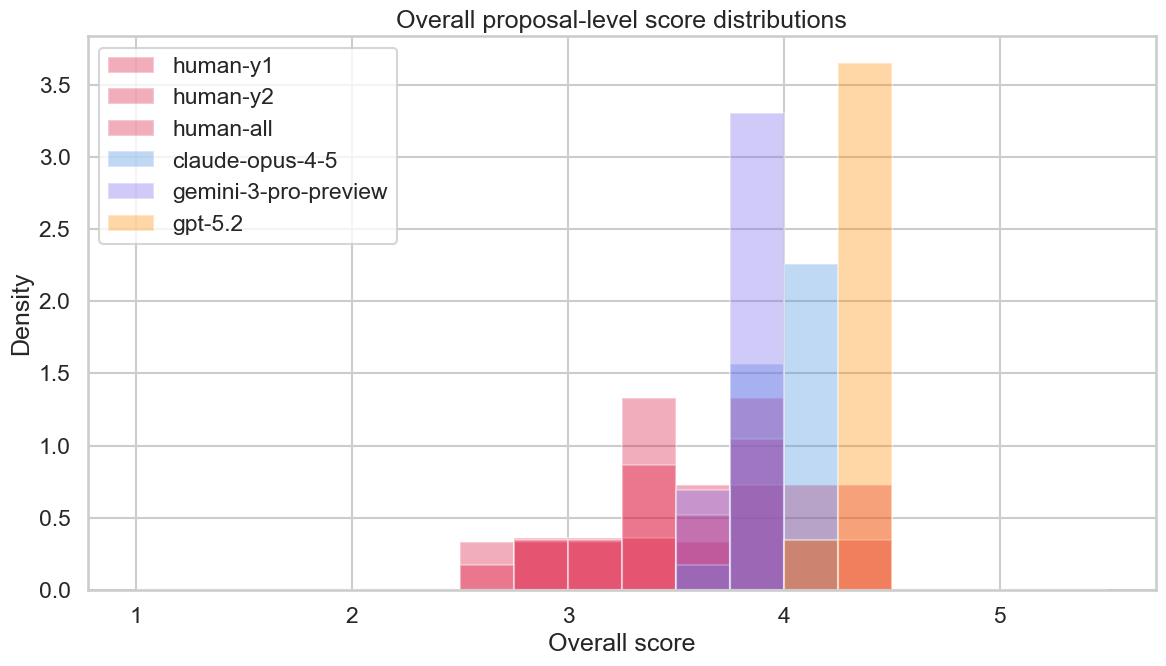

/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_89257/606590850.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='author_group', y='overall_score', order=keep_groups, palette=palette)


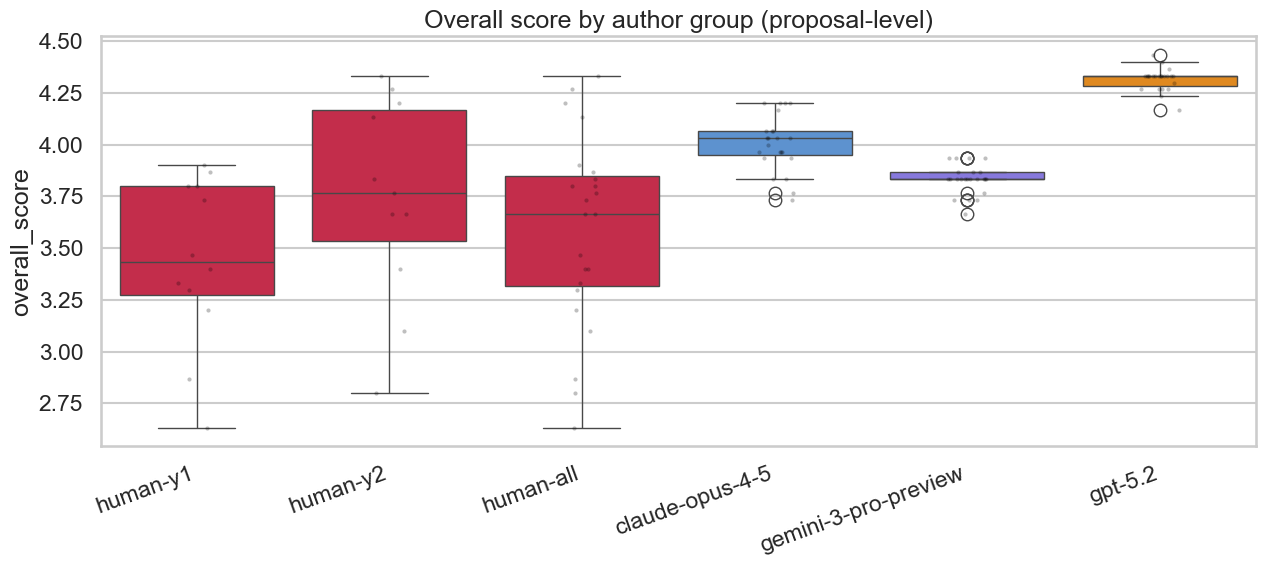

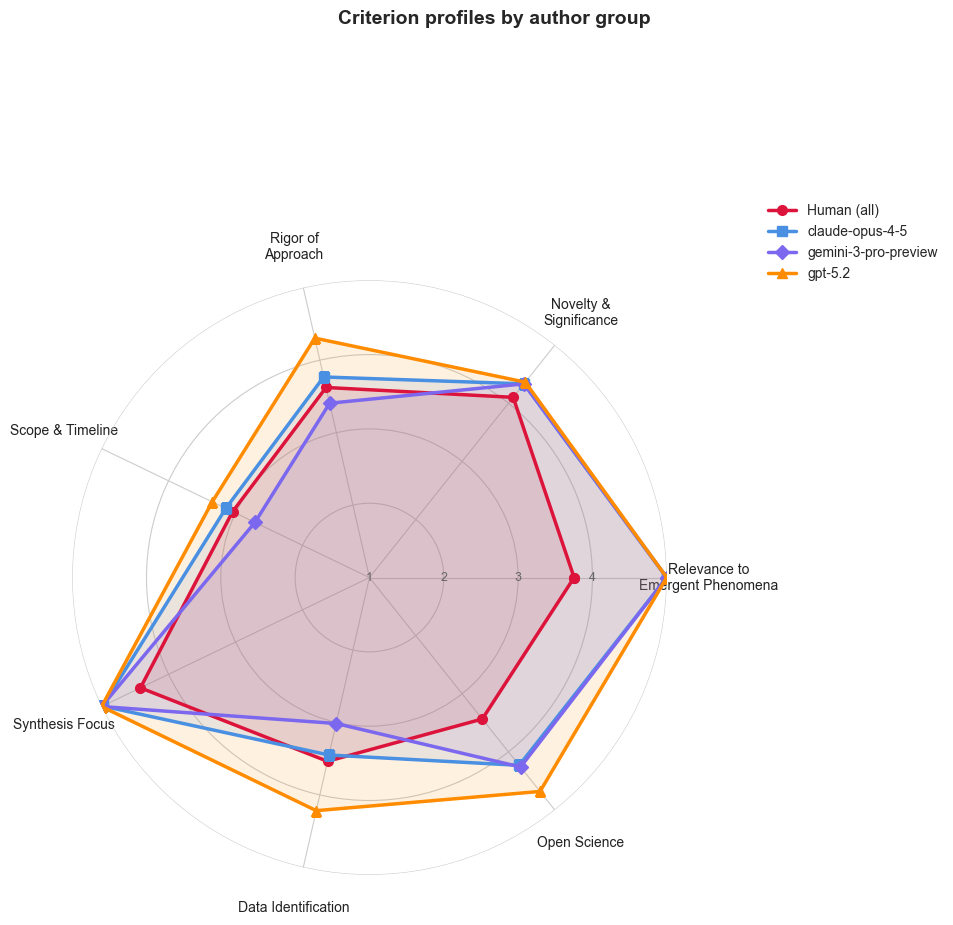

In [18]:
# Purpose:
# Visual diagnostics for quality distributions and criterion profiles.
#
# Note:
# 'human-all' is generated only for comparative plotting convenience.

plot_frames = []
for g in keep_groups:
    if g == 'human-all':
        tmp = proposal_scores[proposal_scores['author'].isin(['human-y1', 'human-y2'])].copy()
    else:
        tmp = proposal_scores[proposal_scores['author'] == g].copy()
    tmp['author_group'] = g
    plot_frames.append(tmp)
plot_df = pd.concat(plot_frames, ignore_index=True)

plt.figure(figsize=(12, 7))
for g in keep_groups:
    s = plot_df.loc[plot_df['author_group'] == g, 'overall_score'].dropna()
    if len(s) == 0:
        continue
    color = colors['Human'] if 'human' in g else colors.get(g, '#999999')
    plt.hist(s, bins=np.arange(1, 5.6, 0.25), alpha=0.35, label=g, color=color, density=True)
plt.xlabel('Overall score')
plt.ylabel('Density')
plt.title('Overall proposal-level score distributions')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_overall_histograms_proposal_level.png', dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(13, 6))
palette = {g: (colors['Human'] if 'human' in g else colors.get(g, '#999999')) for g in keep_groups}
sns.boxplot(data=plot_df, x='author_group', y='overall_score', order=keep_groups, palette=palette)
sns.stripplot(data=plot_df, x='author_group', y='overall_score', order=keep_groups, color='black', alpha=0.25, size=3)
plt.xticks(rotation=20, ha='right')
plt.title('Overall score by author group (proposal-level)')
plt.xlabel('')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_overall_boxplot_proposal_level.png', dpi=200, bbox_inches='tight')
plt.show()

radar_groups = ['human-all', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

# Short display labels matching the reference style
radar_labels = {
    'Relevance_to_Emergent_Phenomena': 'Relevance to\nEmergent Phenomena',
    'Novelty_and_Significance':        'Novelty &\nSignificance',
    'Rigor_of_Approach':               'Rigor of\nApproach',
    'Scope_and_Timeline':              'Scope & Timeline',
    'Synthesis_Focus':                 'Synthesis Focus',
    'Data_Identification':             'Data Identification',
    'Open_Science_Commitment':         'Open Science',
}

# Marker styles per group
radar_markers = {
    'human-all':           'o',
    'claude-opus-4-5':     's',
    'gemini-3-pro-preview':'D',
    'gpt-5.2':             '^',
}

radar_legend_names = {
    'human-all':           'Human (all)',
    'claude-opus-4-5':     'claude-opus-4-5',
    'gemini-3-pro-preview':'gemini-3-pro-preview',
    'gpt-5.2':             'gpt-5.2',
}

N = len(CRITERIA_ORDER)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(10, 10), facecolor='white')
ax = fig.add_subplot(111, polar=True, facecolor='white')

# Light gray gridlines only, no outer spine
ax.set_ylim(1, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels([])
ax.yaxis.grid(True, color='#cccccc', linewidth=0.8, linestyle='-')
ax.xaxis.grid(True, color='#cccccc', linewidth=0.8, linestyle='-')
ax.spines['polar'].set_visible(False)

# Scale numbers 1-4 along the first spoke (rightward horizontal)
for tick_val in [1, 2, 3, 4]:
    ax.text(angles[0], tick_val, str(tick_val),
            ha='center', va='center', fontsize=9, color='#666666')

# Plot each group
for g in radar_groups:
    vals = [np.nanmean(get_group_values(proposal_scores, g, c)) for c in CRITERIA_ORDER]
    vals += vals[:1]
    color = colors['Human'] if 'human' in g else colors.get(g, '#999999')
    marker = radar_markers.get(g, 'o')
    ax.plot(angles, vals, linewidth=2.5, color=color,
            marker=marker, markersize=7, markerfacecolor=color,
            label=radar_legend_names.get(g, g))
    ax.fill(angles, vals, alpha=0.12, color=color)

# Axis spoke labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(
    [radar_labels.get(c, c) for c in CRITERIA_ORDER],
    fontsize=10, color='#222222'
)
ax.tick_params(pad=14)

# Legend outside the chart
ax.legend(loc='upper left', bbox_to_anchor=(1.15, 1.15), frameon=False, fontsize=10)

fig.suptitle('Criterion profiles by author group', fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_radar_criteria_proposal_level.png', dpi=200, bbox_inches='tight')
plt.show()


### Interpretation: Quality Distribution Plots

- Histogram/boxplot: inspect central location, spread, and skew across groups.
- Radar chart: identify criteria where human vs AI profiles diverge most.
- Prefer combining visual patterns with statistical tables from Sections 11-12 before drawing conclusions.


## 11) Pairwise quality tests (MW + Cliff's delta + FDR) on proposal-level means

**Purpose**
Identify where quality differences exist between proposal source groups (human cohorts vs AI models), overall and by criterion.

**How this is done**
- Run all pairwise group comparisons for each metric.
- Report Mann-Whitney U, p-value, Cliff's delta, and group means.
- Apply FDR correction within each metric.

**Why this method is appropriate**
- Non-parametric tests are suitable for small and potentially skewed distributions.
- Effect sizes (Cliff's delta) provide magnitude and direction beyond p-values.


In [19]:
# Purpose:
# Pairwise group comparisons for each quality metric, with FDR control.
#
# Two separate comparisons:
#   1. human-y1 vs human-y2  — are the two human cohorts different?
#      Uses base_groups combinations (no human-all, avoids subset/superset overlap).
#   2. human-all vs each AI group — human-vs-AI contrast at full power (n≈23 vs n≈12).
#      human-all is independent of the AI groups, so Mann-Whitney is valid here.

ai_groups = ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

# --- 1) Human cohort comparison: y1 vs y2 ---
cohort_results = []
for metric in QUALITY_METRICS:
    s1 = get_group_values(proposal_scores, 'human-y1', metric)
    s2 = get_group_values(proposal_scores, 'human-y2', metric)
    out = mannwhitney_summary(s1, s2, metric_name=metric)
    out['group1'] = 'human-y1'
    out['group2'] = 'human-y2'
    out['mean_group1'] = np.mean(s1) if len(s1) else np.nan
    out['mean_group2'] = np.mean(s2) if len(s2) else np.nan
    cohort_results.append(out)

human_cohort_df = pd.DataFrame(cohort_results)
human_cohort_df = add_bh_fdr(human_cohort_df, p_col='p_value', group_cols=['metric'])

# --- 2) Human-all vs each AI group ---
vs_ai_results = []
for metric in QUALITY_METRICS:
    s_human = get_group_values(proposal_scores, 'human-all', metric)
    for g in ai_groups:
        s_ai = get_group_values(proposal_scores, g, metric)
        out = mannwhitney_summary(s_human, s_ai, metric_name=metric)
        out['group1'] = 'human-all'
        out['group2'] = g
        out['mean_group1'] = np.mean(s_human) if len(s_human) else np.nan
        out['mean_group2'] = np.mean(s_ai) if len(s_ai) else np.nan
        vs_ai_results.append(out)

vs_ai_df = pd.DataFrame(vs_ai_results)
vs_ai_df = add_bh_fdr(vs_ai_df, p_col='p_value', group_cols=['metric'])

# Also keep a full pairwise table (base_groups only, for AI-vs-AI and other pairs)
pairwise_results = []
for metric in QUALITY_METRICS:
    for g1, g2 in itertools.combinations(base_groups, 2):
        s1 = get_group_values(proposal_scores, g1, metric)
        s2 = get_group_values(proposal_scores, g2, metric)
        out = mannwhitney_summary(s1, s2, metric_name=metric)
        out['group1'] = g1
        out['group2'] = g2
        out['mean_group1'] = np.mean(s1) if len(s1) else np.nan
        out['mean_group2'] = np.mean(s2) if len(s2) else np.nan
        pairwise_results.append(out)

pairwise_df = pd.DataFrame(pairwise_results)
pairwise_df = add_bh_fdr(pairwise_df, p_col='p_value', group_cols=['metric'])

print('1) Human cohort comparison (y1 vs y2):')
display(human_cohort_df.sort_values(['metric', 'q_value']))
print('2) Human-all vs each AI group:')
display(vs_ai_df.sort_values(['metric', 'q_value', 'p_value']))


1) Human cohort comparison (y1 vs y2):


,metric,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,group1,group2,mean_group1,mean_group2,q_value
6,Data_Identification,12,11,15.0,0.001595,-0.772727,large,human-y1,human-y2,3.166667,3.939394,0.001595
2,Novelty_and_Significance,12,11,43.5,0.136998,-0.340909,medium,human-y1,human-y2,4.000000,4.212121,0.136998
7,Open_Science_Commitment,12,11,48.5,0.289885,-0.265152,small,human-y1,human-y2,3.222222,3.666667,0.289885
1,Relevance_to_Emergent_Phenomena,12,11,54.5,0.490476,-0.174242,small,human-y1,human-y2,3.527778,4.000000,0.490476
3,Rigor_of_Approach,12,11,36.5,0.053057,-0.446970,medium,human-y1,human-y2,3.472222,3.787879,0.053057
4,Scope_and_Timeline,12,11,49.5,0.302356,-0.250000,small,human-y1,human-y2,2.972222,3.121212,0.302356
5,Synthesis_Focus,12,11,62.5,0.846327,-0.053030,negligible,human-y1,human-y2,4.527778,4.303030,0.846327
0,overall_score,12,11,43.5,0.175414,-0.340909,medium,human-y1,human-y2,3.441667,3.742424,0.175414


2) Human-all vs each AI group:


,metric,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,group1,group2,mean_group1,mean_group2,q_value
20,Data_Identification,23,23,74.0,1.419817e-05,-0.720227,large,human-all,gpt-5.2,3.536232,4.217391,4.259450e-05
19,Data_Identification,23,23,432.5,4.602449e-05,0.635161,large,human-all,gemini-3-pro-preview,3.536232,3.014493,6.903673e-05
18,Data_Identification,23,23,297.5,4.642804e-01,0.124764,negligible,human-all,claude-opus-4-5,3.536232,3.449275,4.642804e-01
8,Novelty_and_Significance,23,23,126.0,1.291008e-04,-0.523629,large,human-all,gpt-5.2,4.101449,4.362319,2.052668e-04
6,Novelty_and_Significance,23,23,138.0,2.052668e-04,-0.478261,large,human-all,claude-opus-4-5,4.101449,4.333333,2.052668e-04
7,Novelty_and_Significance,23,23,138.0,2.052668e-04,-0.478261,large,human-all,gemini-3-pro-preview,4.101449,4.333333,2.052668e-04
23,Open_Science_Commitment,23,23,44.0,8.996458e-08,-0.833648,large,human-all,gpt-5.2,3.434783,4.681159,2.698937e-07
22,Open_Science_Commitment,23,23,150.5,8.085786e-03,-0.431002,medium,human-all,gemini-3-pro-preview,3.434783,4.260870,1.124151e-02
21,Open_Science_Commitment,23,23,154.5,1.124151e-02,-0.415879,medium,human-all,claude-opus-4-5,3.434783,4.231884,1.124151e-02
3,Relevance_to_Emergent_Phenomena,23,23,23.0,6.898421e-09,-0.913043,large,human-all,claude-opus-4-5,3.753623,5.000000,6.898421e-09


### Interpretation: Pairwise Quality Tests

- For each metric, prioritize `q_value` (FDR-adjusted) over raw `p_value`.
- Report both **statistical evidence** (`q_value`) and **practical effect** (`cliffs_delta`, `delta_magnitude`).
- In `vs_human_all`, positive vs negative delta tells whether the comparator tends to score above or below `human-all`.


## 11b) Effect size & significance visualization


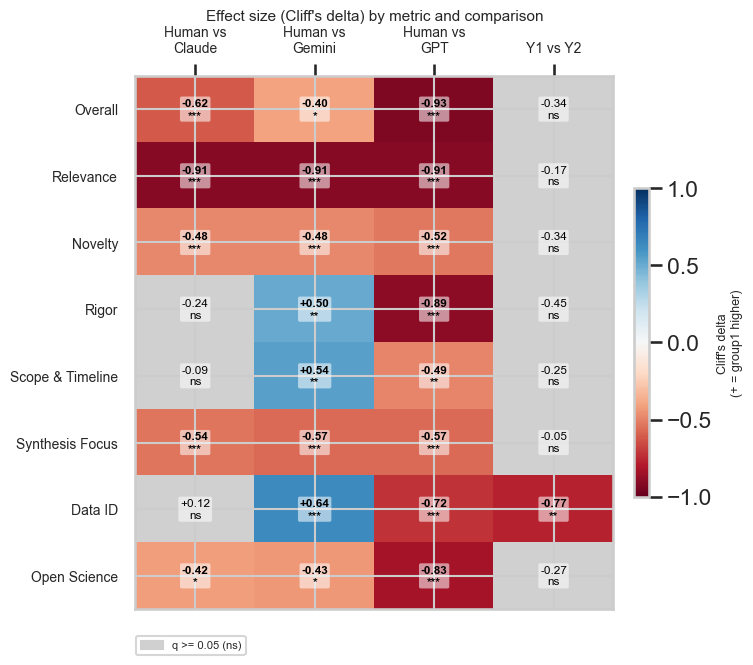

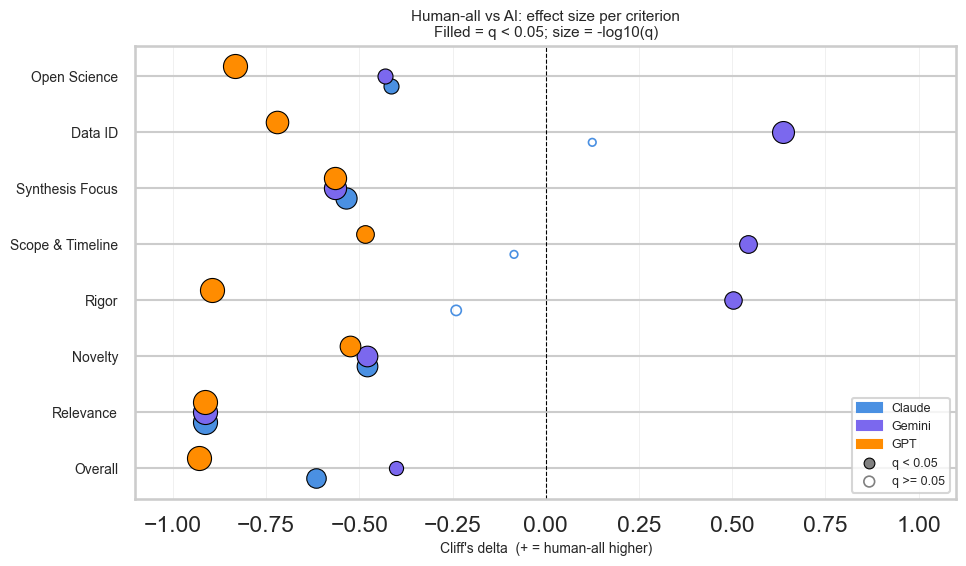

In [20]:
# Panel 1: Effect-size heatmap
#   rows = metrics, columns = comparisons
#   color = Cliff's delta; gray = not significant (q >= 0.05)
#
# Panel 2: Dot plot (human-all vs AI only)
#   x = Cliff's delta, y = metric, color = AI model
#   filled = significant (q < 0.05), hollow = not significant
#   dot size = -log10(q_value)

import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

metric_labels = {
    'overall_score':                  'Overall',
    'Relevance_to_Emergent_Phenomena': 'Relevance',
    'Novelty_and_Significance':        'Novelty',
    'Rigor_of_Approach':              'Rigor',
    'Scope_and_Timeline':             'Scope & Timeline',
    'Synthesis_Focus':                'Synthesis Focus',
    'Data_Identification':            'Data ID',
    'Open_Science_Commitment':        'Open Science',
}
row_order = ['overall_score'] + CRITERIA_ORDER

plot_stats = pd.concat([vs_ai_df, human_cohort_df], ignore_index=True)
col_order  = [
    'human-all vs claude-opus-4-5',
    'human-all vs gemini-3-pro-preview',
    'human-all vs gpt-5.2',
    'human-y1 vs human-y2',
]
plot_stats['col_label'] = plot_stats['group1'] + ' vs ' + plot_stats['group2']

delta_pivot = plot_stats.pivot(index='metric', columns='col_label', values='cliffs_delta').reindex(index=row_order, columns=col_order)
q_pivot     = plot_stats.pivot(index='metric', columns='col_label', values='q_value').reindex(index=row_order, columns=col_order)

readable_rows = [metric_labels.get(m, m) for m in row_order]
readable_cols = ['Human vs\nClaude', 'Human vs\nGemini', 'Human vs\nGPT', 'Y1 vs Y2']

# --- Panel 1: Heatmap ---
fig, ax = plt.subplots(figsize=(8, 7))

delta_arr = delta_pivot.values.astype(float)
q_arr     = q_pivot.values.astype(float)

# Single colormap pass: NaN (non-significant) renders as gray via set_bad()
cmap_hm = plt.cm.RdBu.copy()
cmap_hm.set_bad(color='#d0d0d0')
norm   = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
masked = np.where(q_arr >= 0.05, np.nan, delta_arr)

im = ax.imshow(masked, cmap=cmap_hm, norm=norm, aspect='auto', interpolation='nearest')

# Annotations with white backing box so text is always readable
for ri, metric in enumerate(row_order):
    for ci, col in enumerate(col_order):
        d = delta_arr[ri, ci]
        q = q_arr[ri, ci]
        if np.isnan(d):
            continue
        sig = '***' if q < 0.001 else ('**' if q < 0.01 else ('*' if q < 0.05 else 'ns'))
        label = f'{d:+.2f}\n{sig}'
        txt_color = 'black'
        ax.text(ci, ri, label, ha='center', va='center', fontsize=8.5,
                color=txt_color, fontweight='bold' if q < 0.05 else 'normal',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.55, edgecolor='none'))

ax.set_xticks(range(len(readable_cols)))
ax.set_xticklabels(readable_cols, fontsize=10)
ax.set_yticks(range(len(readable_rows)))
ax.set_yticklabels(readable_rows, fontsize=10)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', pad=6)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Cliff's delta\n(+ = group1 higher)", fontsize=9)

gray_patch = mpatches.Patch(color='#d0d0d0', label='q >= 0.05 (ns)')
ax.legend(handles=[gray_patch], loc='upper left', bbox_to_anchor=(-0.01, -0.04), fontsize=8)
ax.set_title("Effect size (Cliff's delta) by metric and comparison", fontsize=11, pad=40)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_effect_size_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Panel 2: Dot plot (human-all vs AI) ---
dot_df = vs_ai_df.copy()
dot_df['metric_label'] = dot_df['metric'].map(metric_labels)
ai_name_map = {'claude-opus-4-5': 'Claude', 'gemini-3-pro-preview': 'Gemini', 'gpt-5.2': 'GPT'}
dot_df['ai_label']    = dot_df['group2'].map(ai_name_map)
dot_df['significant'] = dot_df['q_value'] < 0.05
dot_df['neg_log_q']   = -np.log10(dot_df['q_value'].clip(lower=1e-10))

dot_metric_order = [metric_labels[m] for m in row_order]
dot_model_order  = ['Claude', 'Gemini', 'GPT']
dot_palette = {
    'Claude': colors.get('claude-opus-4-5', '#1f77b4'),
    'Gemini': colors.get('gemini-3-pro-preview', '#ff7f0e'),
    'GPT':    colors.get('gpt-5.2', '#2ca02c'),
}
y_pos     = {m: i for i, m in enumerate(dot_metric_order)}
x_offsets = {'Claude': -0.18, 'Gemini': 0.0, 'GPT': 0.18}

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in dot_df.iterrows():
    ml = row['metric_label']
    al = row['ai_label']
    if pd.isna(ml) or pd.isna(al):
        continue
    yp  = y_pos.get(ml, np.nan) + x_offsets.get(al, 0)
    xp  = row['cliffs_delta']
    sz  = max(30, min(300, row['neg_log_q'] * 60))
    col = dot_palette.get(al, '#999999')
    if row['significant']:
        ax.scatter(xp, yp, s=sz, color=col, edgecolors='black', linewidths=0.8, zorder=3)
    else:
        ax.scatter(xp, yp, s=sz, facecolors='none', edgecolors=col, linewidths=1.2, zorder=3)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(range(len(dot_metric_order)))
ax.set_yticklabels(dot_metric_order, fontsize=10)
ax.set_xlabel("Cliff's delta  (+ = human-all higher)", fontsize=10)
ax.set_xlim(-1.1, 1.1)
ax.set_title("Human-all vs AI: effect size per criterion\nFilled = q < 0.05; size = -log10(q)", fontsize=11)
ax.grid(axis='x', linewidth=0.4, alpha=0.5)

legend_handles = [
    mpatches.Patch(color=dot_palette[m], label=m) for m in dot_model_order
] + [
    plt.scatter([], [], s=60, color='gray', edgecolors='black', linewidths=0.8, label='q < 0.05'),
    plt.scatter([], [], s=60, facecolors='none', edgecolors='gray', linewidths=1.2, label='q >= 0.05'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_effect_size_dotplot.png', dpi=200, bbox_inches='tight')
plt.show()


## 12) Non-parametric sensitivity check (OPTIONAL)

### Robust inference for key comparisons (bootstrap CI + permutation p)

**Purpose**
Stress-test key human-vs-AI conclusions with distribution-free inference.

**How this is done**
- Bootstrap confidence intervals for mean differences. Resamples the data 2,000 times to estimate a 95% confidence interval around the mean difference in scores. If the CI excludes 0, the difference is practically meaningful.
- Permutation tests for mean-difference significance. Randomly shuffles group labels 5,000 times to build a null distribution of mean differences, then checks how extreme the observed difference is. Produces a p-value without any distributional assumptions.
- FDR correction across permutation p-values.

**Why this method is appropriate**
- Bootstrap CIs quantify uncertainty without strict normality assumptions.
- Permutation tests provide valid small-sample inference under exchangeability.


In [21]:
# Purpose:
# Robustness checks for key human-vs-AI contrasts using bootstrap CIs and
# permutation p-values.

robust_rows = []
for metric in QUALITY_METRICS:
    x = get_group_values(proposal_scores, 'human-all', metric)
    for g in ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']:
        y = get_group_values(proposal_scores, g, metric)
        mean_diff, ci_lo, ci_hi = bootstrap_mean_diff_ci(x, y, n_boot=2000, ci=0.95, seed=42)
        p_perm = permutation_p_value_mean_diff(x, y, n_perm=5000, seed=42)
        robust_rows.append({
            'metric': metric,
            'comparison': f'human-all minus {g}',
            'n_human_all': len(x),
            'n_other': len(y),
            'mean_diff': mean_diff,
            'bootstrap_ci_lo': ci_lo,
            'bootstrap_ci_hi': ci_hi,
            'permutation_p_value': p_perm,
        })

robust_quality_df = pd.DataFrame(robust_rows)
robust_quality_df = add_bh_fdr(robust_quality_df, p_col='permutation_p_value', group_cols=['metric'], out_col='permutation_q_value')
robust_quality_df.head(20)


,metric,comparison,n_human_all,n_other,mean_diff,bootstrap_ci_lo,bootstrap_ci_hi,permutation_p_value,permutation_q_value
0,overall_score,human-all minus claude-opus-4-5,23,23,-0.423188,-0.627609,-0.231848,0.000200,0.000300
1,overall_score,human-all minus gemini-3-pro-preview,23,23,-0.246377,-0.443478,-0.063768,0.015197,0.015197
2,overall_score,human-all minus gpt-5.2,23,23,-0.731884,-0.927572,-0.552138,0.000200,0.000300
3,Relevance_to_Emergent_Phenomena,human-all minus claude-opus-4-5,23,23,-1.246377,-1.637681,-0.884058,0.000200,0.000200
4,Relevance_to_Emergent_Phenomena,human-all minus gemini-3-pro-preview,23,23,-1.246377,-1.637681,-0.884058,0.000200,0.000200
5,Relevance_to_Emergent_Phenomena,human-all minus gpt-5.2,23,23,-1.246377,-1.637681,-0.884058,0.000200,0.000200
6,Novelty_and_Significance,human-all minus claude-opus-4-5,23,23,-0.231884,-0.347826,-0.115942,0.000200,0.000200
7,Novelty_and_Significance,human-all minus gemini-3-pro-preview,23,23,-0.231884,-0.347826,-0.115942,0.000200,0.000200
8,Novelty_and_Significance,human-all minus gpt-5.2,23,23,-0.260870,-0.391304,-0.144928,0.000200,0.000200
9,Rigor_of_Approach,human-all minus claude-opus-4-5,23,23,-0.144928,-0.347826,0.028986,0.109178,0.109178


### Interpretation: Robust Inference

- `mean_diff` sign indicates direction (`human-all minus model`).
- If bootstrap CI excludes 0 and permutation `q_value < 0.05`, conclusion is robust.
- If MW and robust tests disagree, treat finding as fragile and report as exploratory.


# R3: Is there any self-preference bias in AI evaluators?

## 13) Evaluator differences (non-duplicated data only)

**Purpose**
Assess whether evaluator models have systematic scoring differences (leniency/stringency).

**How this is done**
- Summarize per-evaluator score distributions.
- Visualize distributions.
- Use Kruskal-Wallis to test overall group differences.

**Why this method is appropriate**
Evaluator drift is a central bias risk in AI-as-judge designs; this provides an explicit diagnostic before interpretation of author-group differences.


In [22]:
# Purpose:
# Quick evaluator-level descriptive statistics on non-duplicated source data.

eval_stats = ai_df.groupby('evaluator')['overall_score'].agg(['count', 'mean', 'median', 'std']).sort_values('mean', ascending=False)
eval_stats


,count,mean,median,std
evaluator,,,,
gemini-3-pro-preview,92,4.301087,4.3,0.422316
claude-opus-4-5,92,3.783696,3.8,0.397043
gpt-5.2,92,3.722826,3.8,0.348025


### Interpretation: Evaluator Descriptives

- Use this table to detect systematic evaluator strictness/leniency before model-comparison claims.
- Large mean/median gaps across evaluators indicate potential judge bias.


/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_89257/3768538928.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ai_df, x='evaluator', y='overall_score', palette='Set2')


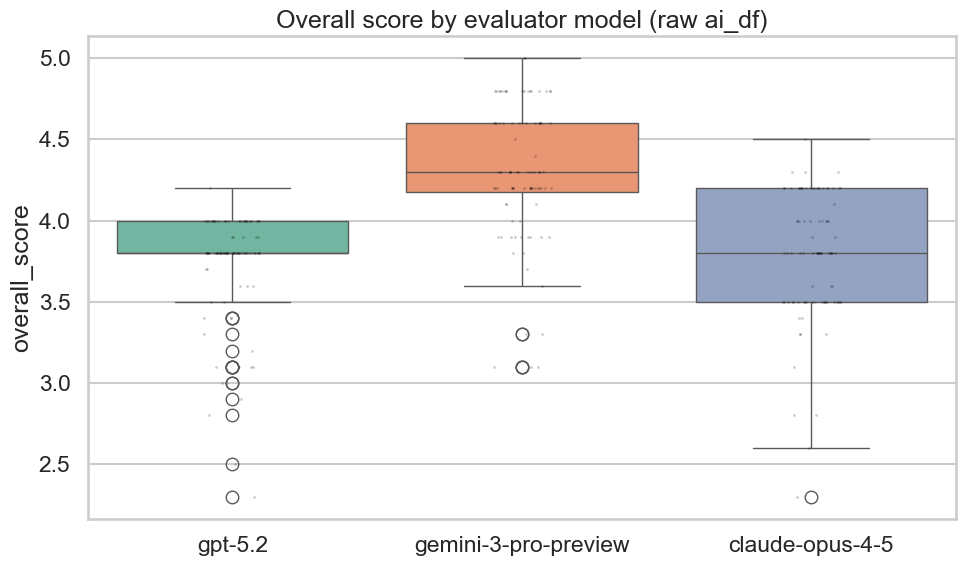

{'kruskal_stat': np.float64(98.01585311553222), 'p_value': np.float64(5.201491899055386e-22)}


In [23]:
# Purpose:
# Evaluate evaluator distribution differences visually and formally (Kruskal-Wallis).

plt.figure(figsize=(10, 6))
sns.boxplot(data=ai_df, x='evaluator', y='overall_score', palette='Set2')
sns.stripplot(data=ai_df, x='evaluator', y='overall_score', color='black', alpha=0.2, size=2)
plt.title('Overall score by evaluator model (raw ai_df)')
plt.xlabel('')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_overall_by_evaluator_clean.png', dpi=200, bbox_inches='tight')
plt.show()

parts = [ai_df.loc[ai_df['evaluator'] == e, 'overall_score'].dropna().values for e in sorted(ai_df['evaluator'].dropna().unique())]
kw_stat, kw_p = kruskal(*parts)
print({'kruskal_stat': kw_stat, 'p_value': kw_p})


### Interpretation: Evaluator Difference Test

- Kruskal-Wallis `p_value < 0.05` indicates at least one evaluator distribution differs.
- This supports modeling evaluator effects explicitly (Sections 14 and 18).


## 14) AI self-preference tests (overall + criterion-level + proposal controls)

**Purpose**
Test whether AI evaluators prefer proposals generated by their own model.

**How this is done**
1. Compare self vs non-self scores at proposal level (overall).
2. Repeat by criterion to localize bias.
3. Fit fixed-effects regression with proposal controls to isolate self-preference net of proposal difficulty.

**Why this method is appropriate**
Self-preference is a known LLM evaluator bias; combining non-parametric and controlled regression analyses strengthens causal interpretability.


In [24]:
# Purpose:
# Overall self-preference test by evaluator model at proposal level.

ai_authors = ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

sp = ai_df[ai_df['author'].isin(ai_authors) & ai_df['evaluator'].isin(ai_authors)].copy()
sp_prop = (
    sp.groupby(['evaluator', 'author', 'proposal_id'])[QUALITY_METRICS]
    .mean()
    .reset_index()
)
sp_prop['is_self'] = sp_prop['author'] == sp_prop['evaluator']

self_pref_rows = []
for evaluator in ai_authors:
    sub = sp_prop[sp_prop['evaluator'] == evaluator]
    own = sub[sub['is_self']]['overall_score'].dropna()
    other = sub[~sub['is_self']]['overall_score'].dropna()
    out = mannwhitney_summary(own, other, metric_name='overall_score')
    out['evaluator'] = evaluator
    out['mean_self'] = own.mean() if len(own) else np.nan
    out['mean_other'] = other.mean() if len(other) else np.nan
    self_pref_rows.append(out)

self_pref_df = pd.DataFrame(self_pref_rows)
self_pref_df = add_bh_fdr(self_pref_df, p_col='p_value')
self_pref_df


,metric,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,evaluator,mean_self,mean_other,q_value
0,overall_score,23,46,501.0,7.173364e-01,-0.052930,negligible,claude-opus-4-5,3.878261,3.886957,7.173364e-01
1,overall_score,23,46,142.0,5.166161e-07,-0.731569,large,gemini-3-pro-preview,4.143478,4.530435,7.749241e-07
2,overall_score,23,46,1022.5,1.100302e-12,0.932892,large,gpt-5.2,4.004348,3.806522,3.300906e-12


### Interpretation: Overall Self-Preference

- Compare `mean_self` vs `mean_other` per evaluator.
- `q_value < 0.05` with higher `mean_self` suggests self-favoring bias.
- Opposite direction suggests self-penalization or cross-model preference.


In [25]:
# Purpose:
# Criterion-level self-preference decomposition to identify where bias concentrates.

sp_long = sp_prop.melt(
    id_vars=['evaluator', 'author', 'proposal_id', 'is_self'],
    value_vars=QUALITY_METRICS,
    var_name='metric',
    value_name='score',
).dropna(subset=['score'])

rows = []
for evaluator in ai_authors:
    sube = sp_long[sp_long['evaluator'] == evaluator]
    for metric in QUALITY_METRICS:
        sm = sube[sube['metric'] == metric]
        own = sm[sm['is_self']]['score']
        other = sm[~sm['is_self']]['score']
        out = mannwhitney_summary(own, other, metric_name=metric)
        out['evaluator'] = evaluator
        out['mean_self'] = own.mean() if len(own) else np.nan
        out['mean_other'] = other.mean() if len(other) else np.nan
        rows.append(out)

self_pref_metric_df = pd.DataFrame(rows)
self_pref_metric_df = add_bh_fdr(self_pref_metric_df, p_col='p_value', group_cols=['evaluator'])
self_pref_metric_df.head(20)


,metric,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,evaluator,mean_self,mean_other,q_value
0,overall_score,23,46,501.0,7.173364e-01,-0.052930,negligible,claude-opus-4-5,3.878261,3.886957,9.564485e-01
1,Relevance_to_Emergent_Phenomena,23,46,529.0,1.000000e+00,0.000000,negligible,claude-opus-4-5,5.000000,5.000000,1.000000e+00
2,Novelty_and_Significance,23,46,506.0,3.243617e-01,-0.043478,negligible,claude-opus-4-5,4.000000,4.043478,6.415205e-01
3,Rigor_of_Approach,23,46,759.0,3.468762e-04,0.434783,medium,claude-opus-4-5,3.956522,3.521739,1.387505e-03
4,Scope_and_Timeline,23,46,736.0,8.521481e-04,0.391304,medium,claude-opus-4-5,3.000000,2.608696,2.272395e-03
5,Synthesis_Focus,23,46,529.0,1.000000e+00,0.000000,negligible,claude-opus-4-5,5.000000,5.000000,1.000000e+00
6,Data_Identification,23,46,471.5,4.009503e-01,-0.108696,negligible,claude-opus-4-5,3.391304,3.500000,6.415205e-01
7,Open_Science_Commitment,23,46,264.5,3.866569e-05,-0.500000,large,claude-opus-4-5,4.000000,4.500000,3.093255e-04
8,overall_score,23,46,142.0,5.166161e-07,-0.731569,large,gemini-3-pro-preview,4.143478,4.530435,1.377643e-06
9,Relevance_to_Emergent_Phenomena,23,46,529.0,1.000000e+00,0.000000,negligible,gemini-3-pro-preview,5.000000,5.000000,1.000000e+00


### Interpretation: Criterion-Level Self-Preference

- Identify which criteria show strongest self-preference (`q_value` + large |delta|).
- A bias concentrated in specific criteria is more actionable than uniform global bias.


## 14b) Self-preference visualization


/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_89257/808808108.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Group', y='overall_score', order=['Self', 'Other'],
/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_89257/808808108.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Group', y='overall_score', order=['Self', 'Other'],
/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_89257/808808108.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Group', y='overall_s

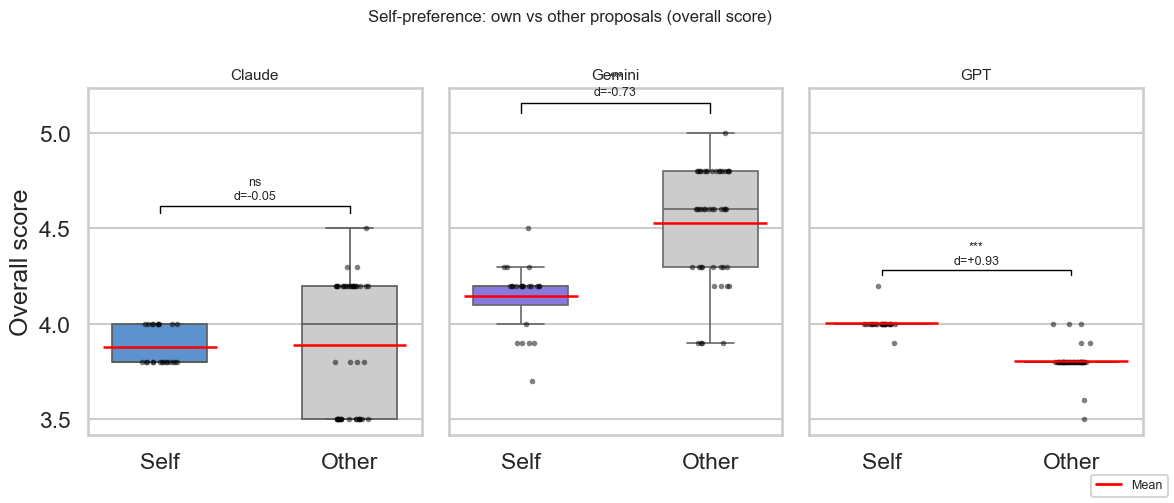

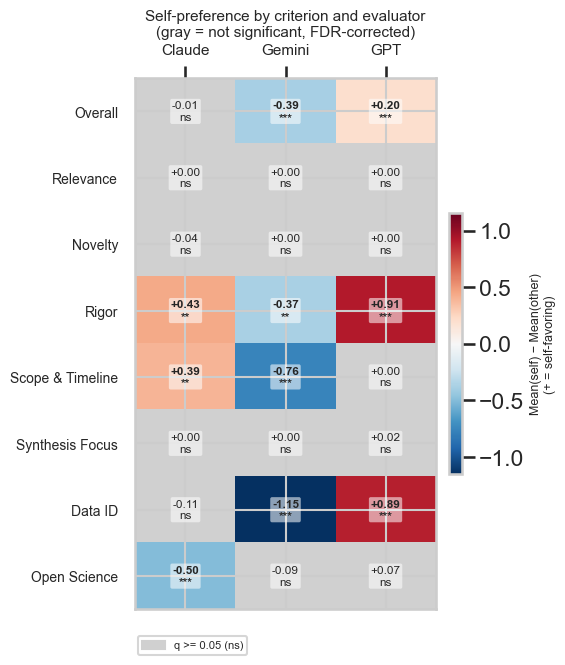

In [26]:
# Two-panel self-preference visualization:
#
# Panel 1 — Faceted strip + box plot (overall score)
#   One column per evaluator model; two groups: self vs other
#   Shows full distribution + mean, annotated with significance
#
# Panel 2 — Criterion-level delta heatmap
#   rows = criteria, columns = evaluator model
#   color = mean_self - mean_other (+ = self-favoring)
#   gray = not significant (q >= 0.05)

import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

ai_name_map = {'claude-opus-4-5': 'Claude', 'gemini-3-pro-preview': 'Gemini', 'gpt-5.2': 'GPT'}
ai_authors_ordered = ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

# --- Panel 1: Faceted strip + box plot ---
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
fig.suptitle('Self-preference: own vs other proposals (overall score)', fontsize=12)

for ax, evaluator in zip(axes, ai_authors_ordered):
    sub = sp_prop[sp_prop['evaluator'] == evaluator][['is_self', 'overall_score']].dropna()
    sub = sub.copy()
    sub['Group'] = sub['is_self'].map({True: 'Self', False: 'Other'})

    grp_color = colors.get(evaluator, '#999999')
    palette = {'Self': grp_color, 'Other': '#cccccc'}

    sns.boxplot(data=sub, x='Group', y='overall_score', order=['Self', 'Other'],
                palette=palette, width=0.5, linewidth=1.2,
                flierprops=dict(marker=''), ax=ax)
    sns.stripplot(data=sub, x='Group', y='overall_score', order=['Self', 'Other'],
                  color='black', alpha=0.5, size=4, jitter=True, ax=ax)

    # Means as horizontal lines
    for xi, grp in enumerate(['Self', 'Other']):
        m = sub[sub['Group'] == grp]['overall_score'].mean()
        ax.hlines(m, xi - 0.3, xi + 0.3, color='red', linewidth=1.8, zorder=5)

    # Significance annotation
    row = self_pref_df[self_pref_df['evaluator'] == evaluator].iloc[0]
    q   = row.get('q_value', row.get('p_value', 1.0))
    sig = '***' if q < 0.001 else ('**' if q < 0.01 else ('*' if q < 0.05 else 'ns'))
    d   = row['cliffs_delta']
    ymax = sub['overall_score'].max()
    yrange = sub['overall_score'].max() - sub['overall_score'].min()
    y_bracket = ymax + yrange * 0.08
    ax.plot([0, 0, 1, 1], [y_bracket, y_bracket + yrange*0.04,
                            y_bracket + yrange*0.04, y_bracket],
            color='black', linewidth=1)
    ax.text(0.5, y_bracket + yrange * 0.06, f'{sig}\nd={d:+.2f}',
            ha='center', va='bottom', fontsize=9)

    ax.set_title(ai_name_map[evaluator], fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Overall score' if ax == axes[0] else '')

red_line = plt.Line2D([0], [0], color='red', linewidth=2, label='Mean')
fig.legend(handles=[red_line], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'self_pref_strip_overall.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Panel 2: Criterion-level delta heatmap ---
sp_metric = self_pref_metric_df.copy()
sp_metric['delta'] = sp_metric['mean_self'] - sp_metric['mean_other']
sp_metric['evaluator_label'] = sp_metric['evaluator'].map(ai_name_map)

crit_row_order = ['overall_score'] + CRITERIA_ORDER
crit_labels = {
    'overall_score':                  'Overall',
    'Relevance_to_Emergent_Phenomena': 'Relevance',
    'Novelty_and_Significance':        'Novelty',
    'Rigor_of_Approach':              'Rigor',
    'Scope_and_Timeline':             'Scope & Timeline',
    'Synthesis_Focus':                'Synthesis Focus',
    'Data_Identification':            'Data ID',
    'Open_Science_Commitment':        'Open Science',
}
col_labels = [ai_name_map[e] for e in ai_authors_ordered]

delta_grid = sp_metric.pivot(index='metric', columns='evaluator_label', values='delta')\
                       .reindex(index=crit_row_order, columns=col_labels)
q_grid     = sp_metric.pivot(index='metric', columns='evaluator_label', values='q_value')\
                       .reindex(index=crit_row_order, columns=col_labels)

delta_arr = delta_grid.values.astype(float)
q_arr     = q_grid.values.astype(float)

abs_max = np.nanmax(np.abs(delta_arr))
cmap_sp = plt.cm.RdBu_r.copy()   # red = self-favoring (+), blue = other-favoring (-)
cmap_sp.set_bad(color='#d0d0d0')
norm_sp = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
masked  = np.where(q_arr >= 0.05, np.nan, delta_arr)

fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(masked, cmap=cmap_sp, norm=norm_sp, aspect='auto', interpolation='nearest')

readable_rows = [crit_labels.get(m, m) for m in crit_row_order]
for ri in range(len(crit_row_order)):
    for ci in range(len(col_labels)):
        d = delta_arr[ri, ci]
        q = q_arr[ri, ci]
        if np.isnan(d):
            continue
        sig = '***' if q < 0.001 else ('**' if q < 0.01 else ('*' if q < 0.05 else 'ns'))
        ax.text(ci, ri, f'{d:+.2f}\n{sig}', ha='center', va='center', fontsize=8.5,
                fontweight='bold' if q < 0.05 else 'normal',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.55, edgecolor='none'))

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=11)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', pad=6)
ax.set_yticks(range(len(readable_rows)))
ax.set_yticklabels(readable_rows, fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
cbar.set_label('Mean(self) − Mean(other)\n(+ = self-favoring)', fontsize=9)

gray_patch = mpatches.Patch(color='#d0d0d0', label='q >= 0.05 (ns)')
ax.legend(handles=[gray_patch], loc='upper left', bbox_to_anchor=(-0.01, -0.04), fontsize=8)
ax.set_title('Self-preference by criterion and evaluator\n(gray = not significant, FDR-corrected)',
             fontsize=11, pad=30)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'self_pref_criterion_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()


#### Do these models rate their own proosals better? How to remove that bias?

The three models go in opposite directions: Claude self-deprecates, GPT strongly self-inflates, Gemini is neutral. This asymmetry is substantively important — it means GPT cannot be treated as an unbiased evaluator of AI-generated proposals in this experiment.

**What the fixed-effects regression does**
The Mann-Whitney test already shows that self-preference exists, but it doesn't rule out a confound: maybe GPT's own proposals just happen to be better, and that's why GPT scores them higher — not because of bias.

The regression controls for this by including proposal fixed effects (C(proposal_uid)):
`score ~ is_self_num * C(metric) + C(evaluator) + C(author) + C(proposal_uid)`
* C(proposal_uid) — gives each proposal its own intercept, absorbing all proposal-specific quality variation. After this, is_self_num only captures the evaluator's behavior change when reviewing their own work, not proposal quality differences.
* C(evaluator) — absorbs evaluator-level severity/leniency (some models score everything higher).
* `is_self_num * C(metric)` — tests whether self-preference concentrates in specific criteria.
* HC3 — heteroscedasticity-robust standard errors, appropriate when residual variance isn't constant.

The coefficient on is_self_num from this model is the net self-preference effect after removing proposal quality as an explanation. If it's still significant here, the bias interpretation is much stronger than what Mann-Whitney alone can support.

One caveat: the model estimates a single average is_self_num effect across all three evaluators. To get model-specific net effects (like the Mann-Whitney table shows), you'd need to add is_self_num * C(evaluator) as an interaction term.


In [27]:
# Purpose:
# Fixed-effects regression to isolate self-preference net of proposal effects.

try:
    import statsmodels.formula.api as smf

    fe_df = sp_long.copy()
    fe_df['proposal_uid'] = fe_df['author'].astype(str) + '::' + fe_df['proposal_id'].astype(str)
    fe_df['is_self_num'] = fe_df['is_self'].astype(int)

    model_self = smf.ols(
        'score ~ is_self_num * C(metric) + C(evaluator) + C(author) + C(proposal_uid)',
        data=fe_df
    ).fit(cov_type='HC3')

    print(model_self.summary().tables[1])
except Exception as e:
    print('statsmodels model skipped:', e)


                                                                                                                                                                                                               coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                                                                                                                                    3.3402      0.074     45.089      0.000       3.195       3.485
C(metric)[T.Novelty_and_Significance]                                                                                                                                                            

/Users/eveyhuang/Documents/NICO/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 87, but rank is 85
  warnings.warn('covariance of constraints does not have full '


## 14c) Fixed-effects regression: forest plot


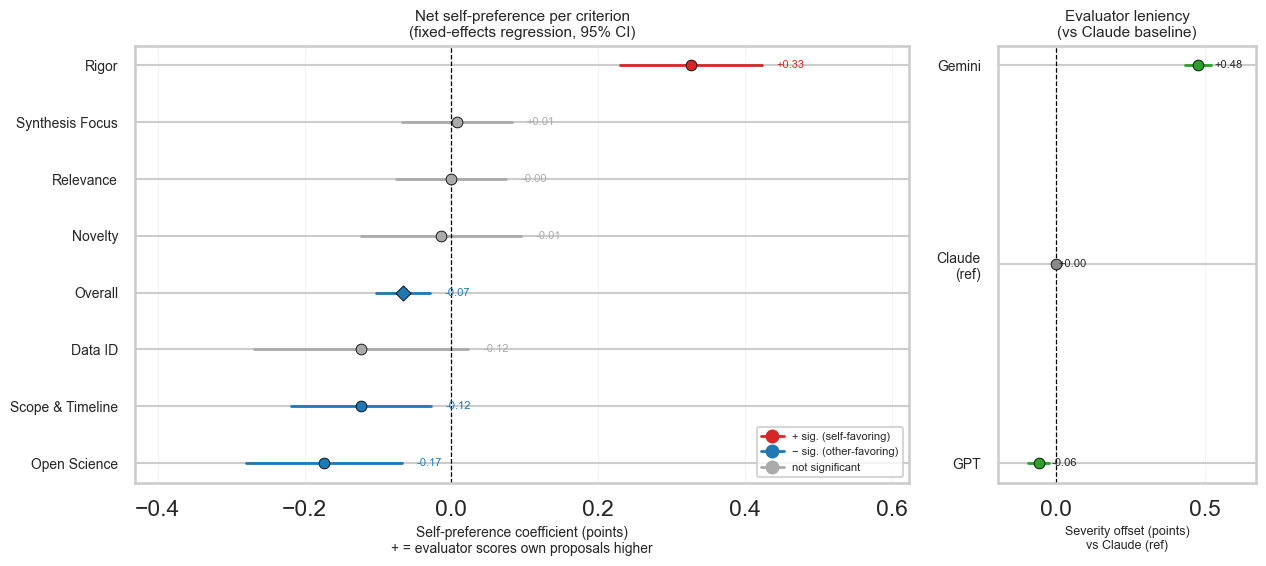

In [28]:
# Forest plot of per-criterion self-preference from the fixed-effects regression.
#
# For each criterion c, the net self-preference is:
#   beta_c = is_self_num + is_self_num:C(metric)[T.c]   (Data_ID is the reference, so beta = is_self_num)
#
# 95% CI uses the model covariance matrix so the uncertainty from both terms is combined correctly:
#   var(beta_c) = var(main) + var(interaction_c) + 2*cov(main, interaction_c)
#
# Separate small panel shows evaluator severity offsets (C(evaluator) main effects).

try:
    import scipy.stats as stats

    crit_labels_reg = {
        'Data_Identification':           'Data ID',
        'Novelty_and_Significance':      'Novelty',
        'Open_Science_Commitment':       'Open Science',
        'Relevance_to_Emergent_Phenomena': 'Relevance',
        'Rigor_of_Approach':             'Rigor',
        'Scope_and_Timeline':            'Scope & Timeline',
        'Synthesis_Focus':               'Synthesis Focus',
        'overall_score':                 'Overall',
    }

    params = model_self.params
    cov    = model_self.cov_params()
    alpha  = 0.05
    z_crit = stats.norm.ppf(1 - alpha / 2)

    main_key = 'is_self_num'
    beta_main = params[main_key]
    var_main  = cov.loc[main_key, main_key]

    # All metrics: Data_ID is reference (interaction absent), others have an interaction term
    all_metrics = ['Data_Identification'] + [
        m for m in CRITERIA_ORDER if m != 'Data_Identification'
    ] + ['overall_score']

    rows_fe = []
    for metric in all_metrics:
        int_key = f'is_self_num:C(metric)[T.{metric}]'
        if int_key in params.index:
            beta_int = params[int_key]
            var_int  = cov.loc[int_key, int_key]
            cov_mi   = cov.loc[main_key, int_key]
            beta = beta_main + beta_int
            se   = (var_main + var_int + 2 * cov_mi) ** 0.5
        else:  # Data_Identification: reference, no interaction term
            beta = beta_main
            se   = var_main ** 0.5
        ci_lo = beta - z_crit * se
        ci_hi = beta + z_crit * se
        sig   = (ci_lo > 0) or (ci_hi < 0)
        rows_fe.append({'metric': metric, 'label': crit_labels_reg[metric],
                         'beta': beta, 'se': se, 'ci_lo': ci_lo, 'ci_hi': ci_hi, 'sig': sig})

    fe_df_plot = pd.DataFrame(rows_fe).sort_values('beta', ascending=True).reset_index(drop=True)

    # Evaluator severity offsets (C(evaluator) main effects)
    ev_keys = [k for k in params.index if k.startswith('C(evaluator)')]
    ev_rows = []
    for k in ev_keys:
        name = k.split('[T.')[1].rstrip(']')
        ai_name_map = {'claude-opus-4-5': 'Claude', 'gemini-3-pro-preview': 'Gemini', 'gpt-5.2': 'GPT'}
        label = ai_name_map.get(name, name)
        b  = params[k]
        se = cov.loc[k, k] ** 0.5
        ev_rows.append({'label': label, 'beta': b,
                         'ci_lo': b - z_crit * se, 'ci_hi': b + z_crit * se})
    # Add Claude as reference (0)
    ev_rows.append({'label': 'Claude\n(ref)', 'beta': 0, 'ci_lo': 0, 'ci_hi': 0})
    ev_df_plot = pd.DataFrame(ev_rows).sort_values('beta').reset_index(drop=True)

    # --- Figure: two-panel layout ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6),
                                    gridspec_kw={'width_ratios': [3, 1]})

    # Panel 1: Per-criterion self-preference forest plot
    for yi, row in fe_df_plot.iterrows():
        col  = '#d62728' if row['sig'] and row['beta'] > 0 else \
               '#1f77b4' if row['sig'] and row['beta'] < 0 else '#aaaaaa'
        ax1.plot([row['ci_lo'], row['ci_hi']], [yi, yi], color=col, linewidth=2, zorder=2)
        marker = 'D' if row['label'] == 'Overall' else 'o'
        ax1.scatter(row['beta'], yi, color=col, s=60, zorder=3,
                    edgecolors='black', linewidths=0.6, marker=marker)
        ax1.text(row['ci_hi'] + 0.02, yi, f"{row['beta']:+.2f}",
                 va='center', fontsize=8, color=col)

    ax1.axvline(0, color='black', linewidth=0.9, linestyle='--')
    ax1.set_yticks(range(len(fe_df_plot)))
    ax1.set_yticklabels(fe_df_plot['label'], fontsize=10)
    ax1.set_xlabel("Self-preference coefficient (points)\n+ = evaluator scores own proposals higher",
                   fontsize=10)
    ax1.set_title("Net self-preference per criterion\n(fixed-effects regression, 95% CI)", fontsize=11)
    ax1.grid(axis='x', linewidth=0.4, alpha=0.4)
    ax1.set_xlim(fe_df_plot['ci_lo'].min() - 0.15, fe_df_plot['ci_hi'].max() + 0.2)

    from matplotlib.lines import Line2D
    legend_h = [
        Line2D([0],[0], color='#d62728', linewidth=2, marker='o', label='+ sig. (self-favoring)'),
        Line2D([0],[0], color='#1f77b4', linewidth=2, marker='o', label='− sig. (other-favoring)'),
        Line2D([0],[0], color='#aaaaaa', linewidth=2, marker='o', label='not significant'),
    ]
    ax1.legend(handles=legend_h, fontsize=8, loc='lower right')

    # Panel 2: Evaluator severity
    for yi, row in ev_df_plot.iterrows():
        is_ref = row['ci_lo'] == row['ci_hi']
        col = '#888888' if is_ref else '#2ca02c'
        if not is_ref:
            ax2.plot([row['ci_lo'], row['ci_hi']], [yi, yi], color=col, linewidth=2, zorder=2)
        ax2.scatter(row['beta'], yi, color=col, s=60, zorder=3,
                    edgecolors='black', linewidths=0.6)
        ax2.text(row['ci_hi'] + 0.01, yi, f"{row['beta']:+.2f}",
                 va='center', fontsize=8)

    ax2.axvline(0, color='black', linewidth=0.9, linestyle='--')
    ax2.set_yticks(range(len(ev_df_plot)))
    ax2.set_yticklabels(ev_df_plot['label'], fontsize=10)
    ax2.set_xlabel('Severity offset (points)\nvs Claude (ref)', fontsize=9)
    ax2.set_title('Evaluator leniency\n(vs Claude baseline)', fontsize=11)
    ax2.grid(axis='x', linewidth=0.4, alpha=0.4)
    ax2.set_xlim(ev_df_plot['ci_lo'].min() - 0.1, ev_df_plot['ci_hi'].max() + 0.15)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'self_pref_regression_forest.png', dpi=200, bbox_inches='tight')
    plt.show()

except NameError:
    print('model_self not available — run the regression cell first.')
except Exception as e:
    print(f'Plot failed: {e}')


## 19) Export tables

This section writes all analysis artifacts (mapping diagnostics, test tables, robustness outputs, bias/proxy/reliability results) to `results/figures/quality/` for downstream reporting and manuscript integration.


In [30]:
# Purpose:
# Persist all analysis outputs for reporting, reproducibility, and manuscript figures/tables.
mapping_df.to_csv(TABLES_DIR / 'quality_matching_map_exact_fuzzy.csv', index=False)
pair_df.to_csv(TABLES_DIR / 'quality_similarity_pairs.csv', index=False)
sim_stats_overall_df.to_csv(TABLES_DIR / 'quality_similarity_mw_cliffs_overall.csv', index=False)
sim_stats_hai_by_model_df.to_csv(TABLES_DIR / 'quality_similarity_mw_cliffs_human_ai_by_model.csv', index=False)
sim_stats_aiai_by_pair_df.to_csv(TABLES_DIR / 'quality_similarity_mw_cliffs_ai_ai_by_model_pair.csv', index=False)

summary_overall_df.to_csv(TABLES_DIR / 'quality_summary_overall_by_author_group.csv', index=False)
pairwise_df.to_csv(TABLES_DIR / 'quality_pairwise_mw_cliffs_all_metrics_proposal_level.csv', index=False)
robust_quality_df.to_csv(TABLES_DIR / 'quality_robust_bootstrap_permutation_key_comparisons.csv', index=False)

eval_stats.to_csv(TABLES_DIR / 'quality_evaluator_overall_stats_clean.csv')
self_pref_df.to_csv(TABLES_DIR / 'quality_self_preference_tests_overall.csv', index=False)
self_pref_metric_df.to_csv(TABLES_DIR / 'quality_self_preference_tests_by_metric.csv', index=False)

# proxy_validity_df.to_csv(TABLES_DIR / 'quality_proxy_validity_metrics.csv', index=False)
# rank_agreement_df.to_csv(TABLES_DIR / 'quality_proxy_rank_agreement.csv', index=False)
# icc_df.to_csv(TABLES_DIR / 'quality_proxy_icc.csv', index=False)

print('Saved figures to:', FIGURES_DIR)
for p in sorted(FIGURES_DIR.glob('*.png')):
    print('-', p.name)

print('Saved tables to:', TABLES_DIR)
for p in sorted(TABLES_DIR.glob('quality_*')):
    print('-', p.name)


Saved figures to: /Users/eveyhuang/Documents/NICO/human-AI-proposal-comparison/results/figures/quality/minimal/ncems_criteria
- quality_effect_size_dotplot.png
- quality_effect_size_heatmap.png
- quality_effectsize_dotplot_cross_eval_only.png
- quality_effectsize_heatmap_cross_eval_only.png
- quality_overall_boxplot_proposal_level.png
- quality_overall_boxplot_proposal_level_cross_eval_only.png
- quality_overall_by_evaluator_clean.png
- quality_overall_histograms_proposal_level.png
- quality_overall_histograms_proposal_level_cross_eval_only.png
- quality_radar_criteria_proposal_level.png
- quality_radar_criteria_proposal_level_cross_eval_only.png
- quality_review_diversity_by_model.png
- quality_review_diversity_effects_dotplot.png
- quality_review_diversity_y1_paired_slopes.png
- quality_review_diversity_y2_paired_slopes.png
- quality_review_reliability_y2_heatmap.png
- quality_review_reliability_y2_human_vs_ai_scatter.png
- quality_review_similarity_y1y2_four_groups.png
- quality_sim

## 20) R2 Re-Run Without Self-Evaluator Scores on AI-Authored Proposals

This section reruns the same R2 analyses (Sections 10-12 and the same graph types), with one bias-control rule:
- For AI-authored proposals, remove the score where `evaluator == author`.
- AI proposals are then averaged over the 2 cross-evaluators only.
- Human proposals keep all 3 AI evaluators.


In [31]:
# Purpose:
# Reusable R2 pipeline (Sections 10-12 equivalent):
# - proposal-level summary + hist/box/radar plots
# - pairwise tests with FDR + effect-size visualizations
# - robust bootstrap/permutation sensitivity checks
#
# This function writes scenario-specific outputs by suffixing filenames with `run_tag`.

def run_r2_10_12_pipeline(reviews_df, run_tag, run_label):
    import matplotlib.patches as mpatches
    import matplotlib.colors as mcolors

    local_df = reviews_df.copy()
    local_df['proposal_uid'] = local_df['author'].astype(str) + '::' + local_df['proposal_id'].astype(str)

    quality_metrics = ['overall_score'] + CRITERIA_ORDER
    base_groups = ['human-y1', 'human-y2', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']
    ai_groups = ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']
    keep_groups = ['human-y1', 'human-y2', 'human-all', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

    proposal_scores_local = (
        local_df.groupby(['author', 'proposal_id', 'proposal_uid'])[quality_metrics]
        .mean()
        .reset_index()
    )
    proposal_scores_local = proposal_scores_local[proposal_scores_local['author'].isin(base_groups)].copy()

    def get_vals(group_name, metric):
        if group_name == 'human-all':
            return proposal_scores_local[proposal_scores_local['author'].isin(['human-y1', 'human-y2'])][metric].dropna().values
        return proposal_scores_local[proposal_scores_local['author'] == group_name][metric].dropna().values

    # ---- Section 10 equivalent: summary + plots ----
    summary_rows = []
    for g in keep_groups:
        vals = get_vals(g, 'overall_score')
        summary_rows.append({
            'group': g,
            'n_proposals': int(len(vals)),
            'overall_mean': float(np.mean(vals)) if len(vals) else np.nan,
            'overall_median': float(np.median(vals)) if len(vals) else np.nan,
            'overall_std': float(np.std(vals, ddof=1)) if len(vals) > 1 else np.nan,
        })
    summary_overall_local = pd.DataFrame(summary_rows)

    plot_frames = []
    for g in keep_groups:
        if g == 'human-all':
            tmp = proposal_scores_local[proposal_scores_local['author'].isin(['human-y1', 'human-y2'])].copy()
        else:
            tmp = proposal_scores_local[proposal_scores_local['author'] == g].copy()
        tmp['author_group'] = g
        plot_frames.append(tmp)
    plot_df_local = pd.concat(plot_frames, ignore_index=True)

    # Histogram
    plt.figure(figsize=(12, 7))
    for g in keep_groups:
        s = plot_df_local.loc[plot_df_local['author_group'] == g, 'overall_score'].dropna()
        if len(s) == 0:
            continue
        color = colors['Human'] if 'human' in g else colors.get(g, '#999999')
        plt.hist(s, bins=np.arange(1, 5.6, 0.25), alpha=0.35, label=g, color=color, density=True)
    plt.xlabel('Overall score')
    plt.ylabel('Density')
    plt.title(f'Overall proposal-level score distributions ({run_label})')
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'quality_overall_histograms_proposal_level_{run_tag}.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Boxplot
    plt.figure(figsize=(13, 6))
    palette = {g: (colors['Human'] if 'human' in g else colors.get(g, '#999999')) for g in keep_groups}
    sns.boxplot(data=plot_df_local, x='author_group', y='overall_score', order=keep_groups, palette=palette)
    sns.stripplot(data=plot_df_local, x='author_group', y='overall_score', order=keep_groups, color='black', alpha=0.25, size=3)
    plt.xticks(rotation=20, ha='right')
    plt.title(f'Overall score by author group ({run_label})')
    plt.xlabel('')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'quality_overall_boxplot_proposal_level_{run_tag}.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Radar
    radar_groups = ['human-all', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']
    radar_labels = {
        'Relevance_to_Emergent_Phenomena': 'Relevance to\nEmergent Phenomena',
        'Novelty_and_Significance':        'Novelty &\nSignificance',
        'Rigor_of_Approach':               'Rigor of\nApproach',
        'Scope_and_Timeline':              'Scope & Timeline',
        'Synthesis_Focus':                 'Synthesis Focus',
        'Data_Identification':             'Data Identification',
        'Open_Science_Commitment':         'Open Science',
    }
    radar_markers = {
        'human-all': 'o',
        'claude-opus-4-5': 's',
        'gemini-3-pro-preview': 'D',
        'gpt-5.2': '^',
    }

    angles = np.linspace(0, 2 * np.pi, len(CRITERIA_ORDER), endpoint=False)
    angles = np.concatenate([angles, [angles[0]]])

    plt.figure(figsize=(11, 10))
    ax = plt.subplot(111, polar=True)

    for g in radar_groups:
        vals = np.array([np.mean(get_vals(g, c)) for c in CRITERIA_ORDER], dtype=float)
        vals = np.concatenate([vals, [vals[0]]])
        col = colors['Human'] if 'human' in g else colors.get(g, '#999999')
        ax.plot(angles, vals, linewidth=2.4, label=g, color=col, marker=radar_markers.get(g, 'o'), markersize=6)
        ax.fill(angles, vals, alpha=0.08, color=col)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([radar_labels.get(c, c) for c in CRITERIA_ORDER], fontsize=10)
    ax.set_ylim(1, 5)
    ax.set_title(f'Criterion profiles by author group ({run_label})', pad=22)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'quality_radar_criteria_proposal_level_{run_tag}.png', dpi=200, bbox_inches='tight')
    plt.show()

    # ---- Section 11 equivalent: pairwise tests ----
    cohort_results = []
    for metric in quality_metrics:
        s1 = get_vals('human-y1', metric)
        s2 = get_vals('human-y2', metric)
        out = mannwhitney_summary(s1, s2, metric_name=metric)
        out['group1'] = 'human-y1'
        out['group2'] = 'human-y2'
        out['mean_group1'] = np.mean(s1) if len(s1) else np.nan
        out['mean_group2'] = np.mean(s2) if len(s2) else np.nan
        cohort_results.append(out)

    human_cohort_local = pd.DataFrame(cohort_results)
    human_cohort_local = add_bh_fdr(human_cohort_local, p_col='p_value', group_cols=['metric'])

    vs_ai_results = []
    for metric in quality_metrics:
        s_human = get_vals('human-all', metric)
        for g in ai_groups:
            s_ai = get_vals(g, metric)
            out = mannwhitney_summary(s_human, s_ai, metric_name=metric)
            out['group1'] = 'human-all'
            out['group2'] = g
            out['mean_group1'] = np.mean(s_human) if len(s_human) else np.nan
            out['mean_group2'] = np.mean(s_ai) if len(s_ai) else np.nan
            vs_ai_results.append(out)

    vs_ai_local = pd.DataFrame(vs_ai_results)
    vs_ai_local = add_bh_fdr(vs_ai_local, p_col='p_value', group_cols=['metric'])

    all_pairwise = []
    for metric in quality_metrics:
        for g1, g2 in itertools.combinations(base_groups, 2):
            s1 = get_vals(g1, metric)
            s2 = get_vals(g2, metric)
            out = mannwhitney_summary(s1, s2, metric_name=metric)
            out['group1'] = g1
            out['group2'] = g2
            out['mean_group1'] = np.mean(s1) if len(s1) else np.nan
            out['mean_group2'] = np.mean(s2) if len(s2) else np.nan
            all_pairwise.append(out)

    pairwise_local = pd.DataFrame(all_pairwise)
    pairwise_local = add_bh_fdr(pairwise_local, p_col='p_value', group_cols=['metric'])

    # ---- Section 11b equivalent: effect-size/significance figures ----
    metric_labels = {
        'overall_score': 'Overall',
        'Relevance_to_Emergent_Phenomena': 'Relevance',
        'Novelty_and_Significance': 'Novelty',
        'Rigor_of_Approach': 'Rigor',
        'Scope_and_Timeline': 'Scope & Timeline',
        'Synthesis_Focus': 'Synthesis Focus',
        'Data_Identification': 'Data ID',
        'Open_Science_Commitment': 'Open Science',
    }

    row_order = ['overall_score'] + CRITERIA_ORDER
    plot_stats = pd.concat([vs_ai_local, human_cohort_local], ignore_index=True)
    plot_stats['col_label'] = plot_stats['group1'] + ' vs ' + plot_stats['group2']

    col_order = [
        'human-all vs claude-opus-4-5',
        'human-all vs gemini-3-pro-preview',
        'human-all vs gpt-5.2',
        'human-y1 vs human-y2',
    ]

    delta_pivot = plot_stats.pivot(index='metric', columns='col_label', values='cliffs_delta').reindex(index=row_order, columns=col_order)
    q_pivot = plot_stats.pivot(index='metric', columns='col_label', values='q_value').reindex(index=row_order, columns=col_order)

    readable_rows = [metric_labels.get(m, m) for m in row_order]
    readable_cols = ['Human vs\nClaude', 'Human vs\nGemini', 'Human vs\nGPT', 'Y1 vs Y2']

    fig, ax = plt.subplots(figsize=(8.2, 7.1))
    delta_arr = delta_pivot.values.astype(float)
    q_arr = q_pivot.values.astype(float)

    cmap_hm = plt.cm.RdBu.copy()
    cmap_hm.set_bad(color='#d0d0d0')
    norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    masked = np.where(q_arr >= 0.05, np.nan, delta_arr)

    im = ax.imshow(masked, cmap=cmap_hm, norm=norm, aspect='auto', interpolation='nearest')

    for ri in range(delta_arr.shape[0]):
        for ci in range(delta_arr.shape[1]):
            d = delta_arr[ri, ci]
            q = q_arr[ri, ci]
            if np.isnan(d):
                continue
            sig = '***' if q < 0.001 else ('**' if q < 0.01 else ('*' if q < 0.05 else 'ns'))
            ax.text(ci, ri, f'{d:+.2f}\n{sig}', ha='center', va='center', fontsize=9,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.78, pad=1.2))

    ax.set_xticks(np.arange(len(readable_cols)))
    ax.set_xticklabels(readable_cols)
    ax.set_yticks(np.arange(len(readable_rows)))
    ax.set_yticklabels(readable_rows)
    ax.set_title(f"Effect Sizes (Cliff's delta) with FDR significance ({run_label})")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Cliff's delta")

    nonsig_patch = mpatches.Patch(color='#d0d0d0', label='q >= 0.05 (not significant)')
    ax.legend(handles=[nonsig_patch], loc='upper left', bbox_to_anchor=(0, -0.08), frameon=False)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'quality_effectsize_heatmap_{run_tag}.png', dpi=220, bbox_inches='tight')
    plt.show()

    # Dot plot (human-all vs AI only)
    dot_df = vs_ai_local.copy()
    dot_df = dot_df[dot_df['group1'] == 'human-all'].copy()
    dot_df['metric_label'] = dot_df['metric'].map(metric_labels)
    dot_df['q_plot'] = dot_df['q_value'].clip(lower=1e-12)
    dot_df['dot_size'] = 40 + 45 * (-np.log10(dot_df['q_plot']))
    dot_df['sig'] = dot_df['q_value'] < 0.05

    metric_order = [metric_labels.get(m, m) for m in row_order][::-1]

    plt.figure(figsize=(10.5, 6.8))
    for g in ai_groups:
        sub = dot_df[dot_df['group2'] == g]
        yvals = [metric_order.index(m) for m in sub['metric_label']]
        face = colors.get(g, '#888888')
        plt.scatter(
            sub['cliffs_delta'],
            yvals,
            s=sub['dot_size'],
            c=face,
            edgecolors='black',
            linewidths=0.7,
            alpha=0.88,
            label=g,
            marker='o',
        )
        nonsig = sub[~sub['sig']]
        if len(nonsig) > 0:
            y_ns = [metric_order.index(m) for m in nonsig['metric_label']]
            plt.scatter(
                nonsig['cliffs_delta'],
                y_ns,
                s=nonsig['dot_size'],
                facecolors='none',
                edgecolors='black',
                linewidths=1.1,
                marker='o',
            )

    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.yticks(np.arange(len(metric_order)), metric_order)
    plt.xlabel("Cliff's delta (human-all minus AI model)")
    plt.title(f'Human-vs-AI Effect Sizes by Metric ({run_label})')
    plt.legend(title='AI Model', loc='lower right')
    plt.grid(axis='x', linestyle=':', alpha=0.4)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'quality_effectsize_dotplot_{run_tag}.png', dpi=220, bbox_inches='tight')
    plt.show()

    # ---- Section 12 equivalent: robust checks ----
    robust_rows = []
    for metric in quality_metrics:
        x = get_vals('human-all', metric)
        for g in ai_groups:
            y = get_vals(g, metric)
            mean_diff, ci_lo, ci_hi = bootstrap_mean_diff_ci(x, y, n_boot=2000, ci=0.95, seed=42)
            p_perm = permutation_p_value_mean_diff(x, y, n_perm=5000, seed=42)
            robust_rows.append({
                'metric': metric,
                'comparison': f'human-all minus {g}',
                'n_human_all': len(x),
                'n_other': len(y),
                'mean_diff': mean_diff,
                'bootstrap_ci_lo': ci_lo,
                'bootstrap_ci_hi': ci_hi,
                'permutation_p_value': p_perm,
            })

    robust_local = pd.DataFrame(robust_rows)
    robust_local = add_bh_fdr(robust_local, p_col='permutation_p_value', group_cols=['metric'], out_col='permutation_q_value')

    # Save scenario-specific tables
    summary_overall_local.to_csv(TABLES_DIR / f'quality_summary_overall_by_author_group_{run_tag}.csv', index=False)
    human_cohort_local.to_csv(TABLES_DIR / f'quality_human_cohort_mw_cliffs_{run_tag}.csv', index=False)
    vs_ai_local.to_csv(TABLES_DIR / f'quality_vs_ai_mw_cliffs_{run_tag}.csv', index=False)
    pairwise_local.to_csv(TABLES_DIR / f'quality_pairwise_mw_cliffs_all_metrics_{run_tag}.csv', index=False)
    robust_local.to_csv(TABLES_DIR / f'quality_robust_bootstrap_permutation_{run_tag}.csv', index=False)

    print(f'[{run_label}] proposal-level N by group:')
    display(summary_overall_local)

    print(f'[{run_label}] human-all vs AI tests (FDR-adjusted):')
    display(vs_ai_local.sort_values(['metric', 'q_value', 'p_value']))

    print(f'[{run_label}] robust sensitivity (head):')
    display(robust_local.head(20))

    return {
        'proposal_scores': proposal_scores_local,
        'summary_overall': summary_overall_local,
        'human_cohort': human_cohort_local,
        'vs_ai': vs_ai_local,
        'pairwise': pairwise_local,
        'robust': robust_local,
        'plot_df': plot_df_local,
    }


Rows removed (AI self-evaluations): 69
Remaining rows: 207
Remaining evaluator counts by author (AI authors should each have 2 evaluators/proposal):


evaluator,claude-opus-4-5,gemini-3-pro-preview,gpt-5.2
author,,,
claude-opus-4-5,0,23,23
gemini-3-pro-preview,23,0,23
gpt-5.2,23,23,0


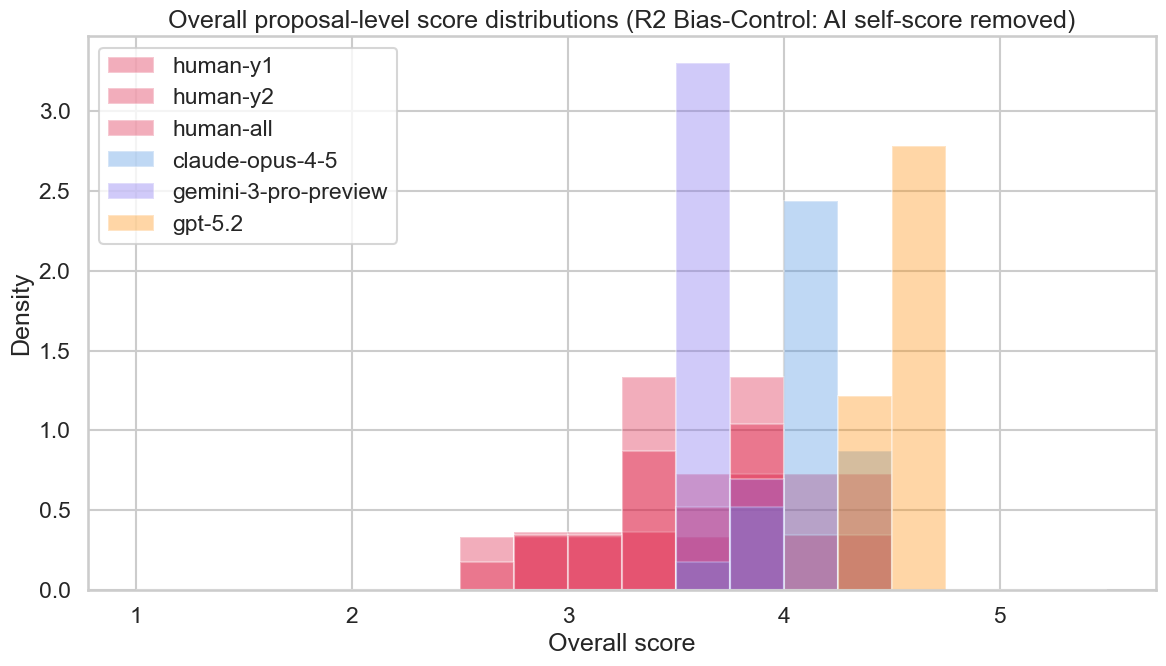

/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_89257/2041398244.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df_local, x='author_group', y='overall_score', order=keep_groups, palette=palette)


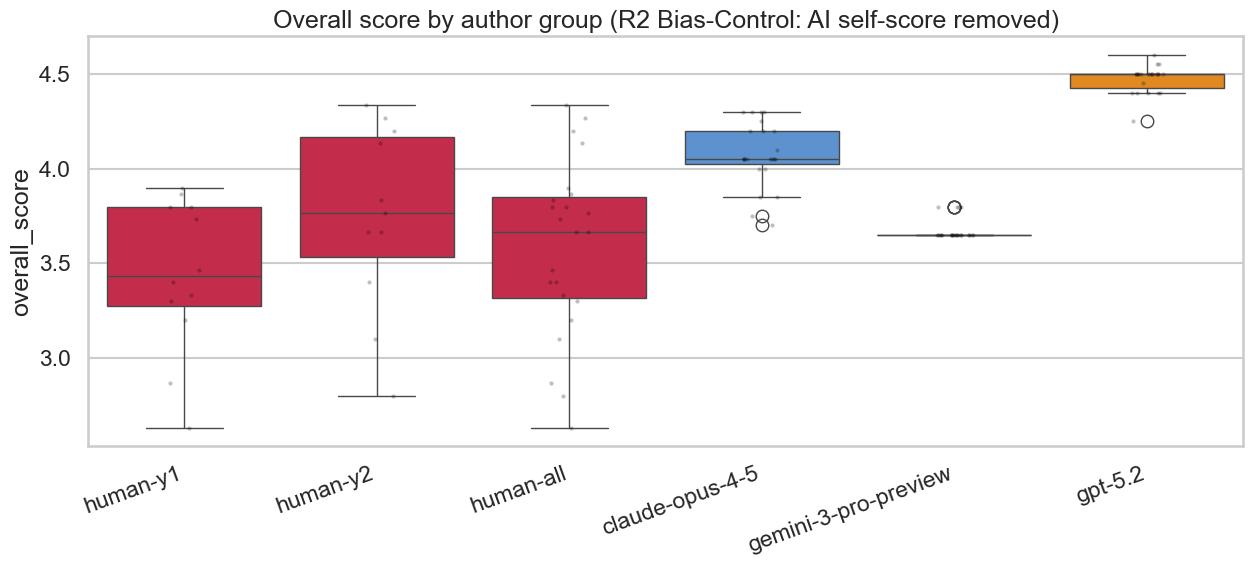

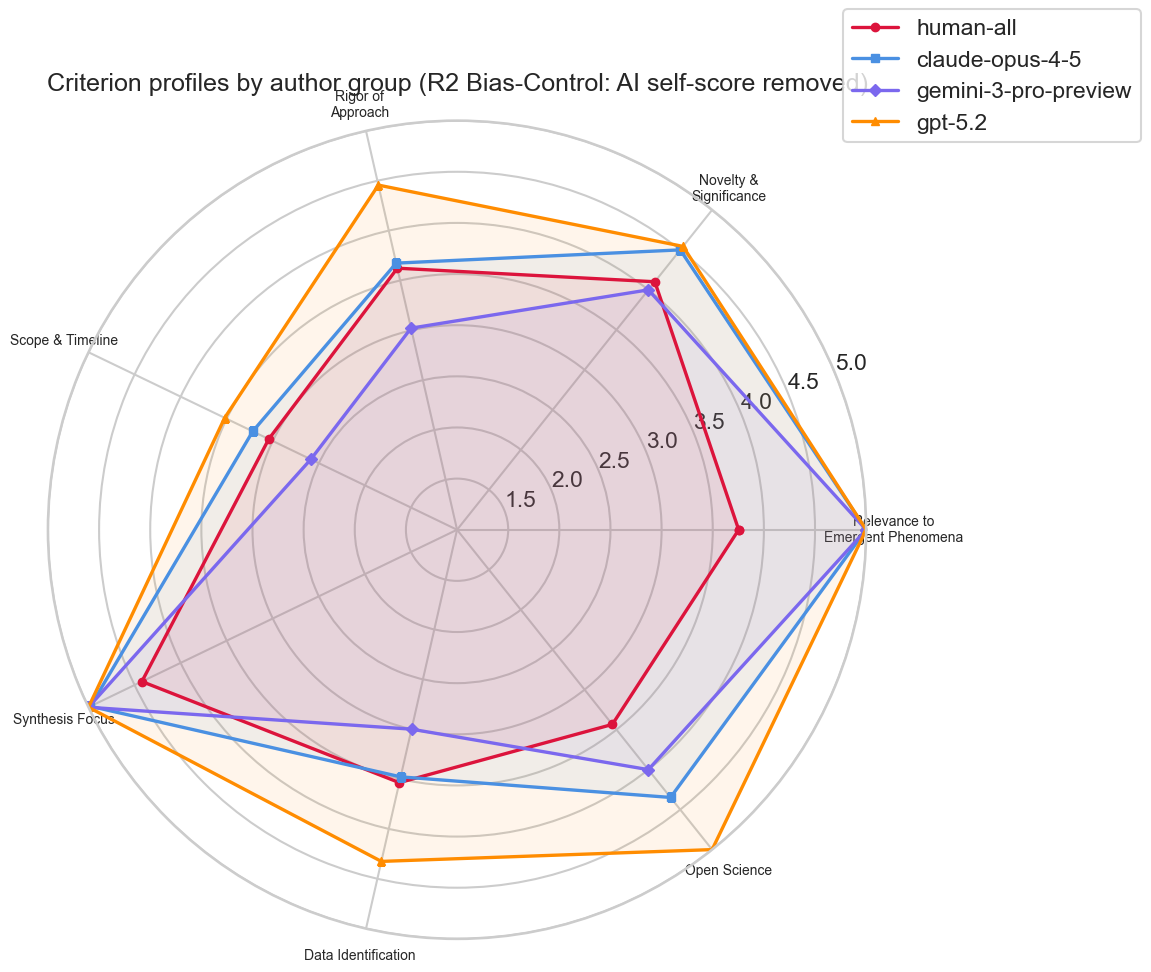

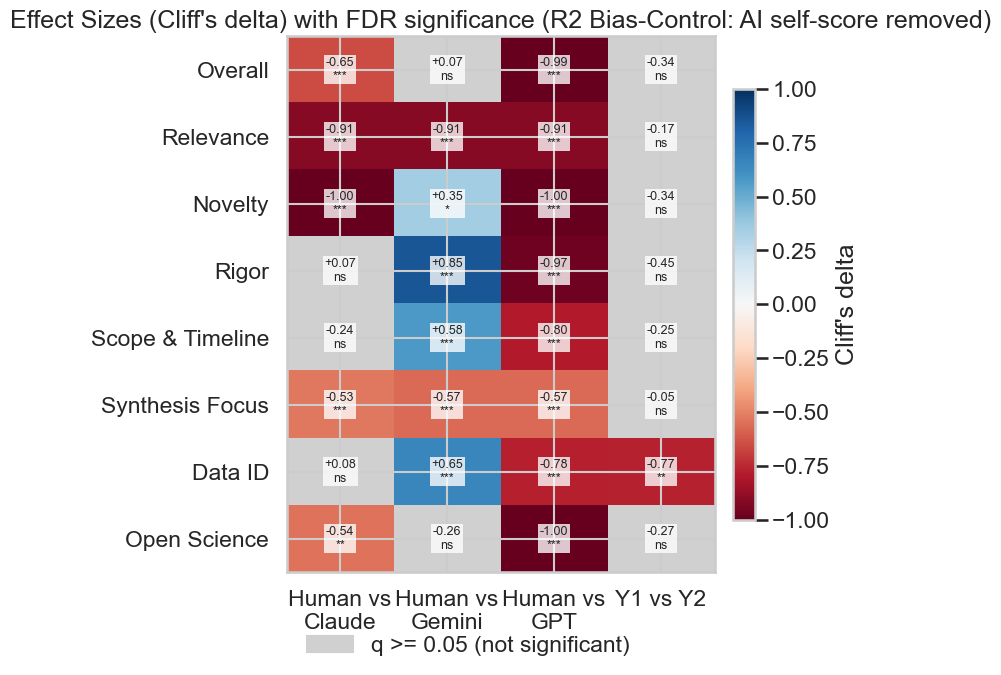

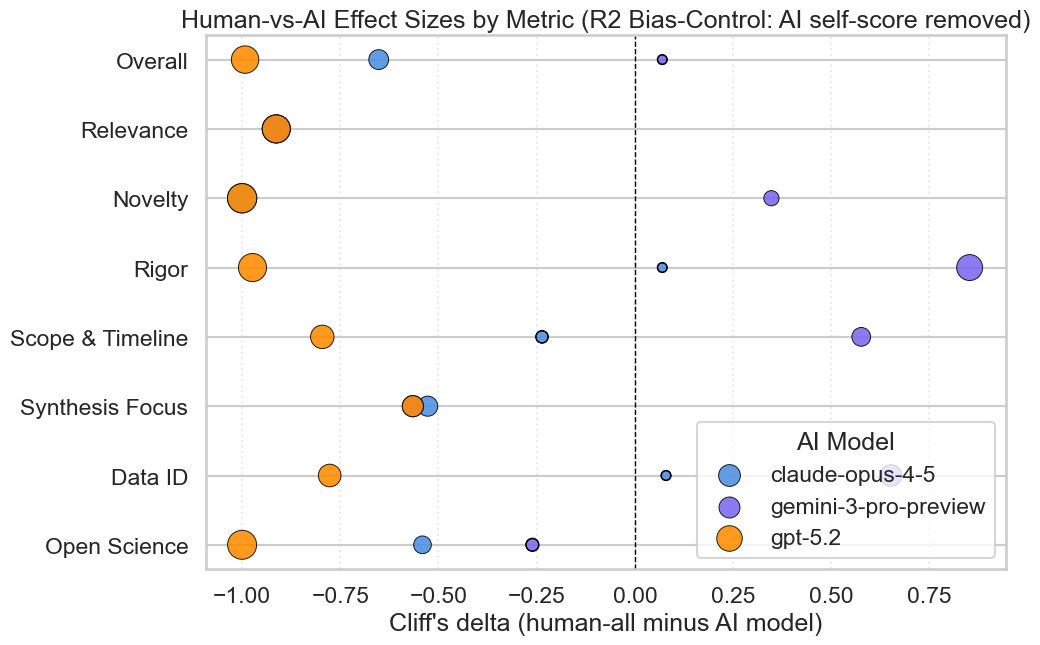

[R2 Bias-Control: AI self-score removed] proposal-level N by group:


,group,n_proposals,overall_mean,overall_median,overall_std
0,human-y1,12,3.441667,3.433333,0.405549
1,human-y2,11,3.742424,3.766667,0.492407
2,human-all,23,3.585507,3.666667,0.464804
3,claude-opus-4-5,23,4.073913,4.050000,0.171139
4,gemini-3-pro-preview,23,3.676087,3.650000,0.058133
5,gpt-5.2,23,4.473913,4.500000,0.072095


[R2 Bias-Control: AI self-score removed] human-all vs AI tests (FDR-adjusted):


,metric,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,group1,group2,mean_group1,mean_group2,q_value
20,Data_Identification,23,23,59.0,3.414922e-06,-0.776938,large,human-all,gpt-5.2,3.536232,4.326087,1.024477e-05
19,Data_Identification,23,23,437.0,2.248942e-05,0.652174,large,human-all,gemini-3-pro-preview,3.536232,3.000000,3.373413e-05
18,Data_Identification,23,23,285.5,6.457701e-01,0.079395,negligible,human-all,claude-opus-4-5,3.536232,3.478261,6.457701e-01
6,Novelty_and_Significance,23,23,0.0,3.458856e-10,-1.000000,large,human-all,claude-opus-4-5,4.101449,4.500000,1.024505e-09
8,Novelty_and_Significance,23,23,0.0,6.830036e-10,-1.000000,large,human-all,gpt-5.2,4.101449,4.543478,1.024505e-09
7,Novelty_and_Significance,23,23,356.5,1.665419e-02,0.347826,medium,human-all,gemini-3-pro-preview,4.101449,4.000000,1.665419e-02
23,Open_Science_Commitment,23,23,0.0,5.306573e-10,-1.000000,large,human-all,gpt-5.2,3.434783,5.000000,1.591972e-09
21,Open_Science_Commitment,23,23,121.5,1.277592e-03,-0.540643,large,human-all,claude-opus-4-5,3.434783,4.347826,1.916388e-03
22,Open_Science_Commitment,23,23,195.5,1.036951e-01,-0.260870,small,human-all,gemini-3-pro-preview,3.434783,4.000000,1.036951e-01
3,Relevance_to_Emergent_Phenomena,23,23,23.0,6.898421e-09,-0.913043,large,human-all,claude-opus-4-5,3.753623,5.000000,6.898421e-09


[R2 Bias-Control: AI self-score removed] robust sensitivity (head):


,metric,comparison,n_human_all,n_other,mean_diff,bootstrap_ci_lo,bootstrap_ci_hi,permutation_p_value,permutation_q_value
0,overall_score,human-all minus claude-opus-4-5,23,23,-0.488406,-0.698587,-0.290562,0.000200,0.000300
1,overall_score,human-all minus gemini-3-pro-preview,23,23,-0.090580,-0.288406,0.092772,0.348930,0.348930
2,overall_score,human-all minus gpt-5.2,23,23,-0.888406,-1.085525,-0.706522,0.000200,0.000300
3,Relevance_to_Emergent_Phenomena,human-all minus claude-opus-4-5,23,23,-1.246377,-1.637681,-0.884058,0.000200,0.000200
4,Relevance_to_Emergent_Phenomena,human-all minus gemini-3-pro-preview,23,23,-1.246377,-1.637681,-0.884058,0.000200,0.000200
5,Relevance_to_Emergent_Phenomena,human-all minus gpt-5.2,23,23,-1.246377,-1.637681,-0.884058,0.000200,0.000200
6,Novelty_and_Significance,human-all minus claude-opus-4-5,23,23,-0.398551,-0.514493,-0.282609,0.000200,0.000300
7,Novelty_and_Significance,human-all minus gemini-3-pro-preview,23,23,0.101449,-0.014493,0.217391,0.166567,0.166567
8,Novelty_and_Significance,human-all minus gpt-5.2,23,23,-0.442029,-0.579710,-0.318841,0.000200,0.000300
9,Rigor_of_Approach,human-all minus claude-opus-4-5,23,23,-0.050725,-0.253623,0.137862,0.630874,0.630874


In [32]:
# Build cross-evaluator-only dataset for AI-authored proposals.
# Rule:
# - AI-authored proposals: drop evaluator==author (remove self-review).
# - Human-authored proposals: keep all 3 AI evaluators.

ai_authors = ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

self_mask = ai_df['author'].isin(ai_authors) & (ai_df['evaluator'] == ai_df['author'])
ai_df_cross_eval_only = ai_df.loc[~self_mask].copy()

print('Rows removed (AI self-evaluations):', int(self_mask.sum()))
print('Remaining rows:', len(ai_df_cross_eval_only))
print('Remaining evaluator counts by author (AI authors should each have 2 evaluators/proposal):')
display(
    ai_df_cross_eval_only[ai_df_cross_eval_only['author'].isin(ai_authors)]
    .groupby(['author', 'evaluator'])
    .size()
    .unstack(fill_value=0)
)

r2_cross_eval_results = run_r2_10_12_pipeline(
    reviews_df=ai_df_cross_eval_only,
    run_tag='cross_eval_only',
    run_label='R2 Bias-Control: AI self-score removed',
)
